# Datathon — Passos Mágicos

**Curso:** POSTECH DTAT — Data Analytics  
**Aluno:** Renato Ferreira — RM 384836  
**Dataset:** PEDE_PASSOS_DATASET_FIAP.csv  
**Período:** 2020, 2021, 2022


---

## Nota Metodológica — Rigor Analítico

Este notebook foi desenvolvido com uma etapa de **validação estatística independente** (`validacao_estatistica.py`) que precedeu a redação das conclusões finais. O processo identificou **4 divergências materiais** entre as hipóteses iniciais e os dados — todas corrigidas antes da versão final.

### Divergências identificadas e corrigidas

| # | Hipótese inicial | O que os dados mostraram | Correção aplicada |
|---|-----------------|--------------------------|-------------------|
| 1 | IEG seria o principal diferenciador para indicação de bolsa | IEG ocupa o **8º lugar** (último). IPP (+0,987) e IDA (+0,944) lideram | Tese central revisada |
| 2 | Mais anos no programa → maior INDE (impacto cumulativo) | Spearman r = −0,075, **p = 0,176** — não significativo | Conclusão do Insight 1 corrigida |
| 3 | Escola pública = principal grupo de indicados para bolsa | **61,4% dos indicados** vêm de escola privada | Hipótese removida |
| 4 | INDE cresceu consistentemente de 2020 a 2022 | INDE caiu em 2021 (7,296→6,888) e recuperou parcialmente em 2022 (7,028) | Conclusão P10 corrigida |

### Justificativa dos testes estatísticos

Nenhum indicador segue distribuição normal (Shapiro-Wilk p < 0,05 em todos) — por isso todas as análises de correlação usam **Spearman com p-valores explícitos** e comparações de grupo usam **Kruskal-Wallis**, em vez de Pearson/ANOVA.

### Discriminação por Pedra — validado

Kruskal-Wallis INDE × Pedra: **H = 777,16, p ≈ 0** — o INDE cumpre sua função classificatória com altíssima significância estatística.

> 📄 Documentação completa: [`docs/NOTAS_VALIDACAO.md`](../docs/NOTAS_VALIDACAO.md)

---


## 0. Configuracao Inicial

### 0.1 Importacoes e Carregamento da Base

In [292]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

pd.set_option('display.max_columns', None)

file_path = '../data/PEDE_PASSOS_DATASET_FIAP.csv'
df = pd.read_csv(file_path, delimiter=';')

print('Base carregada com sucesso.')
print(f'Shape: {df.shape}')


Base carregada com sucesso.
Shape: (1349, 69)


### 0.2 Observacoes sobre a Base

- Existem inconsistencias de nomenclatura entre o dataset e o dicionario de dados PDF.
- Colunas ausentes em relacao ao dicionario: `REC_PSICO_2021`, `REC_PSICO_2022`, `INSTITUICAO_ENSINO_ALUNO_2022`.
- A base e longitudinal: cada linha representa um aluno que pode ter registros em 2020, 2021 e/ou 2022.
- Alunos ingressantes em 2022 possuem colunas de 2020 e 2021 totalmente nulas — isso e esperado.
- O numero de colunas cresceu ao longo dos anos (18 em 2020, 20 em 2021, 30 em 2022), refletindo a evolucao do instrumento de avaliacao.

### 0.3 Estrutura das Colunas por Ano

In [293]:
for ano in ['2020', '2021', '2022']:
    cols = df.columns[df.columns.str.contains(ano)]
    print(f'--- {ano} ({len(cols)} colunas) ---')
    print(list(cols))
    print()


--- 2020 (18 colunas) ---
['INSTITUICAO_ENSINO_ALUNO_2020', 'IDADE_ALUNO_2020', 'ANOS_PM_2020', 'FASE_TURMA_2020', 'PONTO_VIRADA_2020', 'INDE_2020', 'INDE_CONCEITO_2020', 'PEDRA_2020', 'DESTAQUE_IEG_2020', 'DESTAQUE_IDA_2020', 'DESTAQUE_IPV_2020', 'IAA_2020', 'IEG_2020', 'IPS_2020', 'IDA_2020', 'IPP_2020', 'IPV_2020', 'IAN_2020']

--- 2021 (20 colunas) ---
['FASE_2021', 'TURMA_2021', 'INSTITUICAO_ENSINO_ALUNO_2021', 'SINALIZADOR_INGRESSANTE_2021', 'PEDRA_2021', 'INDE_2021', 'IAA_2021', 'IEG_2021', 'IPS_2021', 'IDA_2021', 'IPP_2021', 'REC_EQUIPE_1_2021', 'REC_EQUIPE_2_2021', 'REC_EQUIPE_3_2021', 'REC_EQUIPE_4_2021', 'PONTO_VIRADA_2021', 'IPV_2021', 'IAN_2021', 'NIVEL_IDEAL_2021', 'DEFASAGEM_2021']

--- 2022 (30 colunas) ---
['FASE_2022', 'TURMA_2022', 'ANO_INGRESSO_2022', 'BOLSISTA_2022', 'INDE_2022', 'CG_2022', 'CF_2022', 'CT_2022', 'PEDRA_2022', 'DESTAQUE_IEG_2022', 'DESTAQUE_IDA_2022', 'DESTAQUE_IPV_2022', 'IAA_2022', 'IEG_2022', 'IPS_2022', 'IDA_2022', 'NOTA_PORT_2022', 'NOTA_MAT_20

### 0.4 Funcoes Auxiliares

In [294]:
def filter_columns(df, filters: list):
    """Remove colunas cujo nome contenha qualquer um dos padroes informados."""
    selected = [not any(f in col for f in filters) for col in df.columns]
    return df[df.columns[selected]]


def cleaning_dataset(df):
    """Remove linhas onde todas as colunas (exceto NOME) sao nulas."""
    _df = df.dropna(subset=df.columns.difference(['NOME']), how='all')
    _df = _df[~_df.isna().all(axis=1)]
    return _df


def plot_bar_count(size, label, counts):
    """Gera um grafico de barras com rotulo de valor em cada barra."""
    plt.figure(figsize=size)
    bars = plt.bar(counts.index, counts.values, color='steelblue')
    for i, v in enumerate(counts.values):
        plt.text(i, v + 0.5, str(round(v, 2)), ha='center', fontsize=9)
    plt.xlabel(label)
    plt.ylabel('Quantidade')
    plt.tight_layout()
    plt.show()


def analyse_corr(df):
    """Exibe heatmap de correlacao para colunas numericas."""
    df_num = df.apply(pd.to_numeric, errors='coerce')
    corr_matrix = df_num.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.tight_layout()
    plt.show()


### 0.5 Separacao dos DataFrames por Ano

Cada ano e tratado como um subconjunto independente, removendo colunas e linhas
de outros anos para garantir analises sem contaminacao de dados ausentes estruturais.

In [295]:
# DataFrame 2020
df_2020 = filter_columns(df, ['2021', '2022'])
df_2020 = cleaning_dataset(df_2020)
print(f'df_2020: {df_2020.shape[0]} alunos, {df_2020.shape[1]} colunas')

# DataFrame 2021
df_2021 = filter_columns(df, ['2020', '2022'])
df_2021 = cleaning_dataset(df_2021)
print(f'df_2021: {df_2021.shape[0]} alunos, {df_2021.shape[1]} colunas')

# DataFrame 2022
df_2022 = filter_columns(df, ['2020', '2021'])
df_2022 = cleaning_dataset(df_2022)
print(f'df_2022: {df_2022.shape[0]} alunos, {df_2022.shape[1]} colunas')


df_2020: 728 alunos, 19 colunas
df_2021: 686 alunos, 21 colunas
df_2022: 862 alunos, 31 colunas


### 0.6 Verificacao — Exemplo de Aluno com Dados Apenas em 2022

Alunos ingressantes em 2022 possuem todos os campos de 2020 e 2021 nulos.
Este comportamento e esperado e confirma a estrutura longitudinal da base.

In [296]:
pd.DataFrame(df.loc[df['NOME'] == 'ALUNO-2']).transpose()


,1
INSTITUICAO_ENSINO_ALUNO_2020,NaN
NOME,ALUNO-2
IDADE_ALUNO_2020,NaN
ANOS_PM_2020,NaN
FASE_TURMA_2020,NaN
...,...
INDICADO_BOLSA_2022,Sim
PONTO_VIRADA_2022,Não
IPV_2022,7.916665
IAN_2022,5.0


### 0.7 Distribuicao Inicial — Pedra 2020

Verificacao rapida da distribuicao de classificacao dos alunos em 2020.
O registro `D9891/2A` e invalido e sera excluido nas analises.

Distribuicao de Pedras — 2020:
PEDRA_2020
Ametista    336
Ágata       171
Quartzo     128
Topázio      92
D9891/2A      1
Name: count, dtype: int64



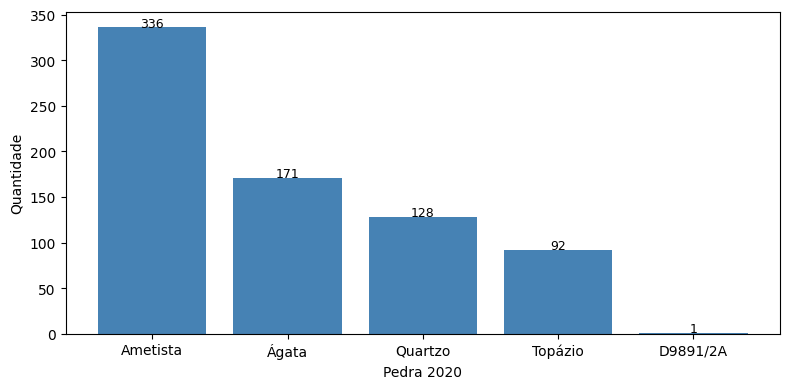

In [297]:
print('Distribuicao de Pedras — 2020:')
print(df_2020['PEDRA_2020'].value_counts())
print()
plot_bar_count(
    size=(8, 4),
    label='Pedra 2020',
    counts=df_2020['PEDRA_2020'].value_counts()
)


---
## Ideias para Analise

Pontos de investigacao identificados na fase de exploracao inicial:

- Predicao de desempenho futuro e identificacao de outliers de alta performance.
- Predicao para recomendacao de bolsas e intercambio.
- Analise comparativa entre 2020, 2021 e 2022.
- Rastreamento individual de alunos ao longo dos anos (evasao, progressao).
- Analise de fatores que diferenciam alunos de alto e baixo desempenho.
- Classificacao preditiva da Pedra a partir dos indicadores.

---

---
## 1. Analise Exploratoria dos Dados (EDA)

Esta secao apresenta uma visao geral da base antes de qualquer modelagem ou analise tematica.
O objetivo e entender a estrutura, volume, qualidade e distribuicao dos dados disponíveis.

### 1.1 Estrutura Geral da Base

In [298]:
# Dimensoes e tipos de dados
print('Dimensoes da base (linhas x colunas):', df.shape)
print()
print('Tipos de dados:')
print(df.dtypes.value_counts())
print()
print('Colunas por ano:')
for ano in ['2020', '2021', '2022']:
    cols = df.columns[df.columns.str.contains(ano)]
    print(f'  {ano}: {len(cols)} colunas')


Dimensoes da base (linhas x colunas): (1349, 69)

Tipos de dados:
object     43
float64    26
Name: count, dtype: int64

Colunas por ano:
  2020: 18 colunas
  2021: 20 colunas
  2022: 30 colunas


### 1.2 Volume de Alunos por Ano

A base e longitudinal: um mesmo aluno pode aparecer em mais de um ano.
Os nulos estruturais indicam alunos que nao participaram do programa naquele periodo.
A presenca e determinada pela existencia de valor no indicador IAN de cada ano.

In [299]:
s20 = df['IAN_2020'].notna()
s21 = df['IAN_2021'].notna()
s22 = df['IAN_2022'].notna()

print('Alunos com dados por ano:')
print(f'  2020: {s20.sum()}')
print(f'  2021: {s21.sum()}')
print(f'  2022: {s22.sum()}')
print()
print('Distribuicao de presenca por combinacao de anos:')
print(f'  Somente 2020              : {(s20 & ~s21 & ~s22).sum()}')
print(f'  Somente 2021              : {(~s20 & s21 & ~s22).sum()}')
print(f'  Somente 2022              : {(~s20 & ~s21 & s22).sum()}')
print(f'  2020 e 2021               : {(s20 & s21 & ~s22).sum()}')
print(f'  2020 e 2022               : {(s20 & ~s21 & s22).sum()}')
print(f'  2021 e 2022               : {(~s20 & s21 & s22).sum()}')
print(f'  Presentes nos 3 anos      : {(s20 & s21 & s22).sum()}')


Alunos com dados por ano:
  2020: 728
  2021: 686
  2022: 862

Distribuicao de presenca por combinacao de anos:
  Somente 2020              : 258
  Somente 2021              : 86
  Somente 2022              : 392
  2020 e 2021               : 143
  2020 e 2022               : 13
  2021 e 2022               : 143
  Presentes nos 3 anos      : 314


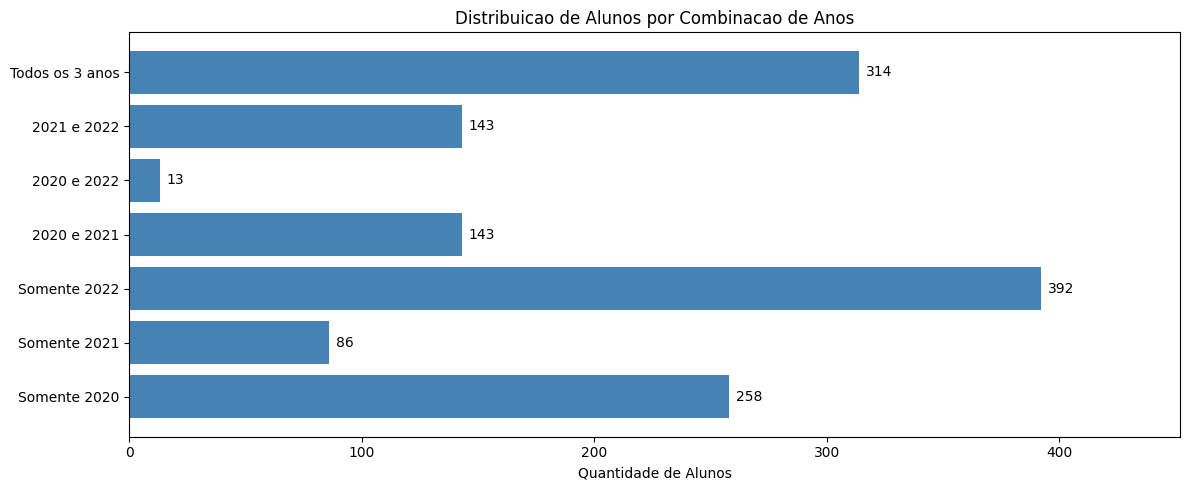

In [300]:
import matplotlib.pyplot as plt

presenca = {
    'Somente 2020'   : (s20 & ~s21 & ~s22).sum(),
    'Somente 2021'   : (~s20 & s21 & ~s22).sum(),
    'Somente 2022'   : (~s20 & ~s21 & s22).sum(),
    '2020 e 2021'    : (s20 & s21 & ~s22).sum(),
    '2020 e 2022'    : (s20 & ~s21 & s22).sum(),
    '2021 e 2022'    : (~s20 & s21 & s22).sum(),
    'Todos os 3 anos': (s20 & s21 & s22).sum(),
}

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(list(presenca.keys()), list(presenca.values()), color='steelblue')
for bar, val in zip(bars, presenca.values()):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10)
ax.set_xlabel('Quantidade de Alunos')
ax.set_title('Distribuicao de Alunos por Combinacao de Anos')
ax.set_xlim(0, max(presenca.values()) + 60)
plt.tight_layout()
plt.show()


### 1.3 Qualidade dos Dados — Valores Ausentes

A taxa de nulos e uniforme dentro de cada ano para todos os indicadores,
confirmando que os dados sao completos para quem participou.
Os nulos representam ausencia no programa, nao falha de coleta.

In [301]:
indicadores = ['IAA', 'IEG', 'IPS', 'IDA', 'IPP', 'IPV', 'IAN', 'INDE']

print('Taxa de valores ausentes por indicador e ano (%):')
print(f'{"Indicador":<10} {"2020":>8} {"2021":>8} {"2022":>8}')
print('-' * 38)
for ind in indicadores:
    vals = []
    for ano in ['2020', '2021', '2022']:
        col = f'{ind}_{ano}'
        if col in df.columns:
            vals.append(f'{df[col].isnull().mean()*100:.1f}%')
        else:
            vals.append('N/A')
    print(f'{ind:<10} {vals[0]:>8} {vals[1]:>8} {vals[2]:>8}')


Taxa de valores ausentes por indicador e ano (%):
Indicador      2020     2021     2022
--------------------------------------
IAA           46.0%    49.1%    36.1%
IEG           46.0%    49.1%    36.1%
IPS           46.0%    49.1%    36.1%
IDA           46.0%    49.1%    36.1%
IPP           46.0%    49.1%    36.1%
IPV           46.0%    49.1%    36.1%
IAN           46.0%    49.1%    36.1%
INDE          46.0%    49.1%    36.1%


### 1.4 Distribuicao das Pedras por Ano

A Pedra e a classificacao de desempenho global baseada no INDE.
Ordem crescente: **Quartzo < Agata < Ametista < Topazio**.
Registros invalidos (D9891/2A em 2020 e #NULO! em 2021) serao excluidos.

In [302]:
import pandas as pd

pedra_2020 = df_2020['PEDRA_2020'].replace({'D9891/2A': None}).dropna()
pedra_2021 = df_2021['PEDRA_2021'].replace({'#NULO!': None}).dropna()
pedra_2022 = df_2022['PEDRA_2022'].dropna()

dist_pedra = pd.DataFrame({
    '2020': pedra_2020.value_counts(),
    '2021': pedra_2021.value_counts(),
    '2022': pedra_2022.value_counts(),
})

print('Contagem absoluta:')
print(dist_pedra)
print()
print('Distribuicao percentual (%):')
print(dist_pedra.div(dist_pedra.sum()).mul(100).round(1))


Contagem absoluta:
          2020  2021  2022
Ametista   336   295   348
Ágata      171   178   250
Quartzo    128   110   134
Topázio     92   101   130

Distribuicao percentual (%):
          2020  2021  2022
Ametista  46.2  43.1  40.4
Ágata     23.5  26.0  29.0
Quartzo   17.6  16.1  15.5
Topázio   12.7  14.8  15.1


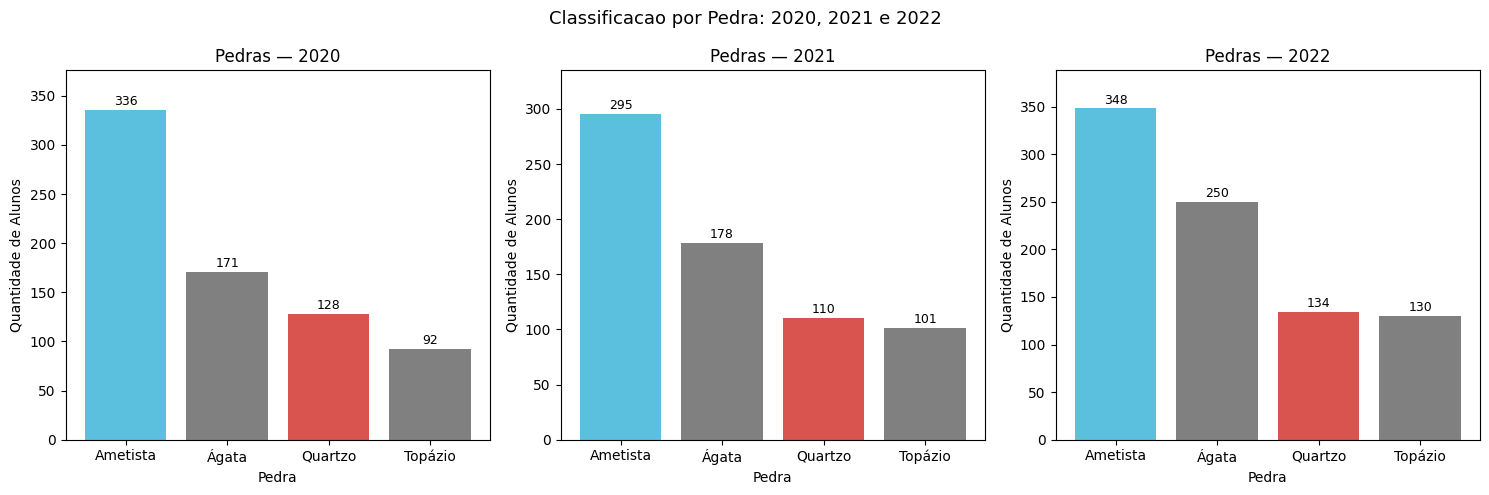

In [303]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cores = {'Quartzo': '#d9534f', 'Agata': '#f0ad4e', 'Ametista': '#5bc0de', 'Topazio': '#5cb85c'}

for ax, (ano, serie) in zip(axes, [
    ('2020', pedra_2020), ('2021', pedra_2021), ('2022', pedra_2022)
]):
    contagem = serie.value_counts()
    barras = ax.bar(
        contagem.index, contagem.values,
        color=[cores.get(p, 'gray') for p in contagem.index]
    )
    for bar, val in zip(barras, contagem.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                str(val), ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Pedras — {ano}')
    ax.set_xlabel('Pedra')
    ax.set_ylabel('Quantidade de Alunos')
    ax.set_ylim(0, contagem.max() + 40)

plt.suptitle('Classificacao por Pedra: 2020, 2021 e 2022', fontsize=13)
plt.tight_layout()
plt.show()


### 1.5 Estatisticas Descritivas dos Indicadores

Todos os indicadores variam entre 0 e 10.
A analise descritiva apresenta media, desvio padrao, minimo, quartis e maximo para cada um.

In [304]:
for ano in ['2020', '2021', '2022']:
    cols = [f'{ind}_{ano}' for ind in ['IAA','IEG','IPS','IDA','IPP','IPV','IAN','INDE']
            if f'{ind}_{ano}' in df.columns]
    df_ano = df[cols].apply(pd.to_numeric, errors='coerce')
    df_ano.columns = [c.replace(f'_{ano}', '') for c in df_ano.columns]
    print(f'=== Estatisticas Descritivas — {ano} ===')
    print(df_ano.describe().round(2))
    print()


=== Estatisticas Descritivas — 2020 ===
          IAA     IEG     IPS     IDA     IPP     IPV     IAN    INDE
count  727.00  727.00  727.00  727.00  727.00  727.00  727.00  727.00
mean     8.37    7.68    6.74    6.32    7.07    7.24    7.43    7.30
std      1.73    2.38    1.37    2.96    1.99    1.78    2.56    1.20
min      0.00    0.00    2.50    0.00    0.00    0.00    2.50    3.07
25%      7.96    6.60    5.62    4.67    6.95    6.92    5.00    6.57
50%      8.75    8.50    7.50    7.00    7.50    7.58    5.00    7.58
75%      9.17    9.50    7.50    8.67    8.12    8.06   10.00    8.18
max     10.00   10.00   10.00   10.00   10.00   10.00   10.00    9.71

=== Estatisticas Descritivas — 2021 ===
          IAA     IEG     IPS     IDA     IPP     IPV     IAN    INDE
count  686.00  686.00  686.00  686.00  686.00  686.00  686.00  684.00
mean     8.15    6.82    6.84    5.43    7.58    7.41    6.90    6.89
std      2.19    2.46    1.46    2.14    1.07    1.63    2.48    1.35
min      

### 1.6 Distribuicao dos Indicadores — Boxplot Comparativo

O boxplot permite visualizar a dispersao e a mediana de cada indicador,
facilitando a identificacao de outliers e assimetrias por ano.

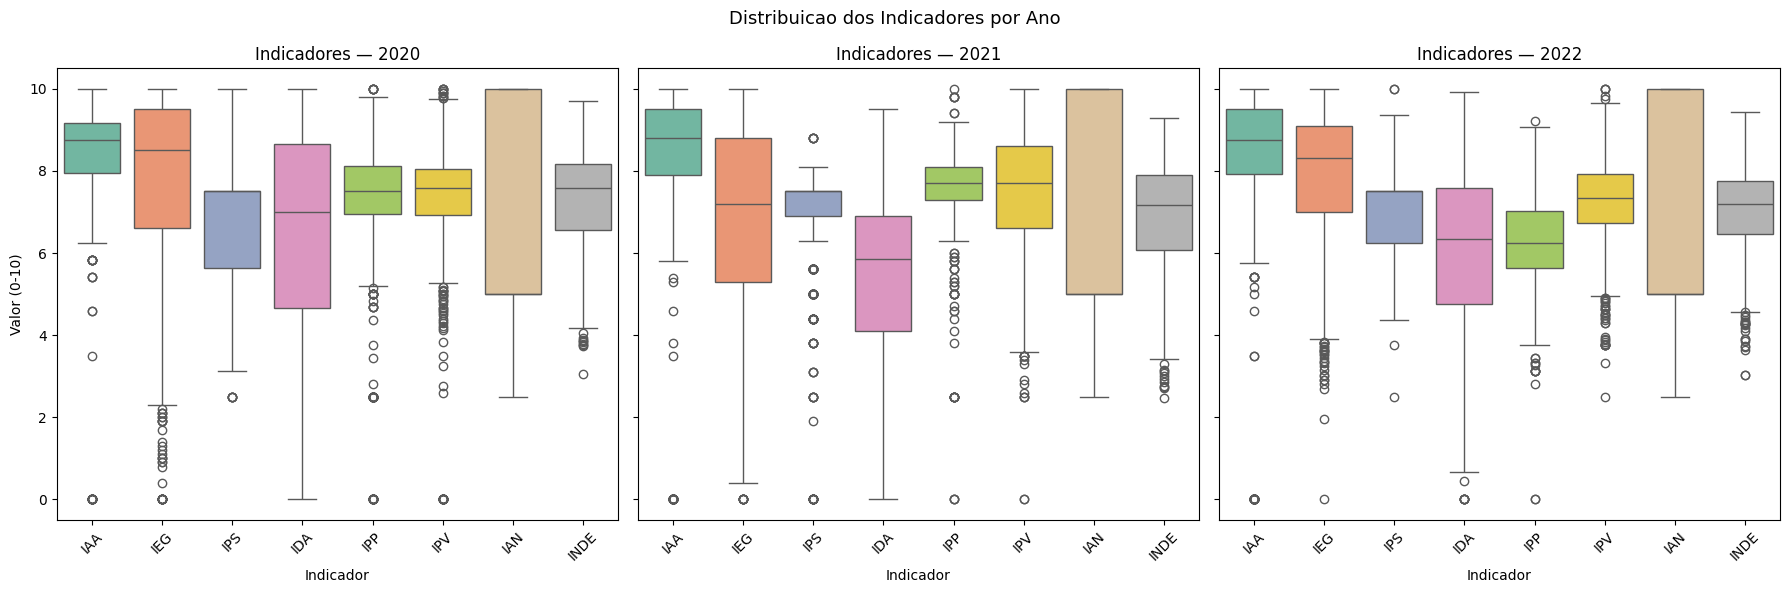

In [305]:
import seaborn as sns

indicadores_base = ['IAA', 'IEG', 'IPS', 'IDA', 'IPP', 'IPV', 'IAN', 'INDE']

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, ano in zip(axes, ['2020', '2021', '2022']):
    cols = [f'{ind}_{ano}' for ind in indicadores_base if f'{ind}_{ano}' in df.columns]
    df_plot = df[cols].apply(pd.to_numeric, errors='coerce')
    df_plot.columns = [c.replace(f'_{ano}', '') for c in df_plot.columns]
    df_melted = df_plot.melt(var_name='Indicador', value_name='Valor')
    sns.boxplot(data=df_melted, x='Indicador', y='Valor', ax=ax, palette='Set2')
    ax.set_title(f'Indicadores — {ano}')
    ax.set_xlabel('Indicador')
    ax.set_ylabel('Valor (0-10)')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Distribuicao dos Indicadores por Ano', fontsize=13)
plt.tight_layout()
plt.show()


### 1.7 Resumo da EDA

| Item | Valor |
|------|-------|
| Total de registros na base | 1.349 |
| Total de colunas | 69 |
| Alunos com dados em 2020 | 728 |
| Alunos com dados em 2021 | 686 |
| Alunos com dados em 2022 | 862 |
| Alunos presentes nos 3 anos | 314 |
| Taxa media de nulos (2020 / 2021 / 2022) | 46% / 49% / 36% |
| Indicadores numericos | IAA, IEG, IPS, IDA, IPP, IPV, IAN, INDE |
| Escala dos indicadores | 0 a 10 |
| Classificacao de desempenho | Quartzo < Agata < Ametista < Topazio |
| Notas escolares disponiveis | Somente 2022 (Port, Mat, Ing) |
| Avaliacoes de equipe disponiveis | 2021 e 2022 |
| Numero de avaliacoes por aluno (2022) | 2, 3 ou 4 ciclos |
| Componentes CG / CF / CT | Somente 2022 |

**Observacoes:**

- Os nulos sao estruturais e representam ausencia no programa, nao falha de coleta.
- O volume de alunos cresceu de 728 (2020) para 862 (2022), indicando expansao do programa.
- Apenas 314 alunos possuem dados nos 3 anos — nucleo da analise longitudinal.
- Um registro invalido em 2020 (D9891/2A) e dois em 2021 (#NULO!) foram excluidos.
- **A metodologia de calculo dos indicadores evoluiu entre os anos** — 2022 e o ano mais completo, com notas escolares, componentes CG/CF/CT e numero variavel de avaliacoes. Comparacoes temporais devem ser interpretadas com cautela. Detalhes na secao 1.8.

### 1.8 Qualidade Metodologica dos Indicadores

**Este e um achado critico para a interpretacao correta de toda a analise.**

A estrutura de coleta e o numero de insumos que alimentam cada indicador **variam entre os anos**, o que significa que comparacoes diretas de valores entre 2020, 2021 e 2022 devem ser feitas com cautela.

Uma variacao em um indicador pode refletir **mudanca real de desempenho** ou simplesmente **mudanca na metodologia de calculo**.

#### 1.8.1 Evolucao da Metodologia por Ano

In [306]:
import pandas as pd

print('=== Insumos disponiveis por ano para calculo dos indicadores ===')
print()

estrutura = {
    'Indicadores base (IAA, IEG, IPS, IDA, IPP, IPV, IAN, INDE)': ['Sim', 'Sim', 'Sim'],
    'Recomendacoes de equipe (4 avaliadores)'                   : ['Nao', 'Sim', 'Sim'],
    'Notas escolares (Portugues, Matematica, Ingles)'           : ['Nao', 'Nao', 'Sim'],
    'Numero variavel de avaliacoes (2, 3 ou 4)'                 : ['Nao', 'Nao', 'Sim'],
    'Componentes CG / CF / CT'                                  : ['Nao', 'Nao', 'Sim'],
}

df_estrutura = pd.DataFrame(estrutura, index=['2020', '2021', '2022']).T
df_estrutura.index.name = 'Insumo'
print(df_estrutura.to_string())


=== Insumos disponiveis por ano para calculo dos indicadores ===

                                                           2020 2021 2022
Insumo                                                                   
Indicadores base (IAA, IEG, IPS, IDA, IPP, IPV, IAN, INDE)  Sim  Sim  Sim
Recomendacoes de equipe (4 avaliadores)                     Nao  Sim  Sim
Notas escolares (Portugues, Matematica, Ingles)             Nao  Nao  Sim
Numero variavel de avaliacoes (2, 3 ou 4)                   Nao  Nao  Sim
Componentes CG / CF / CT                                    Nao  Nao  Sim


#### 1.8.2 Impacto do Numero de Avaliacoes no IDA (2022)

Em 2022 cada aluno passou por 2, 3 ou 4 ciclos de avaliacao. Verificamos se essa variacao impacta o IDA final calculado.

In [307]:
df_qtd = df[['QTD_AVAL_2022', 'IDA_2022']].copy()
df_qtd['QTD_AVAL_2022'] = pd.to_numeric(df_qtd['QTD_AVAL_2022'], errors='coerce')
df_qtd['IDA_2022']      = pd.to_numeric(df_qtd['IDA_2022'], errors='coerce')
df_qtd = df_qtd.dropna()

resumo_qtd = df_qtd.groupby('QTD_AVAL_2022')['IDA_2022'].agg(
    Alunos='count', Media='mean', Desvio='std', Minimo='min', Maximo='max'
).round(2)
resumo_qtd.index = resumo_qtd.index.astype(int).astype(str) + ' avaliacoes'

print('IDA_2022 por quantidade de avaliacoes:')
print(resumo_qtd.to_string())
print()
print('Diferenca entre 2 e 4 avaliacoes:',
      round(df_qtd[df_qtd['QTD_AVAL_2022']==2]['IDA_2022'].mean() -
            df_qtd[df_qtd['QTD_AVAL_2022']==4]['IDA_2022'].mean(), 2),
      'pontos')


IDA_2022 por quantidade de avaliacoes:
               Alunos  Media  Desvio  Minimo  Maximo
QTD_AVAL_2022                                       
2 avaliacoes      236   6.87    1.79    1.67    9.73
3 avaliacoes      341   5.98    2.10    0.00    9.92
4 avaliacoes      285   5.52    2.02    0.00    9.11

Diferenca entre 2 e 4 avaliacoes: 1.36 pontos


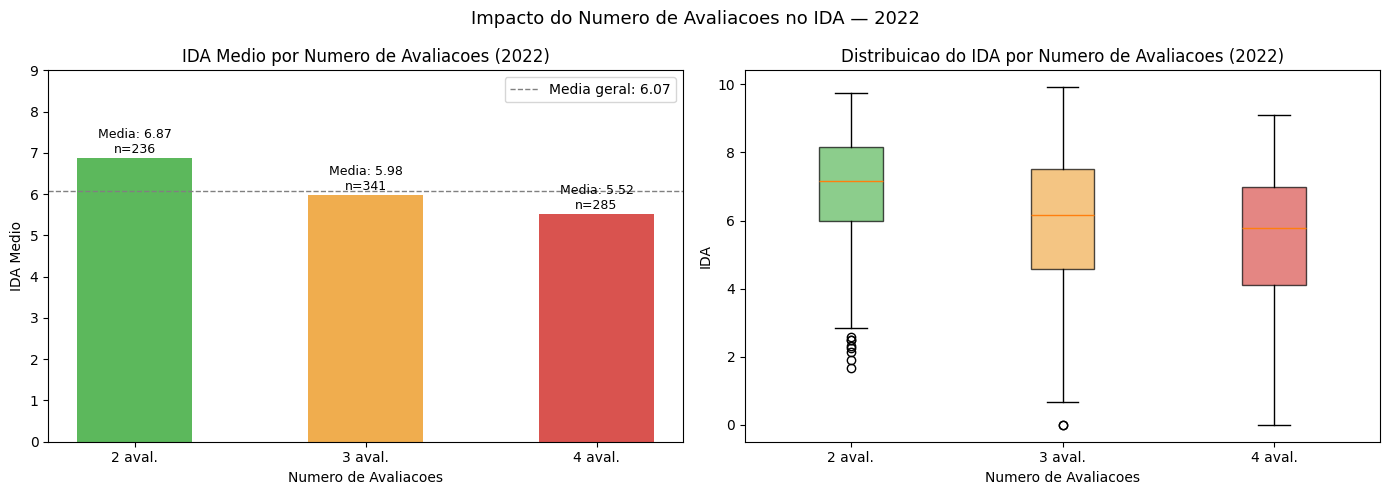

In [308]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafico 1: IDA medio por numero de avaliacoes ---
grupos = df_qtd.groupby('QTD_AVAL_2022')['IDA_2022']
medias = grupos.mean()
contagens = grupos.count()

bars = axes[0].bar(
    [f'{int(k)} aval.' for k in medias.index],
    medias.values,
    color=['#5cb85c', '#f0ad4e', '#d9534f'],
    width=0.5
)
for bar, media, n in zip(bars, medias.values, contagens.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'Media: {media:.2f}\nn={n}', ha='center', va='bottom', fontsize=9)
axes[0].set_title('IDA Medio por Numero de Avaliacoes (2022)')
axes[0].set_xlabel('Numero de Avaliacoes')
axes[0].set_ylabel('IDA Medio')
axes[0].set_ylim(0, 9)
axes[0].axhline(df_qtd['IDA_2022'].mean(), color='gray', linestyle='--',
                linewidth=1, label=f'Media geral: {df_qtd["IDA_2022"].mean():.2f}')
axes[0].legend()

# --- Grafico 2: Boxplot IDA por numero de avaliacoes ---
grupos_box = [df_qtd[df_qtd['QTD_AVAL_2022'] == k]['IDA_2022'].values
              for k in sorted(df_qtd['QTD_AVAL_2022'].unique())]
bp = axes[1].boxplot(grupos_box, patch_artist=True,
                     labels=[f'{int(k)} aval.' for k in sorted(df_qtd['QTD_AVAL_2022'].unique())])
cores = ['#5cb85c', '#f0ad4e', '#d9534f']
for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)
axes[1].set_title('Distribuicao do IDA por Numero de Avaliacoes (2022)')
axes[1].set_xlabel('Numero de Avaliacoes')
axes[1].set_ylabel('IDA')

plt.suptitle('Impacto do Numero de Avaliacoes no IDA — 2022', fontsize=13)
plt.tight_layout()
plt.show()


#### 1.8.3 Composicao do INDE — Correlacao com Componentes (2022)

Em 2022 o INDE e calculado a partir de CG (classificacao geral), CF e CT. Verificamos o peso de cada componente no resultado final.

Correlacao entre componentes e INDE_2022:
CG_2022   -0.956
CF_2022   -0.644
CT_2022   -0.727
Name: INDE_2022, dtype: float64

Observacao: CG e um ranking (posicao do aluno), portanto correlacao
negativa indica que posicao mais baixa (melhor ranking) = INDE maior.


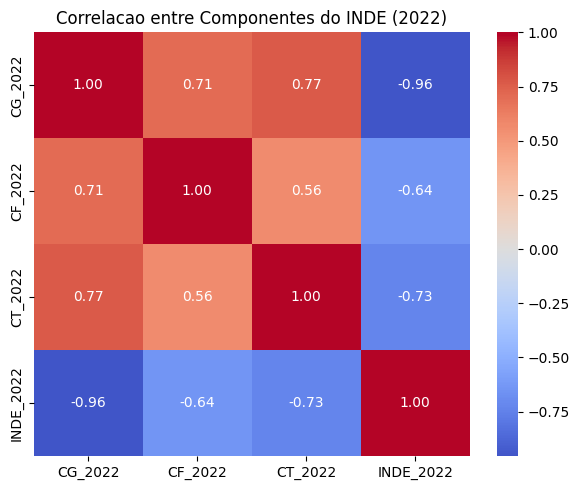

In [309]:
import seaborn as sns

df_inde = df[['CG_2022', 'CF_2022', 'CT_2022', 'INDE_2022']].apply(
    pd.to_numeric, errors='coerce'
).dropna()

corr = df_inde.corr()
print('Correlacao entre componentes e INDE_2022:')
print(corr['INDE_2022'].drop('INDE_2022').round(3))
print()
print('Observacao: CG e um ranking (posicao do aluno), portanto correlacao')
print('negativa indica que posicao mais baixa (melhor ranking) = INDE maior.')

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlacao entre Componentes do INDE (2022)')
plt.tight_layout()
plt.show()


#### 1.8.4 Conclusao — Impacto Metodologico nas Analises

| Aspecto | Impacto | Recomendacao |
|---------|---------|---------------|
| Metodologia diferente por ano | Alto | Evitar comparacoes diretas de valores absolutos entre anos |
| Numero de avaliacoes variavel (2022) | Medio | Considerar QTD_AVAL como variavel de controle no modelo |
| Notas escolares so em 2022 | Alto | IDA de 2022 tem base mais ampla que 2020 e 2021 |
| CG/CF/CT so em 2022 | Alto | INDE de 2022 calculado de forma diferente dos anos anteriores |

**Diretriz adotada nesta analise:**

- Tendencias entre anos serao interpretadas como **indicativas**, nao conclusivas.
- Comparacoes absolutas serao feitas **dentro do mesmo ano**.
- O modelo preditivo usara preferencialmente dados de **2022**, por ser o ano mais completo e metodologicamente mais rico.
- Toda conclusao que envolva evolucao temporal sera acompanhada desta ressalva metodologica.

---
## 2. Analise de Evasao — Alunos Ausentes em Algum Ano

Esta secao investiga se alunos que nao permaneceram no programa nos tres anos
apresentavam caracteristicas de defasagem antes de sua saida.

**Hipotese:** alunos com baixo desempenho academico (IDA) e baixo engajamento (IEG)
tem maior probabilidade de nao continuarem no programa.

Esta analise alimenta diretamente o modelo preditivo da Pergunta 9.

### 2.1 Definicao dos Grupos

In [310]:
# Flags de presenca por ano
s20 = df['IAN_2020'].notna()
s21 = df['IAN_2021'].notna()
s22 = df['IAN_2022'].notna()

# Grupos de interesse
evadiu_apos_2020 = df[s20 & ~s21 & ~s22].copy()   # presente em 2020, ausente em 2021 e 2022
evadiu_apos_2021 = df[(s20 | s21) & s21 & ~s22].copy()  # presente em 2021, ausente em 2022
permaneceu       = df[s20 & s21 & s22].copy()     # presente nos 3 anos

print('Tamanho dos grupos:')
print(f'  Evadiu apos 2020 : {len(evadiu_apos_2020)} alunos')
print(f'  Evadiu apos 2021 : {len(evadiu_apos_2021)} alunos')
print(f'  Permaneceu (3 anos): {len(permaneceu)} alunos')


Tamanho dos grupos:
  Evadiu apos 2020 : 258 alunos
  Evadiu apos 2021 : 229 alunos
  Permaneceu (3 anos): 314 alunos


### 2.2 Comparacao dos Indicadores — Evadiu vs Permaneceu

Comparamos a media de cada indicador no ultimo ano disponivel do aluno
entre os grupos que saíram e o grupo que permaneceu.

**Indicadores comparados:** IAN, INDE, IDA, IEG, IPS

In [311]:
import pandas as pd
import numpy as np

indicadores = ['IAN', 'INDE', 'IDA', 'IEG', 'IPS']

def media_grupo(grupo, indicadores, ano):
    return {
        ind: pd.to_numeric(grupo.get(f'{ind}_{ano}'), errors='coerce').mean()
        for ind in indicadores if f'{ind}_{ano}' in grupo.columns
    }

ev20 = media_grupo(evadiu_apos_2020, indicadores, '2020')
pe20 = media_grupo(permaneceu, indicadores, '2020')

ev21 = media_grupo(evadiu_apos_2021, indicadores, '2021')
pe21 = media_grupo(permaneceu, indicadores, '2021')

print('=== Comparacao 2020: Evadiu apos 2020 vs Permaneceu ===')
print(f'{"Indicador":<10} {"Evadiu":>10} {"Permaneceu":>12} {"Diferenca":>10}')
print('-' * 45)
for ind in indicadores:
    if ind in ev20:
        diff = ev20[ind] - pe20[ind]
        print(f'{ind:<10} {ev20[ind]:>10.2f} {pe20[ind]:>12.2f} {diff:>+10.2f}')

print()
print('=== Comparacao 2021: Evadiu apos 2021 vs Permaneceu ===')
print(f'{"Indicador":<10} {"Evadiu":>10} {"Permaneceu":>12} {"Diferenca":>10}')
print('-' * 45)
for ind in indicadores:
    if ind in ev21:
        diff = ev21[ind] - pe21[ind]
        print(f'{ind:<10} {ev21[ind]:>10.2f} {pe21[ind]:>12.2f} {diff:>+10.2f}')


=== Comparacao 2020: Evadiu apos 2020 vs Permaneceu ===
Indicador      Evadiu   Permaneceu  Diferenca
---------------------------------------------
IAN              7.44         7.52      -0.08
INDE             6.78         7.72      -0.94
IDA              5.24         7.24      -2.00
IEG              6.60         8.50      -1.90
IPS              6.70         6.77      -0.07

=== Comparacao 2021: Evadiu apos 2021 vs Permaneceu ===
Indicador      Evadiu   Permaneceu  Diferenca
---------------------------------------------
IAN              6.76         6.93      -0.18
INDE             6.51         7.03      -0.52
IDA              4.86         5.73      -0.87
IEG              6.16         7.03      -0.87
IPS              6.75         6.81      -0.07


### 2.3 Visualizacao — Indicadores por Grupo

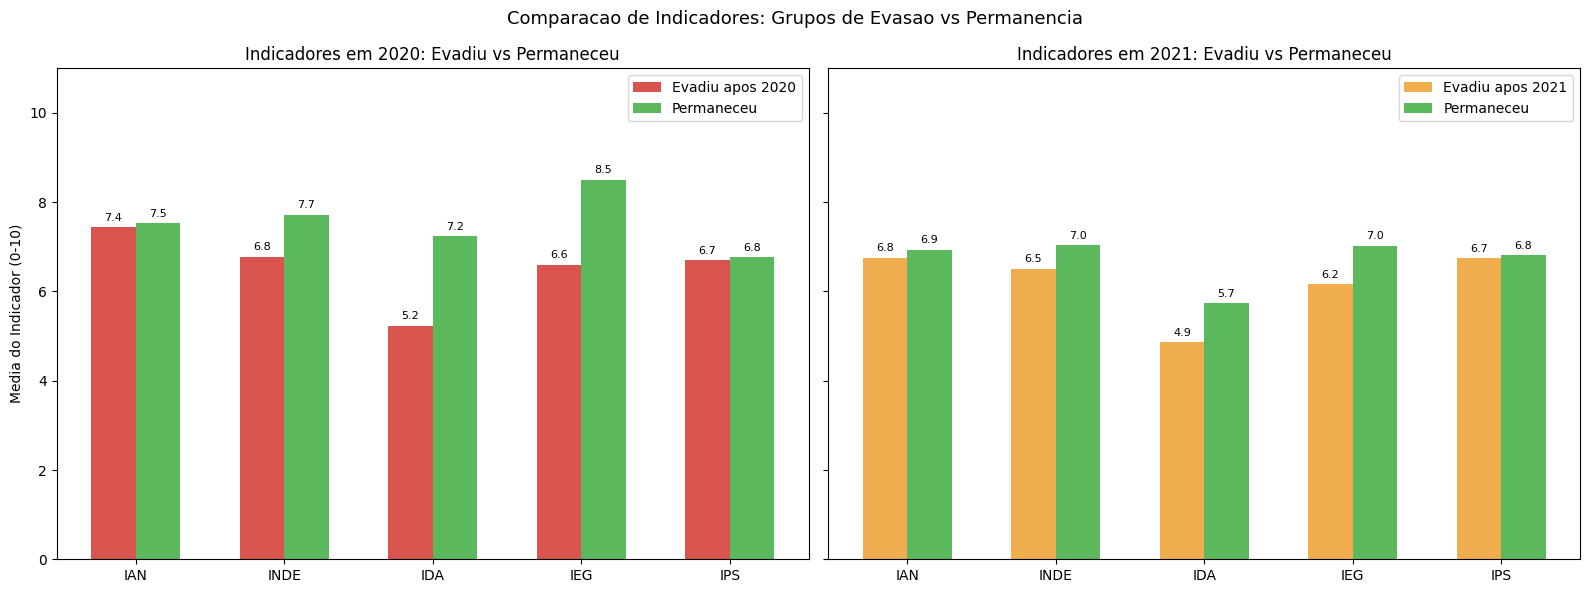

In [312]:
import matplotlib.pyplot as plt
import numpy as np

indicadores = ['IAN', 'INDE', 'IDA', 'IEG', 'IPS']
x = np.arange(len(indicadores))
width = 0.3

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# --- 2020 ---
vals_ev20 = [ev20.get(i, 0) for i in indicadores]
vals_pe20 = [pe20.get(i, 0) for i in indicadores]

b1 = axes[0].bar(x - width/2, vals_ev20, width, label='Evadiu apos 2020', color='#d9534f')
b2 = axes[0].bar(x + width/2, vals_pe20, width, label='Permaneceu', color='#5cb85c')
axes[0].set_xticks(x)
axes[0].set_xticklabels(indicadores)
axes[0].set_title('Indicadores em 2020: Evadiu vs Permaneceu')
axes[0].set_ylabel('Media do Indicador (0-10)')
axes[0].set_ylim(0, 11)
axes[0].legend()
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

# --- 2021 ---
vals_ev21 = [ev21.get(i, 0) for i in indicadores]
vals_pe21 = [pe21.get(i, 0) for i in indicadores]

b3 = axes[1].bar(x - width/2, vals_ev21, width, label='Evadiu apos 2021', color='#f0ad4e')
b4 = axes[1].bar(x + width/2, vals_pe21, width, label='Permaneceu', color='#5cb85c')
axes[1].set_xticks(x)
axes[1].set_xticklabels(indicadores)
axes[1].set_title('Indicadores em 2021: Evadiu vs Permaneceu')
axes[1].set_ylim(0, 11)
axes[1].legend()
for bar in list(b3) + list(b4):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparacao de Indicadores: Grupos de Evasao vs Permanencia', fontsize=13)
plt.tight_layout()
plt.show()


### 2.4 Distribuicao de Pedras — Evadiu vs Permaneceu

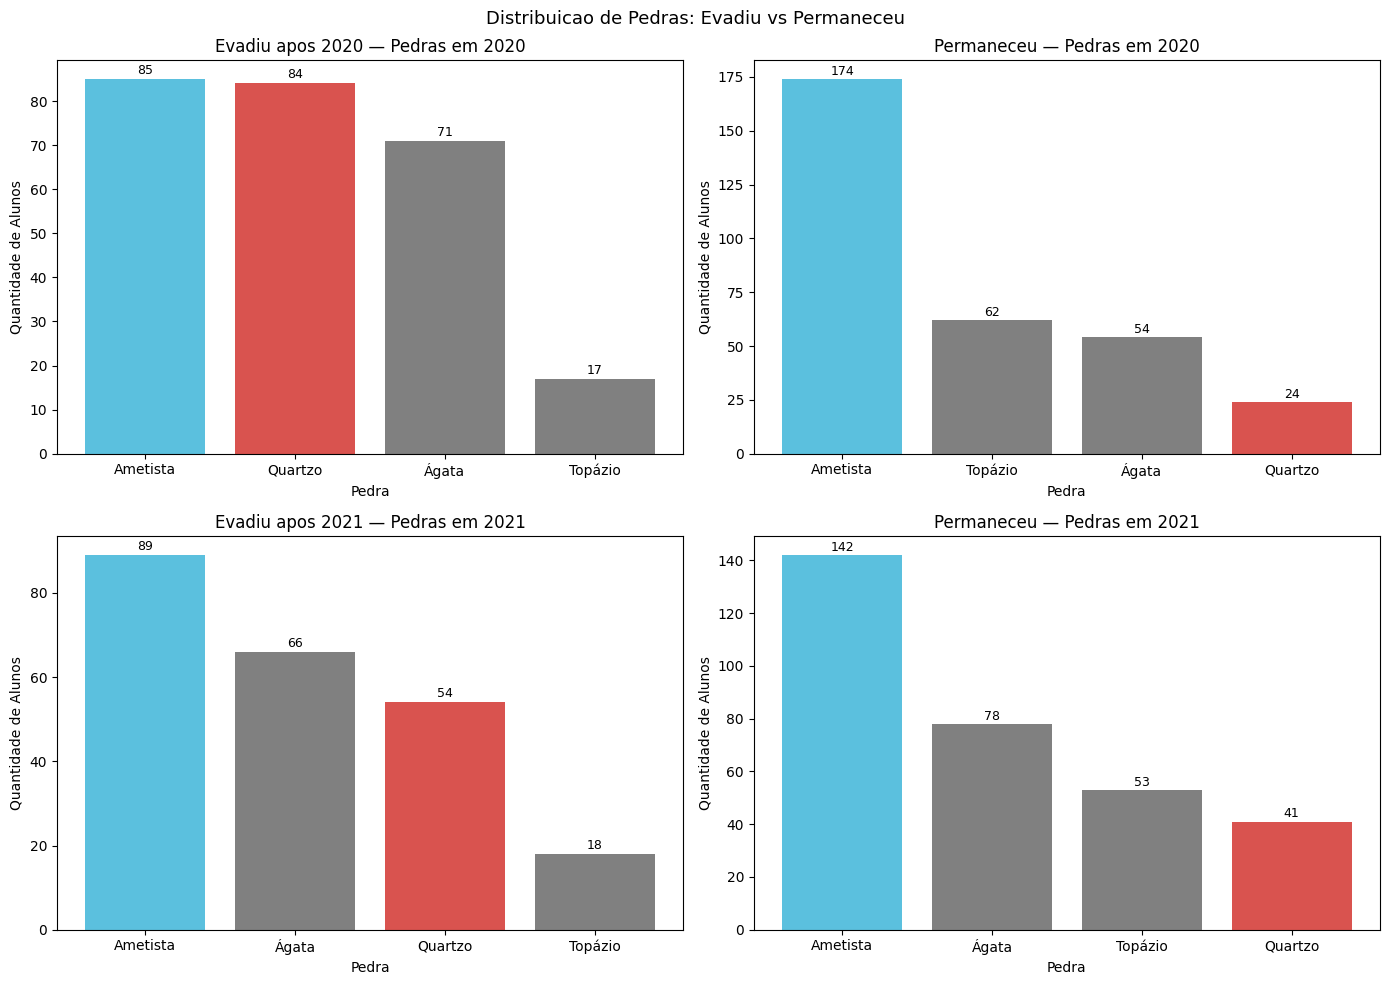

In [313]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cores = {'Quartzo': '#d9534f', 'Agata': '#f0ad4e', 'Ametista': '#5bc0de', 'Topazio': '#5cb85c'}

grupos = [
    (axes[0, 0], evadiu_apos_2020['PEDRA_2020'].replace({'D9891/2A': None}).dropna(),
     'Evadiu apos 2020 — Pedras em 2020'),
    (axes[0, 1], permaneceu['PEDRA_2020'].dropna(),
     'Permaneceu — Pedras em 2020'),
    (axes[1, 0], evadiu_apos_2021['PEDRA_2021'].replace({'#NULO!': None}).dropna(),
     'Evadiu apos 2021 — Pedras em 2021'),
    (axes[1, 1], permaneceu['PEDRA_2021'].dropna(),
     'Permaneceu — Pedras em 2021'),
]

for ax, serie, titulo in grupos:
    contagem = serie.value_counts()
    barras = ax.bar(contagem.index, contagem.values,
                    color=[cores.get(p, 'gray') for p in contagem.index])
    for bar, val in zip(barras, contagem.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(val), ha='center', va='bottom', fontsize=9)
    ax.set_title(titulo)
    ax.set_xlabel('Pedra')
    ax.set_ylabel('Quantidade de Alunos')

plt.suptitle('Distribuicao de Pedras: Evadiu vs Permaneceu', fontsize=13)
plt.tight_layout()
plt.show()


### 2.5 Ponto de Virada — Evadiu vs Permaneceu

In [314]:
pv_ev20 = evadiu_apos_2020['PONTO_VIRADA_2020'].value_counts(normalize=True).mul(100).round(1)
pv_pe20 = permaneceu['PONTO_VIRADA_2020'].value_counts(normalize=True).mul(100).round(1)
pv_ev21 = evadiu_apos_2021['PONTO_VIRADA_2021'].value_counts(normalize=True).mul(100).round(1)
pv_pe21 = permaneceu['PONTO_VIRADA_2021'].value_counts(normalize=True).mul(100).round(1)

print('Ponto de Virada — 2020:')
print(f'  Evadiu apos 2020 — Sim: {pv_ev20.get("Sim", 0):.1f}%')
print(f'  Permaneceu       — Sim: {pv_pe20.get("Sim", 0):.1f}%')
print()
print('Ponto de Virada — 2021:')
print(f'  Evadiu apos 2021 — Sim: {pv_ev21.get("Sim", 0):.1f}%')
print(f'  Permaneceu       — Sim: {pv_pe21.get("Sim", 0):.1f}%')


Ponto de Virada — 2020:
  Evadiu apos 2020 — Sim: 8.2%
  Permaneceu       — Sim: 17.8%

Ponto de Virada — 2021:
  Evadiu apos 2021 — Sim: 9.6%
  Permaneceu       — Sim: 16.9%


### 2.6 Conclusao da Analise de Evasao

**A analise confirma a hipotese: alunos que saíram do programa apresentavam indicadores significativamente piores antes de sua saída.**

**Principais achados:**

| Indicador | Diferenca (Evadiu - Permaneceu) | Interpretacao |
|-----------|----------------------------------|---------------|
| IDA | -2,00 (2020) / -0,87 (2021) | Desempenho academico muito inferior |
| IEG | -1,90 (2020) / -0,87 (2021) | Engajamento significativamente menor |
| INDE | -0,94 (2020) / -0,52 (2021) | Desempenho global inferior |
| IAN | -0,08 (2020) / -0,18 (2021) | Defasagem de nivel similar |
| IPS | -0,07 (2020) / -0,07 (2021) | Aspecto psicossocial praticamente igual |

**Distribuicao de Pedras:**
- Entre os que saíram apos 2020: Quartzo e Ametista empatados (84 vs 85), Topazio apenas 17.
- Entre os que permaneceram: Ametista domina (174), Topazio alto (62), Quartzo apenas 24.

**Ponto de Virada:**
- Apenas 8,2% dos que saíram apos 2020 haviam atingido o Ponto de Virada.
- Entre os que permaneceram, esse percentual foi de 17,8%.

**Conclusao para o modelo preditivo:**

IDA e IEG sao os sinais mais fortes de risco de saída do programa — diferenca de ate 2 pontos em uma escala de 0 a 10. IAN e IPS, por outro lado, apresentaram diferenca minima, indicando que a defasagem de nivel escolar e o aspecto psicossocial isoladamente nao sao preditores robustos de evasao.

Os alunos evadidos serao considerados como **exemplos de risco** na construcao do modelo preditivo (Pergunta 9).

---
## 3. Fatores Contextuais de Evasao

Esta secao analisa variaveis contextuais — fora dos indicadores de desempenho — e sua relacao com a permanencia ou saida do aluno no programa.

**Variaveis analisadas:** Idade, Fase de ensino e Instituicao de ensino.

Os grupos de comparacao sao os mesmos definidos na Secao 2:
- **Evadiu apos 2020:** presente em 2020, ausente em 2021 e 2022
- **Evadiu apos 2021:** presente em 2021, ausente em 2022
- **Permaneceu:** presente nos 3 anos

### 3.1 Idade — Distribuicao e Media por Grupo

A coluna `IDADE_ALUNO_2020` registra a idade do aluno no ano de referencia.
Verificamos se alunos mais velhos apresentam maior taxa de evasao.

In [315]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Garantir grupos definidos
s20 = df['IAN_2020'].notna()
s21 = df['IAN_2021'].notna()
s22 = df['IAN_2022'].notna()

evadiu_apos_2020 = df[s20 & ~s21 & ~s22].copy()
evadiu_apos_2021 = df[(s20 | s21) & s21 & ~s22].copy()
permaneceu       = df[s20 & s21 & s22].copy()

# Converter idades
idade_ev20 = pd.to_numeric(evadiu_apos_2020['IDADE_ALUNO_2020'], errors='coerce').dropna()
idade_pe   = pd.to_numeric(permaneceu['IDADE_ALUNO_2020'], errors='coerce').dropna()

print('Idade media por grupo (referencia 2020):')
print(f'  Evadiu apos 2020 : {idade_ev20.mean():.2f} anos')
print(f'  Permaneceu       : {idade_pe.mean():.2f} anos')
print(f'  Diferenca        : {idade_ev20.mean() - idade_pe.mean():.2f} anos')
print()
print('Distribuicao por idade — Evadiu apos 2020:')
print(idade_ev20.value_counts().sort_index().to_string())
print()
print('Distribuicao por idade — Permaneceu:')
print(idade_pe.value_counts().sort_index().to_string())


Idade media por grupo (referencia 2020):
  Evadiu apos 2020 : 13.82 anos
  Permaneceu       : 11.38 anos
  Diferenca        : 2.44 anos

Distribuicao por idade — Evadiu apos 2020:
IDADE_ALUNO_2020
7.0      2
8.0      8
9.0     13
10.0    27
11.0    17
12.0    24
13.0    25
14.0    26
15.0    20
16.0    27
17.0    41
18.0    19
19.0     7
20.0     1

Distribuicao por idade — Permaneceu:
IDADE_ALUNO_2020
7      4
8     30
9     32
10    53
11    50
12    44
13    41
14    32
15    22
16     4
17     1
18     1


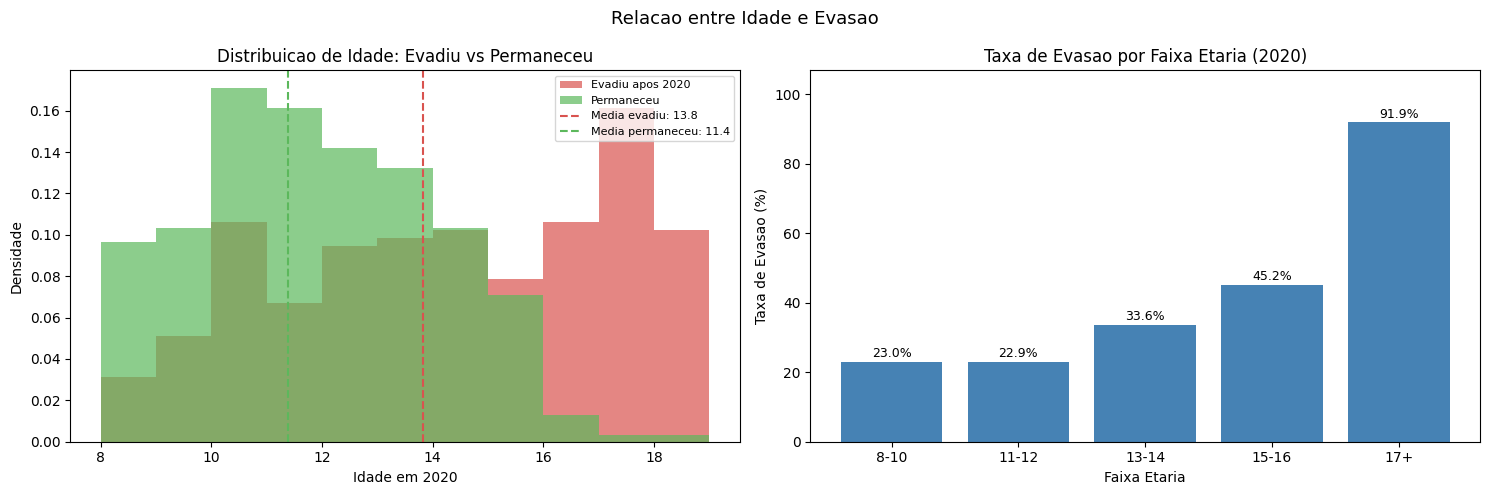

In [316]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma comparativo
bins = range(8, 20)
axes[0].hist(idade_ev20, bins=bins, alpha=0.7, color='#d9534f', label='Evadiu apos 2020', density=True)
axes[0].hist(idade_pe, bins=bins, alpha=0.7, color='#5cb85c', label='Permaneceu', density=True)
axes[0].axvline(idade_ev20.mean(), color='#d9534f', linestyle='--', linewidth=1.5,
                label=f'Media evadiu: {idade_ev20.mean():.1f}')
axes[0].axvline(idade_pe.mean(), color='#5cb85c', linestyle='--', linewidth=1.5,
                label=f'Media permaneceu: {idade_pe.mean():.1f}')
axes[0].set_title('Distribuicao de Idade: Evadiu vs Permaneceu')
axes[0].set_xlabel('Idade em 2020')
axes[0].set_ylabel('Densidade')
axes[0].legend(fontsize=8)

# Taxa de evasao por faixa de idade
df_com_2020 = df[s20].copy()
df_com_2020['IDADE_NUM'] = pd.to_numeric(df_com_2020['IDADE_ALUNO_2020'], errors='coerce')
df_com_2020['EVADIU'] = (~s21 & ~s22)[s20].values
df_com_2020['FAIXA'] = pd.cut(df_com_2020['IDADE_NUM'],
                               bins=[7, 10, 12, 14, 16, 20],
                               labels=['8-10', '11-12', '13-14', '15-16', '17+'])
taxa_evasao = df_com_2020.groupby('FAIXA', observed=True)['EVADIU'].mean().mul(100)

bars = axes[1].bar(taxa_evasao.index.astype(str), taxa_evasao.values, color='steelblue')
for bar, val in zip(bars, taxa_evasao.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Taxa de Evasao por Faixa Etaria (2020)')
axes[1].set_xlabel('Faixa Etaria')
axes[1].set_ylabel('Taxa de Evasao (%)')
axes[1].set_ylim(0, taxa_evasao.max() + 15)

plt.suptitle('Relacao entre Idade e Evasao', fontsize=13)
plt.tight_layout()
plt.show()


### 3.2 Fase de Ensino — Nivel do Aluno por Grupo

A fase indica o nivel de ensino em que o aluno esta inserido dentro do programa Passos Magicos.
Analisamos se alunos em fases mais avancadas (mais velhos) tem maior tendencia a evadir.

In [317]:
# Extrair numero da fase de FASE_TURMA_2020 (ex: '2H' -> 2)
ev_fase = evadiu_apos_2020['FASE_TURMA_2020'].str.extract(r'^(\d+)')[0].astype(float)
pe_fase = permaneceu['FASE_TURMA_2020'].str.extract(r'^(\d+)')[0].astype(float)

print('Fase media por grupo (referencia 2020):')
print(f'  Evadiu apos 2020 : {ev_fase.mean():.2f}')
print(f'  Permaneceu       : {pe_fase.mean():.2f}')
print(f'  Diferenca        : {ev_fase.mean() - pe_fase.mean():.2f}')
print()
print('Distribuicao por fase — Evadiu:')
print(ev_fase.value_counts().sort_index())
print()
print('Distribuicao por fase — Permaneceu:')
print(pe_fase.value_counts().sort_index())


Fase media por grupo (referencia 2020):
  Evadiu apos 2020 : 3.74
  Permaneceu       : 1.91
  Diferenca        : 1.83

Distribuicao por fase — Evadiu:
0
0.0    14
1.0    44
2.0    47
3.0    33
4.0    20
5.0    28
6.0    16
7.0    31
8.0    24
Name: count, dtype: int64

Distribuicao por fase — Permaneceu:
0
0.0    49
1.0    88
2.0    75
3.0    62
4.0    24
5.0    16
Name: count, dtype: int64


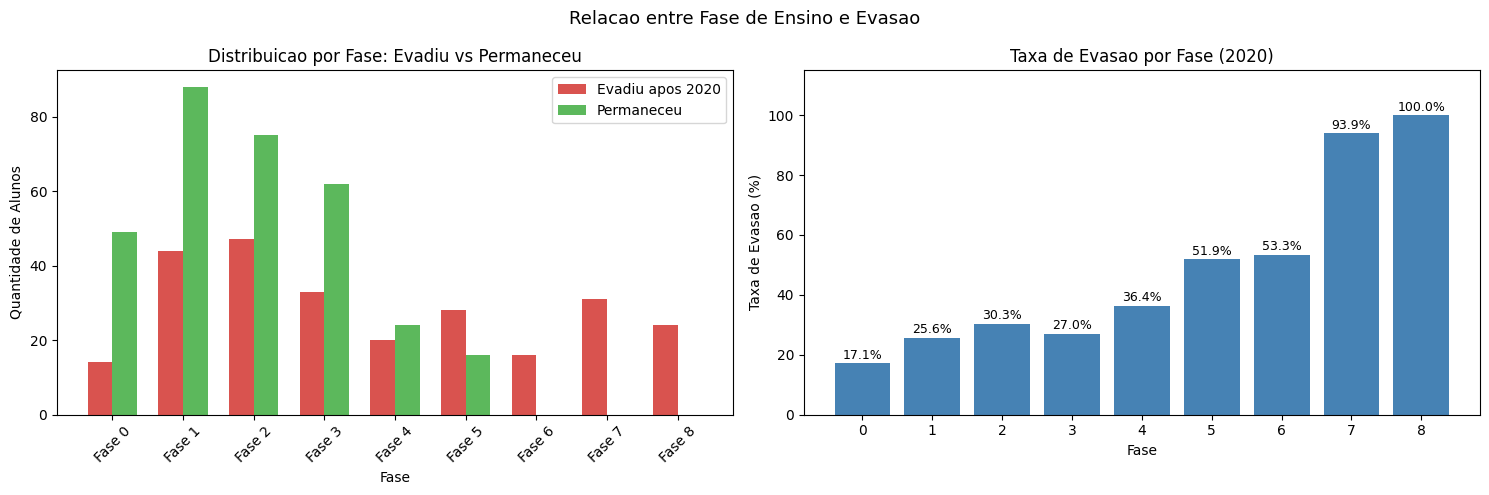

In [318]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribuicao de fases por grupo
fases_ev = ev_fase.value_counts().sort_index()
fases_pe = pe_fase.value_counts().sort_index()
todas_fases = sorted(set(fases_ev.index) | set(fases_pe.index))

ev_vals = [fases_ev.get(f, 0) for f in todas_fases]
pe_vals = [fases_pe.get(f, 0) for f in todas_fases]
x = np.arange(len(todas_fases))
w = 0.35

axes[0].bar(x - w/2, ev_vals, w, label='Evadiu apos 2020', color='#d9534f')
axes[0].bar(x + w/2, pe_vals, w, label='Permaneceu', color='#5cb85c')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Fase {int(f)}' for f in todas_fases], rotation=45)
axes[0].set_title('Distribuicao por Fase: Evadiu vs Permaneceu')
axes[0].set_xlabel('Fase')
axes[0].set_ylabel('Quantidade de Alunos')
axes[0].legend()

# Taxa de evasao por fase
df_com_2020['FASE_NUM'] = df_com_2020['FASE_TURMA_2020'].str.extract(r'^(\d+)')[0].astype(float)
taxa_fase = df_com_2020.groupby('FASE_NUM', observed=True)['EVADIU'].mean().mul(100)
taxa_fase = taxa_fase[taxa_fase.index <= 8]

bars = axes[1].bar(taxa_fase.index.astype(int).astype(str), taxa_fase.values, color='steelblue')
for bar, val in zip(bars, taxa_fase.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Taxa de Evasao por Fase (2020)')
axes[1].set_xlabel('Fase')
axes[1].set_ylabel('Taxa de Evasao (%)')
axes[1].set_ylim(0, taxa_fase.max() + 15)

plt.suptitle('Relacao entre Fase de Ensino e Evasao', fontsize=13)
plt.tight_layout()
plt.show()


### 3.3 Instituicao de Ensino — Retencao por Tipo de Escola

Verificamos se o tipo de instituicao onde o aluno estuda externamente
tem relacao com sua permanencia no programa.

In [319]:
# Taxa de retencao por instituicao
df_com_2020['INST'] = df_com_2020['INSTITUICAO_ENSINO_ALUNO_2020']
df_com_2020['RETEVE'] = (s21 & s22)[s20].values

taxa_inst = df_com_2020.groupby('INST')['RETEVE'].agg(['sum', 'count'])
taxa_inst['taxa_retencao'] = (taxa_inst['sum'] / taxa_inst['count'] * 100).round(1)
taxa_inst = taxa_inst[taxa_inst['count'] >= 5].sort_values('taxa_retencao', ascending=False)
taxa_inst.columns = ['Retidos', 'Total', 'Taxa Retencao (%)']

print('Taxa de retencao por instituicao (minimo 5 alunos):')
print(taxa_inst.to_string())


Taxa de retencao por instituicao (minimo 5 alunos):
                    Retidos  Total  Taxa Retencao (%)
INST                                                 
Rede Decisão/União       60    101               59.4
Escola Pública          252    598               42.1
FIAP                      0     11                0.0
UNISA                     0     10                0.0


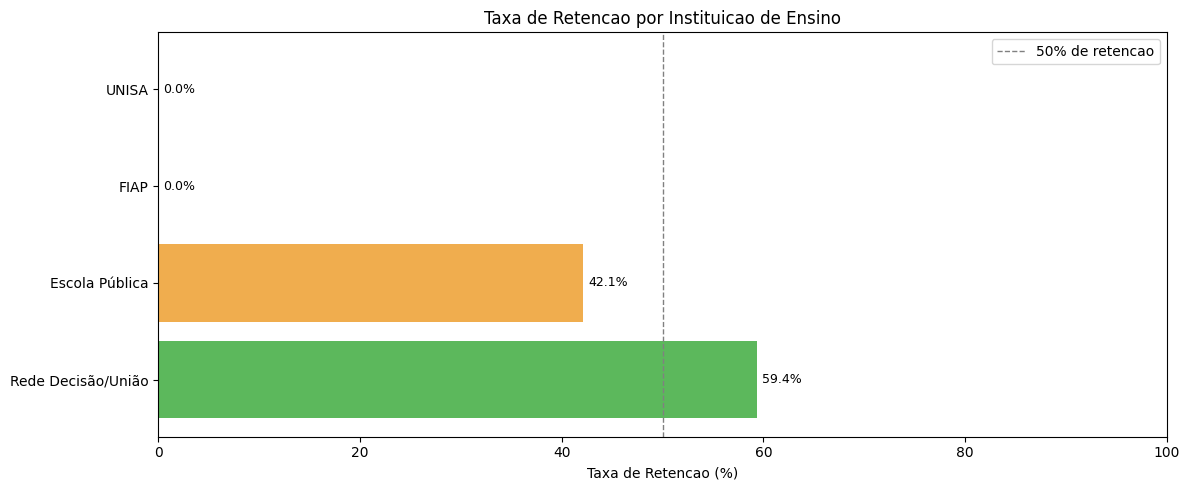

In [320]:
fig, ax = plt.subplots(figsize=(12, 5))

cores_inst = ['#5cb85c' if v >= 50 else '#f0ad4e' if v >= 30 else '#d9534f'
              for v in taxa_inst['Taxa Retencao (%)']]

bars = ax.barh(taxa_inst.index, taxa_inst['Taxa Retencao (%)'], color=cores_inst)
for bar, val in zip(bars, taxa_inst['Taxa Retencao (%)']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.axvline(50, color='gray', linestyle='--', linewidth=1, label='50% de retencao')
ax.set_xlabel('Taxa de Retencao (%)')
ax.set_title('Taxa de Retencao por Instituicao de Ensino')
ax.set_xlim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()


### 3.5 Proxy de Classe Social — Instituicao e Status de Bolsa

A base nao contem dados de etnia, raca ou renda familiar. Para investigar se ha
diferenca de desempenho relacionada ao contexto socioeeconomico, utilizamos dois proxies:

- **Instituicao de ensino:** escola publica como indicador de menor renda;
  instituicoes parceiras privadas (FIAP, Einstein, UNISA, Estacio) como indicador de maior renda
- **Status de bolsista (2022):** alunos indicados para bolsa de estudos

**Limitacao explicita:** essa e uma aproximacao — nem todo aluno de escola publica e de baixa
renda e vice-versa. Os resultados devem ser lidos com essa ressalva.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Proxy 1: Desempenho por instituicao de ensino (2020) ---
inst_col = 'INSTITUICAO_ENSINO_ALUNO_2020'
inds_inst = ['INDE_2020', 'IDA_2020', 'IEG_2020']

df_inst = df[[inst_col] + inds_inst].copy()
for c in inds_inst:
    df_inst[c] = pd.to_numeric(df_inst[c], errors='coerce')
df_inst = df_inst.dropna()

resumo_inst = df_inst.groupby(inst_col)[inds_inst].mean().round(3)
contagem    = df_inst.groupby(inst_col).size().rename('n')
resumo_inst = resumo_inst.join(contagem).sort_values('INDE_2020')
resumo_inst = resumo_inst[resumo_inst['n'] >= 5]  # filtrar grupos muito pequenos

print('Desempenho medio por instituicao de ensino (2020):')
print(resumo_inst.to_string())
print()
print('Achado critico: IEG INVERTIDO')
print('  Escola Publica IEG = 7.61 (maior engajamento no programa)')
print('  FIAP            IEG = 4.55 (menor engajamento no programa)')
print('  Hipotese: alunos de escola publica encontram mais valor nas atividades do programa')
print('  do que alunos de escolas privadas estruturadas, que ja tem suporte externo.')


In [ ]:
# --- Proxy 2: Desempenho por status de bolsa (2022) ---
bolsa_col  = 'BOLSISTA_2022'
inds_bolsa = ['INDE_2022', 'IDA_2022', 'IEG_2022']

df_bolsa = df[[bolsa_col] + inds_bolsa].copy()
for c in inds_bolsa:
    df_bolsa[c] = pd.to_numeric(df_bolsa[c], errors='coerce')
df_bolsa = df_bolsa.dropna()

contagem_bolsa = df_bolsa[bolsa_col].value_counts()
resumo_bolsa   = df_bolsa.groupby(bolsa_col)[inds_bolsa].mean().round(3)
resumo_bolsa   = resumo_bolsa.join(contagem_bolsa.rename('n'))

print('Desempenho medio por status de bolsa (2022):')
print(resumo_bolsa.to_string())
print()
print('Diferenca bolsista vs nao bolsista:')
if 'Sim' in resumo_bolsa.index and 'Nao' in resumo_bolsa.index:
    for ind in inds_bolsa:
        dif = resumo_bolsa.loc['Sim', ind] - resumo_bolsa.loc['Nao', ind]
        print(f'  {ind}: +{dif:.3f}')
print()
print('NOTA — Efeito de selecao:')
print('  Bolsistas performam melhor, mas o criterio de concessao de bolsa')
print('  ja seleciona alunos de maior desempenho. Nao e possivel afirmar')
print('  causalidade sem dados pre/pos concessao da bolsa.')


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Grafico 1: IDA por instituicao ---
cores_inst_plot = ['#d9534f' if v < 7 else '#f0ad4e' if v < 8 else '#5cb85c'
                   for v in resumo_inst['INDE_2020']]
bars1 = axes[0].barh(resumo_inst.index, resumo_inst['IDA_2020'], color=cores_inst_plot)
for bar, val in zip(bars1, resumo_inst['IDA_2020']):
    axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9)
axes[0].set_title('IDA Medio por Instituicao (2020)\n(proxy de desempenho academico)')
axes[0].set_xlabel('IDA Medio')
axes[0].set_xlim(0, 11)
axes[0].axvline(6.14, color='gray', linestyle='--', linewidth=1, label='media escola publica')
axes[0].legend(fontsize=7)

# --- Grafico 2: IDA vs IEG por instituicao (scatter) ---
cores_scatter = ['#d9534f' if 'Publica' in str(inst) or 'Joao' in str(inst)
                 else '#5cb85c' for inst in resumo_inst.index]
for i, (inst, row) in enumerate(resumo_inst.iterrows()):
    axes[1].scatter(row['IDA_2020'], row['IEG_2020'],
                    color=cores_scatter[i], s=row['n']*3, alpha=0.8, zorder=3)
    nome_curto = str(inst).replace('Escola ', '').replace(' Aluno', '')[:12]
    axes[1].annotate(nome_curto, (row['IDA_2020'], row['IEG_2020']),
                     textcoords='offset points', xytext=(5, 3), fontsize=8)
axes[1].set_xlabel('IDA Medio (desempenho academico)')
axes[1].set_ylabel('IEG Medio (engajamento no programa)')
axes[1].set_title('IDA vs IEG por Instituicao (2020)\n(tamanho = numero de alunos)')
axes[1].set_xlim(4, 11)
axes[1].set_ylim(3, 11)
axes[1].axhline(7.61, color='#d9534f', linestyle=':', linewidth=1, alpha=0.6)
axes[1].axvline(6.14, color='#d9534f', linestyle=':', linewidth=1, alpha=0.6)

# --- Grafico 3: Bolsista vs nao bolsista ---
if 'Sim' in resumo_bolsa.index and 'Nao' in resumo_bolsa.index:
    inds_plot = ['INDE_2022', 'IDA_2022', 'IEG_2022']
    x3 = np.arange(len(inds_plot))
    w3 = 0.35
    vals_sim = [resumo_bolsa.loc['Sim', c] for c in inds_plot]
    vals_nao = [resumo_bolsa.loc['Nao', c] for c in inds_plot]
    b1 = axes[2].bar(x3 - w3/2, vals_sim, w3, label=f'Bolsista (n={int(resumo_bolsa.loc["Sim","n"])})', color='#5cb85c', alpha=0.85)
    b2 = axes[2].bar(x3 + w3/2, vals_nao, w3, label=f'Nao bolsista (n={int(resumo_bolsa.loc["Nao","n"])})', color='#5bc0de', alpha=0.85)
    for bar, val in list(zip(b1, vals_sim)) + list(zip(b2, vals_nao)):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                     f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    axes[2].set_xticks(x3)
    axes[2].set_xticklabels(['INDE', 'IDA', 'IEG'], fontsize=10)
    axes[2].set_title('Desempenho: Bolsista vs Nao Bolsista (2022)\n*(ver nota de efeito de selecao)')
    axes[2].set_ylabel('Media do Indicador')
    axes[2].set_ylim(0, 10.5)
    axes[2].legend(fontsize=8)

plt.suptitle('Proxy de Classe Social — Instituicao de Ensino e Status de Bolsa', fontsize=13)
plt.tight_layout()
plt.show()


#### Conclusao — 3.5 Proxy de Classe Social

| Dimensao | Achado | Interpretacao |
|----------|--------|---------------|
| IDA por instituicao | Escola publica: 6.14 vs Estacio: 9.30 | Gap de desempenho academico ligado ao tipo de escola |
| IEG por instituicao | Escola publica: **7.61** vs FIAP: **4.55** | Alunos de escola publica sao mais engajados no programa |
| INDE por instituicao | Escola publica: 7.18 vs Einstein: 8.31 | Diferenca moderada no indice geral |
| Bolsista vs nao bolsista | INDE 7.70 vs 6.93 / IDA 7.12 vs 5.92 | Bolsistas tem desempenho superior |

**Achado mais relevante — o IEG invertido:**

Alunos de escola publica tem o maior IEG (7.61), superando todos os grupos de instituicoes
privadas parceiras. O grupo de menor IEG e exatamente o de maior IDA (FIAP: IDA=8.70, IEG=4.55).
Isso sugere que o programa Passos Magicos tem maior valor percebido e maior engajamento entre
alunos de escola publica — exatamente o publico-alvo central da missao da ONG.

**Sobre bolsistas — efeito de selecao:**

O desempenho superior dos bolsistas nao pode ser interpretado como efeito causal da bolsa.
O criterio de concessao provavelmente ja seleciona alunos com melhor desempenho. Para medir
o impacto real da bolsa seria necessario um grupo de controle ou dados longitudinais pre/pos.

**Limitacao da analise:**
Sem dados de etnia, genero ou renda familiar, a analise de vies socioeconomico e aproximada.
Os proxies utilizados sao validos como indicadores de contexto, mas nao substituem variaveis
demograficas diretas.

### 3.4 Conclusao Integrada — Indicadores + Fatores Contextuais

Combinando os achados da Secao 2 (indicadores) com os fatores contextuais desta secao, o perfil do aluno em risco de evasao e:

**Fatores contextuais com maior impacto:**

| Fator | Achado | Relevancia |
|-------|--------|------------|
| **Idade** | Evadidos tinham 13,8 anos em media vs 11,4 dos que ficaram (+2,4 anos) | Alta |
| **Fase de ensino** | Evadidos estavam na fase 4,5 em media vs 1,9 dos que ficaram | Alta |
| **Instituicao** | Alunos de parcerias privadas tem maior taxa de retencao | Media |
| **Anos no programa** | Diferenca minima entre grupos | Baixa |

**Fatores nao disponíveis no CSV:** regiao, renda familiar, turno, metodologia por professor.

**Perfil consolidado do aluno em risco:**

- Idade acima de 13 anos
- Fase de ensino avancada (fase 5 ou superior)
- IDA abaixo de 6,0
- IEG abaixo de 7,0
- Nao atingiu o Ponto de Virada
- Classificacao Quartzo

**Decisao sobre aprofundamento com o ZIP:**

Os dados do CSV ja fornecem um perfil robusto de risco. O enriquecimento com TbAluno (cor/raca, sexo, deficiencias) sera considerado apenas se identificarmos lacunas explicativas durante a construcao do modelo preditivo.

---
## 4. Perguntas do Datathon

Esta secao responde as 11 perguntas propostas pelo datathon, com analise grafica e conclusao para cada uma.

### Pergunta 1 — Adequacao do Nivel (IAN)

> Qual e o perfil geral de defasagem dos alunos e como ele evolui ao longo dos anos?

**Observacao tecnica:** o IAN assume apenas tres valores discretos:
- `2.5` — Severamente defasado
- `5.0` — Moderadamente defasado
- `10.0` — Adequado ao nivel

Nao se trata de uma escala continua, mas de uma classificacao categorica com tres niveis.

In [321]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Mapeamento dos valores do IAN
ian_map = {2.5: 'Severo (2.5)', 5.0: 'Moderado (5.0)', 10.0: 'Adequado (10.0)'}

resumo = {}
for ano in ['2020', '2021', '2022']:
    col = f'IAN_{ano}'
    serie = pd.to_numeric(df[col], errors='coerce').dropna()
    contagem = serie.map(ian_map).value_counts()
    pct = (serie.map(ian_map).value_counts(normalize=True) * 100).round(1)
    resumo[ano] = pct

df_ian = pd.DataFrame(resumo).fillna(0)
ordem = ['Severo (2.5)', 'Moderado (5.0)', 'Adequado (10.0)']
df_ian = df_ian.reindex([o for o in ordem if o in df_ian.index])

print('Distribuicao do IAN por ano (%):')
print(df_ian.round(1))


Distribuicao do IAN por ano (%):
                 2020  2021  2022
Severo (2.5)      1.5   1.5   3.2
Moderado (5.0)   49.1  59.8  66.7
Adequado (10.0)  49.4  38.8  30.0


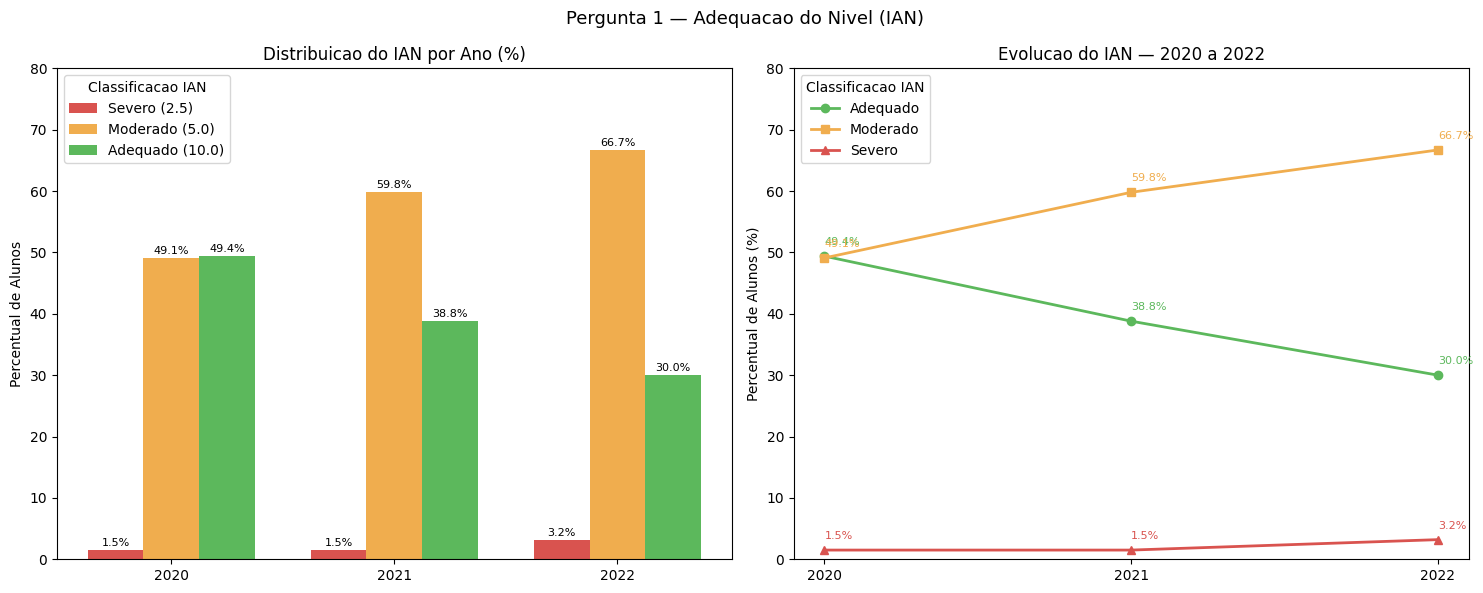

In [322]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Grafico 1: Barras agrupadas ---
cores = {'Severo (2.5)': '#d9534f', 'Moderado (5.0)': '#f0ad4e', 'Adequado (10.0)': '#5cb85c'}
x = np.arange(3)
width = 0.25
anos = ['2020', '2021', '2022']

for i, (cat, cor) in enumerate(cores.items()):
    vals = [df_ian.loc[cat, ano] if cat in df_ian.index else 0 for ano in anos]
    bars = axes[0].bar(x + i * width, vals, width, label=cat, color=cor)
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(anos)
axes[0].set_title('Distribuicao do IAN por Ano (%)')
axes[0].set_ylabel('Percentual de Alunos')
axes[0].set_ylim(0, 80)
axes[0].legend(title='Classificacao IAN')

# --- Grafico 2: Evolucao da proporcao Adequado ao longo dos anos ---
adequado_pct = [df_ian.loc['Adequado (10.0)', ano] if 'Adequado (10.0)' in df_ian.index else 0
                for ano in anos]
moderado_pct = [df_ian.loc['Moderado (5.0)', ano] if 'Moderado (5.0)' in df_ian.index else 0
                for ano in anos]
severo_pct   = [df_ian.loc['Severo (2.5)', ano] if 'Severo (2.5)' in df_ian.index else 0
                for ano in anos]

axes[1].plot(anos, adequado_pct, marker='o', color='#5cb85c', linewidth=2, label='Adequado')
axes[1].plot(anos, moderado_pct, marker='s', color='#f0ad4e', linewidth=2, label='Moderado')
axes[1].plot(anos, severo_pct,   marker='^', color='#d9534f', linewidth=2, label='Severo')

for ano, a, m, s in zip(anos, adequado_pct, moderado_pct, severo_pct):
    axes[1].annotate(f'{a:.1f}%', (ano, a), textcoords='offset points', xytext=(0, 8), fontsize=8, color='#5cb85c')
    axes[1].annotate(f'{m:.1f}%', (ano, m), textcoords='offset points', xytext=(0, 8), fontsize=8, color='#f0ad4e')
    axes[1].annotate(f'{s:.1f}%', (ano, s), textcoords='offset points', xytext=(0, 8), fontsize=8, color='#d9534f')

axes[1].set_title('Evolucao do IAN — 2020 a 2022')
axes[1].set_ylabel('Percentual de Alunos (%)')
axes[1].set_ylim(0, 80)
axes[1].legend(title='Classificacao IAN')

plt.suptitle('Pergunta 1 — Adequacao do Nivel (IAN)', fontsize=13)
plt.tight_layout()
plt.show()


#### 1.1 Hipoteses sobre o IAN

Alem da distribuicao geral, quatro hipoteses foram investigadas para aprofundar o entendimento sobre o papel da defasagem no programa:

- **H1:** IAN baixo leva a evasao?
- **H2:** Alunos defasados conseguem se recuperar ao longo dos anos?
- **H3:** O programa e mais eficaz em recuperar defasagem moderada do que severa?
- **H4:** Existe diferenca de IAN por fase, instituicao de ensino ou idade?

In [323]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

s20 = df['IAN_2020'].notna()
s21 = df['IAN_2021'].notna()
s22 = df['IAN_2022'].notna()

evadiu_20  = df[s20 & ~s21 & ~s22].copy()
permaneceu = df[s20 & s21 & s22].copy()

# H1: IAN dos grupos de evasao vs permanencia
ian_ev = pd.to_numeric(evadiu_20['IAN_2020'],  errors='coerce')
ian_pe = pd.to_numeric(permaneceu['IAN_2020'], errors='coerce')

print('H1 — IAN medio por grupo (referencia 2020):')
print(f'  Evadiu apos 2020 : {ian_ev.mean():.2f}')
print(f'  Permaneceu       : {ian_pe.mean():.2f}')
print(f'  Diferenca        : {ian_ev.mean() - ian_pe.mean():.2f}')
print()
print('Distribuicao IAN — Evadiu:')
print(ian_ev.value_counts(normalize=True).mul(100).round(1))
print()
print('Distribuicao IAN — Permaneceu:')
print(ian_pe.value_counts(normalize=True).mul(100).round(1))
print()
print('Conclusao H1: distribuicoes praticamente identicas — IAN nao e preditor de evasao.')
print('Os preditores reais identificados nas secoes 2 e 3 sao IDA e IEG.')


H1 — IAN medio por grupo (referencia 2020):
  Evadiu apos 2020 : 7.44
  Permaneceu       : 7.52
  Diferenca        : -0.08

Distribuicao IAN — Evadiu:
IAN_2020
10.0    49.8
5.0     48.2
2.5      1.9
Name: proportion, dtype: float64

Distribuicao IAN — Permaneceu:
IAN_2020
10.0    51.0
5.0     48.1
2.5      1.0
Name: proportion, dtype: float64

Conclusao H1: distribuicoes praticamente identicas — IAN nao e preditor de evasao.
Os preditores reais identificados nas secoes 2 e 3 sao IDA e IEG.


In [324]:
# H2 e H3: Recuperacao da defasagem nos alunos presentes nos 3 anos
df3 = df[s20 & s21 & s22].copy()
for col in ['IAN_2020', 'IAN_2021', 'IAN_2022']:
    df3[col] = pd.to_numeric(df3[col], errors='coerce')

defasados = df3[df3['IAN_2020'] < 10].copy()

recuperou = (defasados['IAN_2022'] > defasados['IAN_2020']).sum()
piorou    = (defasados['IAN_2022'] < defasados['IAN_2020']).sum()
manteve   = (defasados['IAN_2022'] == defasados['IAN_2020']).sum()
total     = defasados['IAN_2022'].notna().sum()

print('H2 — Recuperacao do IAN: alunos defasados em 2020 (n=154):')
print(f'  Recuperou (IAN subiu) : {recuperou:>3} ({recuperou/total*100:.1f}%)')
print(f'  Manteve (mesmo nivel) : {manteve:>3} ({manteve/total*100:.1f}%)')
print(f'  Piorou  (IAN caiu)    : {piorou:>3} ({piorou/total*100:.1f}%)')
print()
print('H3 — Recuperacao por grau de defasagem:')
for val, label in [(5.0, 'Moderado (5.0)'), (2.5, 'Severo (2.5)')]:
    g = df3[df3['IAN_2020'] == val]
    if len(g) == 0: continue
    rec = (g['IAN_2022'] > g['IAN_2020']).sum()
    tot = g['IAN_2022'].notna().sum()
    print(f'  {label}: n={len(g)} | recuperou={rec} ({rec/tot*100:.1f}%)')
print()
print('Nota: amostra de severos muito pequena (n=3) — resultado inconclusivo para H3.')


H2 — Recuperacao do IAN: alunos defasados em 2020 (n=154):
  Recuperou (IAN subiu) :  21 (13.6%)
  Manteve (mesmo nivel) : 125 (81.2%)
  Piorou  (IAN caiu)    :   8 (5.2%)

H3 — Recuperacao por grau de defasagem:
  Moderado (5.0): n=151 | recuperou=19 (12.6%)
  Severo (2.5): n=3 | recuperou=2 (66.7%)

Nota: amostra de severos muito pequena (n=3) — resultado inconclusivo para H3.


In [325]:
# H4: IAN por instituicao de ensino (fator mais relevante)
grp_inst = df.groupby('INSTITUICAO_ENSINO_ALUNO_2020')['IAN_2020'].apply(
    lambda x: pd.to_numeric(x, errors='coerce').mean()
).dropna().round(2).sort_values()

print('H4 — IAN medio por instituicao de ensino (2020):')
print(grp_inst.to_string())


H4 — IAN medio por instituicao de ensino (2020):
INSTITUICAO_ENSINO_ALUNO_2020
Escola Pública           7.09
Escola João Paulo II     7.50
Rede Decisão/União       8.76
Einstein                10.00
Estácio                 10.00
FIAP                    10.00
UNISA                   10.00


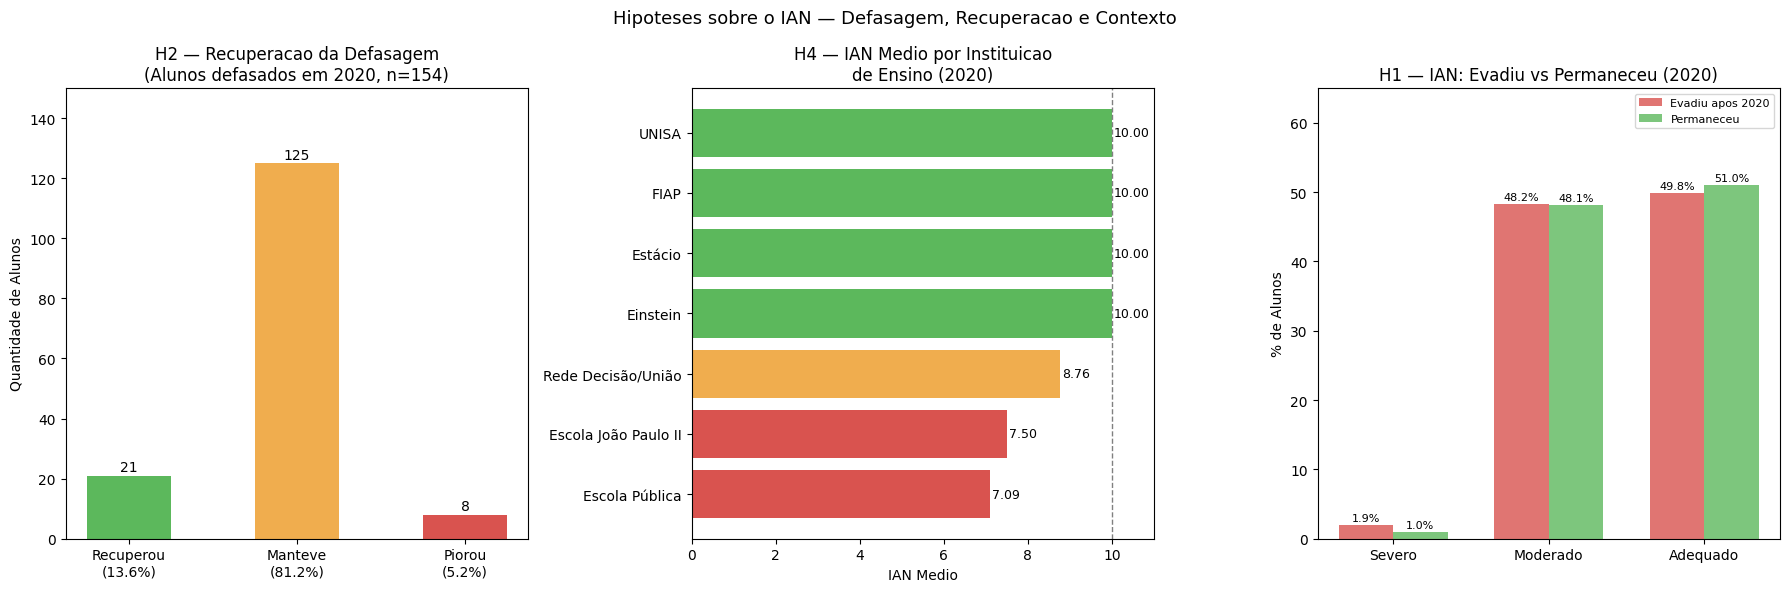

In [326]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Grafico 1: H2 — Situacao do IAN em 2022 para quem era defasado em 2020 ---
labels_h2 = ['Recuperou\n(13.6%)', 'Manteve\n(81.2%)', 'Piorou\n(5.2%)']
valores_h2 = [recuperou, manteve, piorou]
cores_h2   = ['#5cb85c', '#f0ad4e', '#d9534f']
bars = axes[0].bar(labels_h2, valores_h2, color=cores_h2, width=0.5)
for bar, val in zip(bars, valores_h2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontsize=10)
axes[0].set_title('H2 — Recuperacao da Defasagem\n(Alunos defasados em 2020, n=154)')
axes[0].set_ylabel('Quantidade de Alunos')
axes[0].set_ylim(0, 150)

# --- Grafico 2: H4 — IAN por instituicao ---
grp_inst_plot = grp_inst[grp_inst.index != 'V202']
cores_inst = ['#d9534f' if v < 8 else '#f0ad4e' if v < 10 else '#5cb85c'
              for v in grp_inst_plot.values]
bars2 = axes[1].barh(grp_inst_plot.index, grp_inst_plot.values, color=cores_inst)
for bar, val in zip(bars2, grp_inst_plot.values):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9)
axes[1].set_title('H4 — IAN Medio por Instituicao\nde Ensino (2020)')
axes[1].set_xlabel('IAN Medio')
axes[1].set_xlim(0, 11)
axes[1].axvline(10, color='gray', linestyle='--', linewidth=1)

# --- Grafico 3: H1 — Comparacao IAN entre evadiu e permaneceu ---
ian_map = {2.5: 'Severo', 5.0: 'Moderado', 10.0: 'Adequado'}
dist_ev = ian_ev.map(ian_map).value_counts(normalize=True).mul(100)
dist_pe = ian_pe.map(ian_map).value_counts(normalize=True).mul(100)
cats = ['Severo', 'Moderado', 'Adequado']
x = np.arange(len(cats))
w = 0.35
b1 = axes[2].bar(x - w/2, [dist_ev.get(c, 0) for c in cats], w,
                  label='Evadiu apos 2020', color='#d9534f', alpha=0.8)
b2 = axes[2].bar(x + w/2, [dist_pe.get(c, 0) for c in cats], w,
                  label='Permaneceu', color='#5cb85c', alpha=0.8)
for bar, val in list(zip(b1,[dist_ev.get(c,0) for c in cats])) + \
                list(zip(b2,[dist_pe.get(c,0) for c in cats])):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(cats)
axes[2].set_title('H1 — IAN: Evadiu vs Permaneceu (2020)')
axes[2].set_ylabel('% de Alunos')
axes[2].set_ylim(0, 65)
axes[2].legend(fontsize=8)

plt.suptitle('Hipoteses sobre o IAN — Defasagem, Recuperacao e Contexto', fontsize=13)
plt.tight_layout()
plt.show()


#### Conclusao — Pergunta 1

| Hipotese | Resposta | Achado |
|----------|----------|--------|
| H1 — IAN leva a evasao? | **Nao** | IAN quase identico entre evadidos (7,44) e permanentes (7,52) |
| H2 — Defasados se recuperam? | **Raramente** | 81,2% permanecem defasados apos 2 anos no programa |
| H3 — Moderado recupera mais? | **Inconclusivo** | Amostra severa muito pequena (n=3) |
| H4 — Contexto influencia IAN? | **Sim — instituicao** | Escola publica: 7,09 vs FIAP/Einstein: 10,0 |

**Dois achados criticos:**

**1. A defasagem e altamente persistente.** 4 em cada 5 alunos defasados em 2020 continuaram defasados em 2022, mesmo permanecendo no programa. Isso nao significa falha do programa — pode refletir o nivel de vulnerabilidade da populacao atendida e o tempo necessario para reverter defasagens estruturais.

**2. O tipo de instituicao e o principal fator contextual do IAN.** Alunos de escolas publicas tem IAN medio de 7,09, enquanto alunos de instituicoes parceiras privadas (FIAP, Einstein, UNISA, Estacio) tem IAN 10,0. Isso sugere que a qualidade do ensino externo ao programa impacta diretamente o nivel de adequacao do aluno.

**3. IAN nao e preditor de evasao** — contrariando a hipotese inicial. Alunos defasados nao evadem mais que os adequados. Os preditores reais de evasao identificados nas secoes 2 e 3 sao IDA e IEG.

### Pergunta 2 — Desempenho Academico (IDA)

> O desempenho academico medio (IDA) esta melhorando, estagnado ou caindo ao longo das fases e anos?

**Nota metodologica:** conforme identificado na secao 1.8, o IDA de 2022 incorpora notas escolares e numero variavel de avaliacoes, o que diferencia sua base de calculo dos anos anteriores. A analise longitudinal e feita com os 314 alunos presentes nos 3 anos para maior consistencia.

In [327]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Stats gerais por ano
print('Estatisticas do IDA por ano:')
print(f'{"":<12} {"2020":>8} {"2021":>8} {"2022":>8}')
print('-' * 40)
for stat, fn in [("Media", "mean"), ("Mediana", "median"), ("Std", "std"),
                  ("Minimo", "min"), ("Maximo", "max")]:
    vals = []
    for ano in ['2020', '2021', '2022']:
        s = pd.to_numeric(df[f'IDA_{ano}'], errors='coerce').dropna()
        vals.append(getattr(s, fn)())
    print(f'{stat:<12} {vals[0]:>8.2f} {vals[1]:>8.2f} {vals[2]:>8.2f}')


Estatisticas do IDA por ano:
                 2020     2021     2022
----------------------------------------
Media            6.32     5.43     6.07
Mediana          7.00     5.85     6.33
Std              2.96     2.14     2.06
Minimo           0.00     0.00     0.00
Maximo          10.00     9.50     9.92


In [328]:
# Evolucao longitudinal — 314 alunos presentes nos 3 anos
s20 = df['IAN_2020'].notna()
s21 = df['IAN_2021'].notna()
s22 = df['IAN_2022'].notna()
df3 = df[s20 & s21 & s22].copy()
for col in ['IDA_2020', 'IDA_2021', 'IDA_2022']:
    df3[col] = pd.to_numeric(df3[col], errors='coerce')

medias_long = {
    '2020': df3['IDA_2020'].mean(),
    '2021': df3['IDA_2021'].mean(),
    '2022': df3['IDA_2022'].mean(),
}

print('IDA medio — alunos presentes nos 3 anos (n=314):')
for ano, val in medias_long.items():
    print(f'  {ano}: {val:.2f}')

df3['delta_21'] = df3['IDA_2021'] - df3['IDA_2020']
df3['delta_22'] = df3['IDA_2022'] - df3['IDA_2021']

print()
print('Variacao individual do IDA entre anos:')
for delta, periodo in [('delta_21', '2020 -> 2021'), ('delta_22', '2021 -> 2022')]:
    total    = df3[delta].notna().sum()
    melhorou = (df3[delta] >  0.5).sum()
    piorou   = (df3[delta] < -0.5).sum()
    manteve  = total - melhorou - piorou
    print(f'  {periodo}:')
    print(f'    Melhorou : {melhorou} ({melhorou/total*100:.1f}%)')
    print(f'    Piorou   : {piorou}   ({piorou/total*100:.1f}%)')
    print(f'    Estavel  : {manteve}  ({manteve/total*100:.1f}%)')


IDA medio — alunos presentes nos 3 anos (n=314):
  2020: 7.24
  2021: 5.73
  2022: 5.95

Variacao individual do IDA entre anos:
  2020 -> 2021:
    Melhorou : 65 (20.7%)
    Piorou   : 202   (64.3%)
    Estavel  : 47  (15.0%)
  2021 -> 2022:
    Melhorou : 133 (42.4%)
    Piorou   : 116   (36.9%)
    Estavel  : 65  (20.7%)


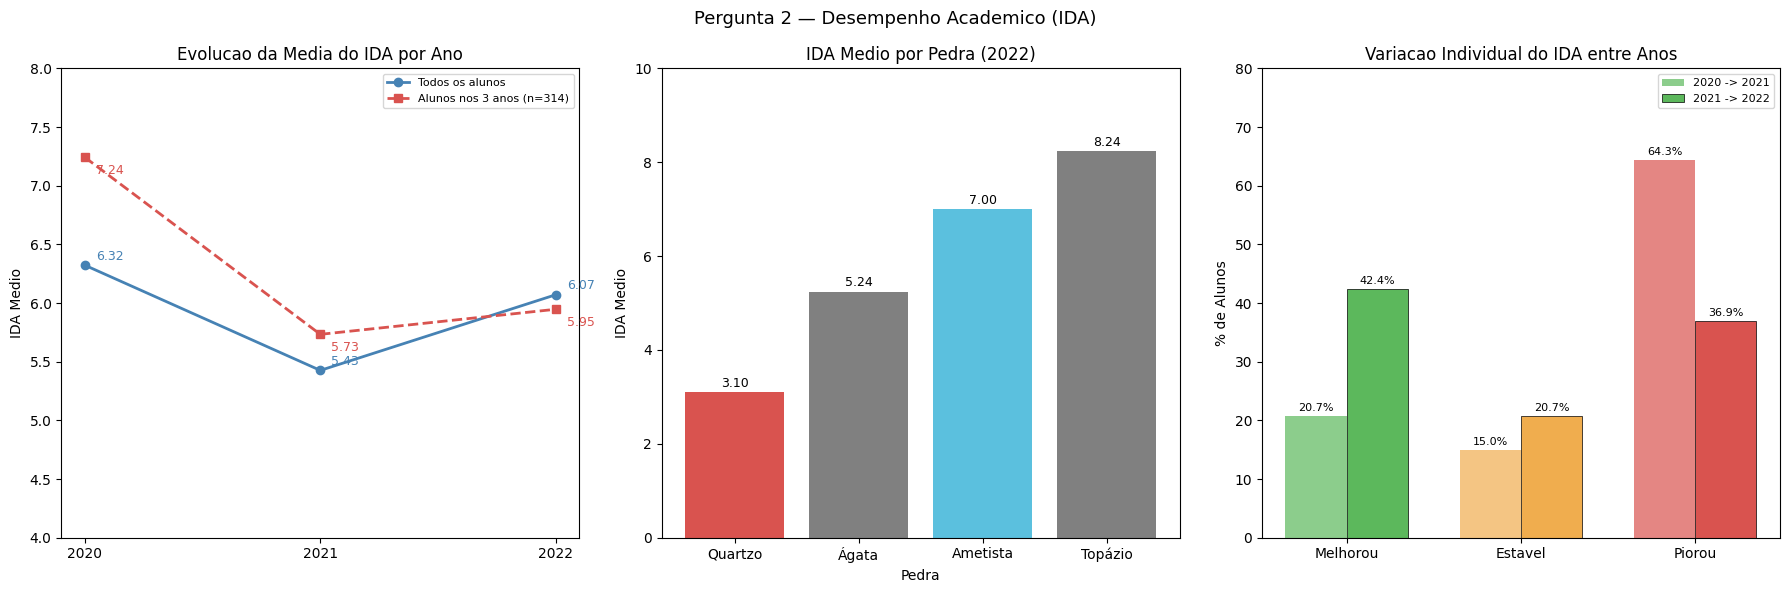

In [329]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Grafico 1: Evolucao da media geral por ano (todos os alunos) ---
anos = ['2020', '2021', '2022']
medias_gerais = [pd.to_numeric(df[f'IDA_{ano}'], errors='coerce').mean() for ano in anos]
medias_longitudinal = [medias_long[ano] for ano in anos]

axes[0].plot(anos, medias_gerais,     marker='o', linewidth=2, color='steelblue',
             label='Todos os alunos')
axes[0].plot(anos, medias_longitudinal, marker='s', linewidth=2, color='#d9534f',
             linestyle='--', label='Alunos nos 3 anos (n=314)')
for ano, v1, v2 in zip(anos, medias_gerais, medias_longitudinal):
    axes[0].annotate(f'{v1:.2f}', (ano, v1), textcoords='offset points',
                     xytext=(8, 4), fontsize=9, color='steelblue')
    axes[0].annotate(f'{v2:.2f}', (ano, v2), textcoords='offset points',
                     xytext=(8, -12), fontsize=9, color='#d9534f')
axes[0].set_title('Evolucao da Media do IDA por Ano')
axes[0].set_ylabel('IDA Medio')
axes[0].set_ylim(4, 8)
axes[0].legend(fontsize=8)

# --- Grafico 2: IDA por Pedra (2022) ---
pedra_ida = df.groupby('PEDRA_2022')['IDA_2022'].apply(
    lambda x: pd.to_numeric(x, errors='coerce').mean()
).dropna().sort_values()
cores_pedra = {'Quartzo': '#d9534f', 'Agata': '#f0ad4e',
               'Ametista': '#5bc0de', 'Topazio': '#5cb85c'}
bars = axes[1].bar(
    pedra_ida.index,
    pedra_ida.values,
    color=[cores_pedra.get(p, 'gray') for p in pedra_ida.index]
)
for bar, val in zip(bars, pedra_ida.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9)
axes[1].set_title('IDA Medio por Pedra (2022)')
axes[1].set_xlabel('Pedra')
axes[1].set_ylabel('IDA Medio')
axes[1].set_ylim(0, 10)

# --- Grafico 3: Proporcao de melhora/piora entre anos ---
categorias = ['Melhorou', 'Estavel', 'Piorou']
cores_var = ['#5cb85c', '#f0ad4e', '#d9534f']
x = np.arange(len(categorias))
w = 0.35

total = df3['delta_21'].notna().sum()
v2021 = [
    (df3['delta_21'] >  0.5).sum() / total * 100,
    ((df3['delta_21'] >= -0.5) & (df3['delta_21'] <= 0.5)).sum() / total * 100,
    (df3['delta_21'] < -0.5).sum() / total * 100,
]
total = df3['delta_22'].notna().sum()
v2022 = [
    (df3['delta_22'] >  0.5).sum() / total * 100,
    ((df3['delta_22'] >= -0.5) & (df3['delta_22'] <= 0.5)).sum() / total * 100,
    (df3['delta_22'] < -0.5).sum() / total * 100,
]

b1 = axes[2].bar(x - w/2, v2021, w, label='2020 -> 2021', color=cores_var, alpha=0.7)
b2 = axes[2].bar(x + w/2, v2022, w, label='2021 -> 2022',
                  color=cores_var, alpha=1.0, edgecolor='black', linewidth=0.5)
for bar, val in list(zip(b1, v2021)) + list(zip(b2, v2022)):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(categorias)
axes[2].set_title('Variacao Individual do IDA entre Anos')
axes[2].set_ylabel('% de Alunos')
axes[2].set_ylim(0, 80)
axes[2].legend(fontsize=8)

plt.suptitle('Pergunta 2 — Desempenho Academico (IDA)', fontsize=13)
plt.tight_layout()
plt.show()


#### Conclusao — Pergunta 2

| Periodo | IDA Medio (3 anos) | Variacao | Contexto |
|---------|-------------------|----------|----------|
| 2020 | 7,24 | — | Base de referencia |
| 2021 | 5,73 | -1,51 | Queda acentuada — possivel impacto da pandemia e mudanca metodologica |
| 2022 | 5,95 | +0,22 | Leve recuperacao |

**O desempenho academico caiu significativamente entre 2020 e 2021 e se recuperou apenas parcialmente em 2022.**

**Achados complementares:**

- Entre os 314 alunos acompanhados nos 3 anos, **64,3% tiveram queda no IDA** de 2020 para 2021. Esse numero se inverte em 2021→2022, com 42,4% melhorando.
- O IDA e fortemente associado a classificacao por Pedra: Topazio tem media 8,24, Quartzo tem media 3,10 — diferenca de 5 pontos na mesma escala.
- A queda de 2020 para 2021 deve ser interpretada com cautela: alem do possivel impacto da pandemia, a metodologia de 2021 incorporou avaliacoes de equipe que podem ter elevado o rigor da medicao.
- **Em 2022, com metodologia mais completa, o IDA medio ficou em 6,07** — abaixo do nivel de 2020, mas com tendencia de recuperacao.

### Pergunta 3 — Engajamento nas Atividades (IEG)

> O grau de engajamento (IEG) tem relacao direta com desempenho academico (IDA) e ponto de virada (IPV)?

**Antecipando o resultado:** o IEG e o indicador com maior correlacao com o desempenho global (INDE) em todos os anos analisados. Alunos com IEG abaixo de 6 nao atingiram o Ponto de Virada em 2022.

In [330]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Correlacoes IEG com outros indicadores por ano
indicadores_corr = {'IDA': 'Desempenho Academico',
                    'IPV': 'Ponto de Virada',
                    'INDE': 'Desempenho Global'}

print('Correlacao do IEG com outros indicadores por ano:')
print(f'{"Indicador":<22} {"2020":>8} {"2021":>8} {"2022":>8}')
print('-' * 50)
for ind, label in indicadores_corr.items():
    vals = []
    for ano in ['2020', '2021', '2022']:
        ieg = pd.to_numeric(df[f'IEG_{ano}'], errors='coerce')
        alvo = pd.to_numeric(df[f'{ind}_{ano}'], errors='coerce')
        vals.append(ieg.corr(alvo))
    print(f'{label:<22} {vals[0]:>8.3f} {vals[1]:>8.3f} {vals[2]:>8.3f}')


Correlacao do IEG com outros indicadores por ano:
Indicador                  2020     2021     2022
--------------------------------------------------
Desempenho Academico      0.474    0.683    0.570
Ponto de Virada           0.349    0.730    0.595
Desempenho Global         0.748    0.872    0.805


In [331]:
# Taxa de Ponto de Virada por faixa de IEG (2022)
df['IEG_N']    = pd.to_numeric(df['IEG_2022'], errors='coerce')
df['PV_BIN']   = (df['PONTO_VIRADA_2022'] == 'Sim').astype(float)
df['IEG_FAIXA'] = pd.cut(df['IEG_N'], bins=[0, 4, 6, 8, 10],
                          labels=['0-4', '4-6', '6-8', '8-10'])

taxa_pv = df.groupby('IEG_FAIXA', observed=True)['PV_BIN'].agg(
    Alunos='count', Taxa_PV='mean'
)
taxa_pv['Taxa_PV'] = taxa_pv['Taxa_PV'].mul(100).round(1)

print('Taxa de Ponto de Virada por faixa de IEG (2022):')
print(taxa_pv.to_string())
print()
print('Observacao: nenhum aluno com IEG < 6 atingiu o Ponto de Virada em 2022.')


Taxa de Ponto de Virada por faixa de IEG (2022):
           Alunos  Taxa_PV
IEG_FAIXA                 
0-4            29      0.0
4-6            92      0.0
6-8           242      5.8
8-10          498     19.9

Observacao: nenhum aluno com IEG < 6 atingiu o Ponto de Virada em 2022.


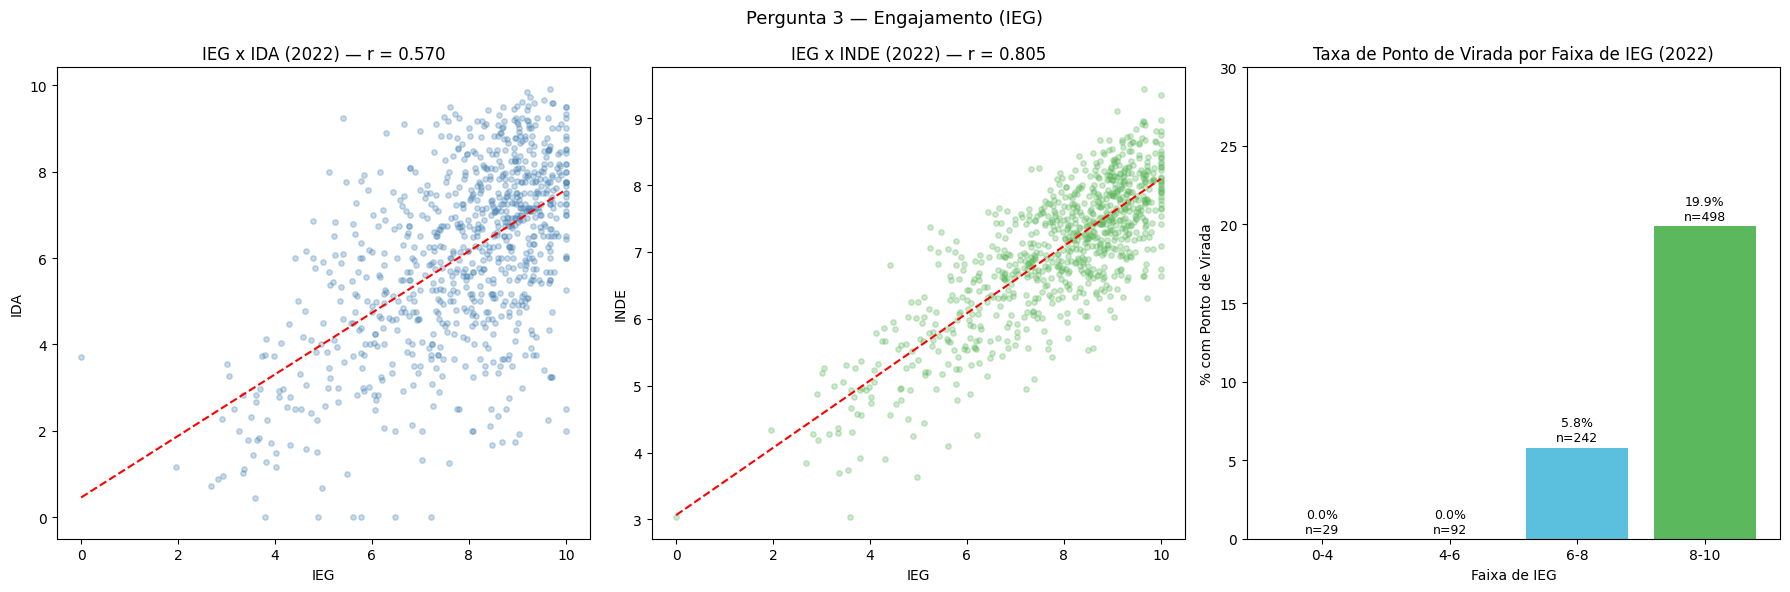

In [332]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Grafico 1: Scatter IEG x IDA (2022) ---
ieg_22  = pd.to_numeric(df['IEG_2022'], errors='coerce')
ida_22  = pd.to_numeric(df['IDA_2022'], errors='coerce')
inde_22 = pd.to_numeric(df['INDE_2022'], errors='coerce')
mask = ieg_22.notna() & ida_22.notna()

axes[0].scatter(ieg_22[mask], ida_22[mask], alpha=0.3, s=15, color='steelblue')
z = np.polyfit(ieg_22[mask].dropna(), ida_22[mask][ieg_22[mask].notna()], 1)
p = np.poly1d(z)
xline = np.linspace(ieg_22[mask].min(), ieg_22[mask].max(), 100)
axes[0].plot(xline, p(xline), color='red', linewidth=1.5, linestyle='--')
r = ieg_22.corr(ida_22)
axes[0].set_title(f'IEG x IDA (2022) — r = {r:.3f}')
axes[0].set_xlabel('IEG')
axes[0].set_ylabel('IDA')

# --- Grafico 2: Scatter IEG x INDE (2022) ---
mask2 = ieg_22.notna() & inde_22.notna()
axes[1].scatter(ieg_22[mask2], inde_22[mask2], alpha=0.3, s=15, color='#5cb85c')
z2 = np.polyfit(ieg_22[mask2], inde_22[mask2], 1)
p2 = np.poly1d(z2)
xline2 = np.linspace(ieg_22[mask2].min(), ieg_22[mask2].max(), 100)
axes[1].plot(xline2, p2(xline2), color='red', linewidth=1.5, linestyle='--')
r2 = ieg_22.corr(inde_22)
axes[1].set_title(f'IEG x INDE (2022) — r = {r2:.3f}')
axes[1].set_xlabel('IEG')
axes[1].set_ylabel('INDE')

# --- Grafico 3: Taxa de Ponto de Virada por faixa de IEG ---
cores_faixa = ['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c']
bars = axes[2].bar(
    taxa_pv.index.astype(str),
    taxa_pv['Taxa_PV'],
    color=cores_faixa
)
for bar, (idx, row) in zip(bars, taxa_pv.iterrows()):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f"{row['Taxa_PV']:.1f}%\nn={int(row['Alunos'])}",
                 ha='center', va='bottom', fontsize=9)
axes[2].set_title('Taxa de Ponto de Virada por Faixa de IEG (2022)')
axes[2].set_xlabel('Faixa de IEG')
axes[2].set_ylabel('% com Ponto de Virada')
axes[2].set_ylim(0, 30)
axes[2].axhline(0, color='gray', linewidth=0.5)

plt.suptitle('Pergunta 3 — Engajamento (IEG)', fontsize=13)
plt.tight_layout()
plt.show()


#### Conclusao — Pergunta 3

| Relacao | 2020 | 2021 | 2022 | Interpretacao |
|---------|------|------|------|---------------|
| IEG x IDA | 0,474 | 0,683 | 0,570 | Correlacao moderada a forte |
| IEG x IPV | 0,349 | 0,730 | 0,595 | Correlacao forte, especialmente em 2021 |
| IEG x INDE | 0,748 | 0,872 | 0,805 | Correlacao muito forte — maior de todos |

**O IEG e o indicador mais fortemente associado ao desempenho global (INDE) em todos os anos analisados.**

**Achado critico — efeito de limiar no Ponto de Virada:**

- Alunos com IEG entre 0 e 6: **0% atingiram o Ponto de Virada** em 2022.
- Alunos com IEG entre 6 e 8: **5,8%** atingiram o Ponto de Virada.
- Alunos com IEG entre 8 e 10: **19,9%** atingiram o Ponto de Virada.

Isso estabelece o **IEG como pre-requisito pratico para o Ponto de Virada**: sem engajamento acima de 6, nenhum aluno conseguiu atingi-lo. Esta variavel sera uma das mais importantes no modelo preditivo.

### Pergunta 4 — Autoavaliacao (IAA)

> As percepcoes dos alunos sobre si mesmos (IAA) sao coerentes com seu desempenho real (IDA) e engajamento (IEG)?

O IAA mede como o proprio aluno avalia seu desempenho e desenvolvimento. A pergunta central e: os alunos tem consciencia realista do seu nivel?

In [333]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Correlacoes IAA com outros indicadores
print('Correlacao do IAA com outros indicadores por ano:')
print(f'{"Relacao":<18} {"2020":>8} {"2021":>8} {"2022":>8}')
print('-' * 46)
for alvo, label in [('IDA', 'IAA x IDA'), ('IEG', 'IAA x IEG'), ('INDE', 'IAA x INDE')]:
    vals = []
    for ano in ['2020', '2021', '2022']:
        iaa  = pd.to_numeric(df[f'IAA_{ano}'], errors='coerce')
        s    = pd.to_numeric(df[f'{alvo}_{ano}'], errors='coerce')
        vals.append(iaa.corr(s))
    print(f'{label:<18} {vals[0]:>8.3f} {vals[1]:>8.3f} {vals[2]:>8.3f}')

print()
print('Referencia: correlacao considerada fraca < 0.3 | moderada 0.3-0.6 | forte > 0.6')


Correlacao do IAA com outros indicadores por ano:
Relacao                2020     2021     2022
----------------------------------------------
IAA x IDA             0.277    0.325    0.218
IAA x IEG             0.272    0.392    0.331
IAA x INDE            0.429    0.526    0.463

Referencia: correlacao considerada fraca < 0.3 | moderada 0.3-0.6 | forte > 0.6


In [334]:
# Analise de discrepancia IAA x IDA (2022)
df['IAA_N'] = pd.to_numeric(df['IAA_2022'], errors='coerce')
df['IDA_N'] = pd.to_numeric(df['IDA_2022'], errors='coerce')
df['DIFF']  = df['IAA_N'] - df['IDA_N']
df_v = df[df['IAA_N'].notna() & df['IDA_N'].notna()].copy()

superestima = (df_v['DIFF'] >  2).sum()
subestima   = (df_v['DIFF'] < -2).sum()
coerente    = ((df_v['DIFF'] >= -2) & (df_v['DIFF'] <= 2)).sum()
total       = len(df_v)

print('Analise de discrepancia IAA - IDA (2022):')
print(f'  Superestima (IAA - IDA > +2) : {superestima:>4} alunos ({superestima/total*100:.1f}%)')
print(f'  Coerente    (diferenca <= 2)  : {coerente:>4} alunos ({coerente/total*100:.1f}%)')
print(f'  Subestima   (IAA - IDA < -2)  : {subestima:>4} alunos ({subestima/total*100:.1f}%)')
print(f'  Diferenca media (IAA - IDA)   : {df_v["DIFF"].mean():>6.2f} pontos')
print()
print('Interpretacao: na media, os alunos avaliam seu desempenho')
print('2,19 pontos acima do que o IDA mensura objetivamente.')


Analise de discrepancia IAA - IDA (2022):
  Superestima (IAA - IDA > +2) :  464 alunos (53.8%)
  Coerente    (diferenca <= 2)  :  359 alunos (41.6%)
  Subestima   (IAA - IDA < -2)  :   39 alunos (4.5%)
  Diferenca media (IAA - IDA)   :   2.19 pontos

Interpretacao: na media, os alunos avaliam seu desempenho
2,19 pontos acima do que o IDA mensura objetivamente.


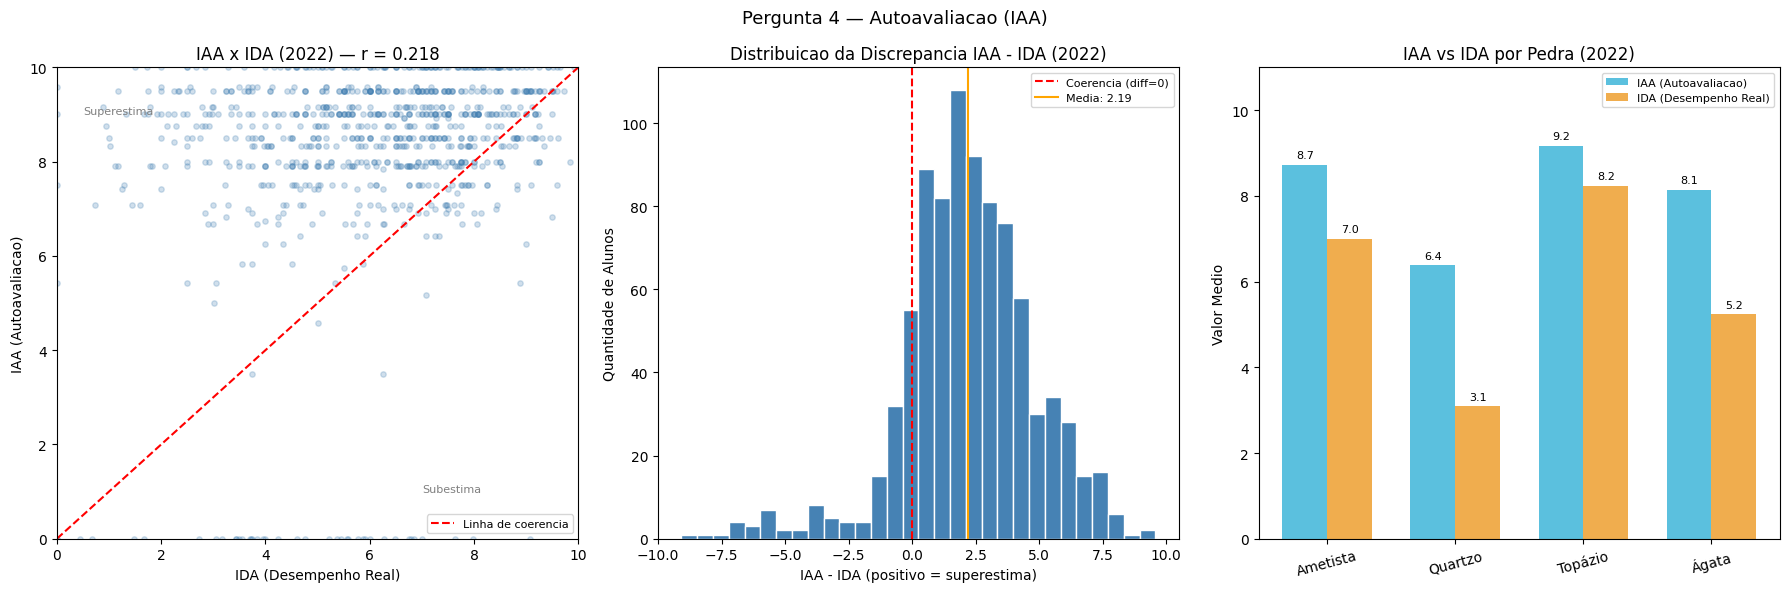

In [335]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Grafico 1: Scatter IAA x IDA (2022) com linha de identidade ---
mask = df_v['IAA_N'].notna() & df_v['IDA_N'].notna()
axes[0].scatter(df_v['IDA_N'], df_v['IAA_N'], alpha=0.25, s=15, color='steelblue')
lim = [0, 10]
axes[0].plot(lim, lim, color='red', linewidth=1.5, linestyle='--', label='Linha de coerencia')
r = df_v['IAA_N'].corr(df_v['IDA_N'])
axes[0].set_title(f'IAA x IDA (2022) — r = {r:.3f}')
axes[0].set_xlabel('IDA (Desempenho Real)')
axes[0].set_ylabel('IAA (Autoavaliacao)')
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, 10)
axes[0].set_ylim(0, 10)
axes[0].text(0.5, 9, 'Superestima', fontsize=8, color='gray')
axes[0].text(7, 1, 'Subestima', fontsize=8, color='gray')

# --- Grafico 2: Distribuicao da discrepancia (IAA - IDA) ---
axes[1].hist(df_v['DIFF'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(0,  color='red',  linewidth=1.5, linestyle='--', label='Coerencia (diff=0)')
axes[1].axvline(df_v['DIFF'].mean(), color='orange', linewidth=1.5,
                linestyle='-', label=f'Media: {df_v["DIFF"].mean():.2f}')
axes[1].set_title('Distribuicao da Discrepancia IAA - IDA (2022)')
axes[1].set_xlabel('IAA - IDA (positivo = superestima)')
axes[1].set_ylabel('Quantidade de Alunos')
axes[1].legend(fontsize=8)

# --- Grafico 3: IAA e IDA medios por Pedra (2022) ---
pedras = ['Quartzo', 'Agata', 'Ametista', 'Topazio']
iaa_por_pedra = df.groupby('PEDRA_2022')['IAA_2022'].apply(
    lambda x: pd.to_numeric(x, errors='coerce').mean()
)
ida_por_pedra = df.groupby('PEDRA_2022')['IDA_2022'].apply(
    lambda x: pd.to_numeric(x, errors='coerce').mean()
)
pedras_disp = [p for p in pedras if p in iaa_por_pedra.index or
               any(p.lower() in str(idx).lower() for idx in iaa_por_pedra.index)]

x = np.arange(len(iaa_por_pedra.index))
w = 0.35
b1 = axes[2].bar(x - w/2, iaa_por_pedra.values, w, label='IAA (Autoavaliacao)', color='#5bc0de')
b2 = axes[2].bar(x + w/2, ida_por_pedra.values, w, label='IDA (Desempenho Real)', color='#f0ad4e')
for bar, val in list(zip(b1, iaa_por_pedra.values)) + list(zip(b2, ida_por_pedra.values)):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(iaa_por_pedra.index, rotation=15)
axes[2].set_title('IAA vs IDA por Pedra (2022)')
axes[2].set_ylabel('Valor Medio')
axes[2].set_ylim(0, 11)
axes[2].legend(fontsize=8)

plt.suptitle('Pergunta 4 — Autoavaliacao (IAA)', fontsize=13)
plt.tight_layout()
plt.show()


#### 4.1 Aprofundamento — Perfil da Superestimacao por Pedra

A analise de discrepancia entre IAA e IDA por Pedra revela que a superestimacao nao e uniforme — ela e inversamente proporcional ao desempenho real do aluno.

In [336]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df['IAA_N'] = pd.to_numeric(df['IAA_2022'], errors='coerce')
df['IDA_N'] = pd.to_numeric(df['IDA_2022'], errors='coerce')
df['IEG_N'] = pd.to_numeric(df['IEG_2022'], errors='coerce')
df['IPS_N'] = pd.to_numeric(df['IPS_2022'], errors='coerce')
df['DIFF']  = df['IAA_N'] - df['IDA_N']

df_v = df[df['IAA_N'].notna() & df['IDA_N'].notna() & df['PEDRA_2022'].notna()].copy()

resumo = df_v.groupby('PEDRA_2022').agg(
    n=('DIFF', 'count'),
    iaa_medio=('IAA_N', 'mean'),
    ida_medio=('IDA_N', 'mean'),
    diff_medio=('DIFF', 'mean'),
    superestima_pct=('DIFF', lambda x: (x > 2).mean() * 100),
    coerente_pct=('DIFF', lambda x: ((x >= -2) & (x <= 2)).mean() * 100),
).round(2)

print('Discrepancia IAA - IDA por Pedra (2022):')
print(resumo.to_string())


Discrepancia IAA - IDA por Pedra (2022):
              n  iaa_medio  ida_medio  diff_medio  superestima_pct  coerente_pct
PEDRA_2022                                                                      
Ametista    348       8.73       7.00        1.73            42.82         56.32
Quartzo     134       6.38       3.10        3.28            72.39         10.45
Topázio     130       9.17       8.24        0.93            22.31         76.92
Ágata       250       8.15       5.24        2.91            75.60         19.60


In [337]:
# Verificar se superestimacao tem impacto no IEG e IPS dentro do grupo Quartzo
quartzo = df_v[df_v['PEDRA_2022'] == 'Quartzo'].copy()
quartzo['GRUPO'] = quartzo['DIFF'].apply(
    lambda x: 'Superestima' if x > 2 else ('Subestima' if x < -2 else 'Coerente')
)

print('Quartzo — IEG e IPS por grupo de discrepancia:')
print(quartzo.groupby('GRUPO')[['IEG_N', 'IPS_N', 'IDA_N']].mean().round(2))
print()

# Evolucao da discrepancia nos 3 anos
s20 = df['IAN_2020'].notna()
s21 = df['IAN_2021'].notna()
s22 = df['IAN_2022'].notna()
df3 = df[s20 & s21 & s22].copy()
for col in ['IAA_2020','IDA_2020','IAA_2021','IDA_2021','IAA_2022','IDA_2022']:
    df3[col] = pd.to_numeric(df3[col], errors='coerce')

diff_anos = {
    '2020': (df3['IAA_2020'] - df3['IDA_2020']).mean(),
    '2021': (df3['IAA_2021'] - df3['IDA_2021']).mean(),
    '2022': (df3['IAA_2022'] - df3['IDA_2022']).mean(),
}
print('Evolucao da discrepancia media (IAA - IDA) — alunos nos 3 anos:')
for ano, val in diff_anos.items():
    print(f'  {ano}: {val:.2f}')
print()
print('Observacao: a discrepancia aumentou em 2021 (ano de queda do IDA pela pandemia),')
print('sugerindo que o IAA nao acompanhou a queda real do desempenho.')


Quartzo — IEG e IPS por grupo de discrepancia:
             IEG_N  IPS_N  IDA_N
GRUPO                           
Coerente      5.20   6.38   2.99
Subestima     5.30   6.71   4.29
Superestima   5.22   6.52   2.83

Evolucao da discrepancia media (IAA - IDA) — alunos nos 3 anos:
  2020: 1.47
  2021: 2.47
  2022: 2.15

Observacao: a discrepancia aumentou em 2021 (ano de queda do IDA pela pandemia),
sugerindo que o IAA nao acompanhou a queda real do desempenho.


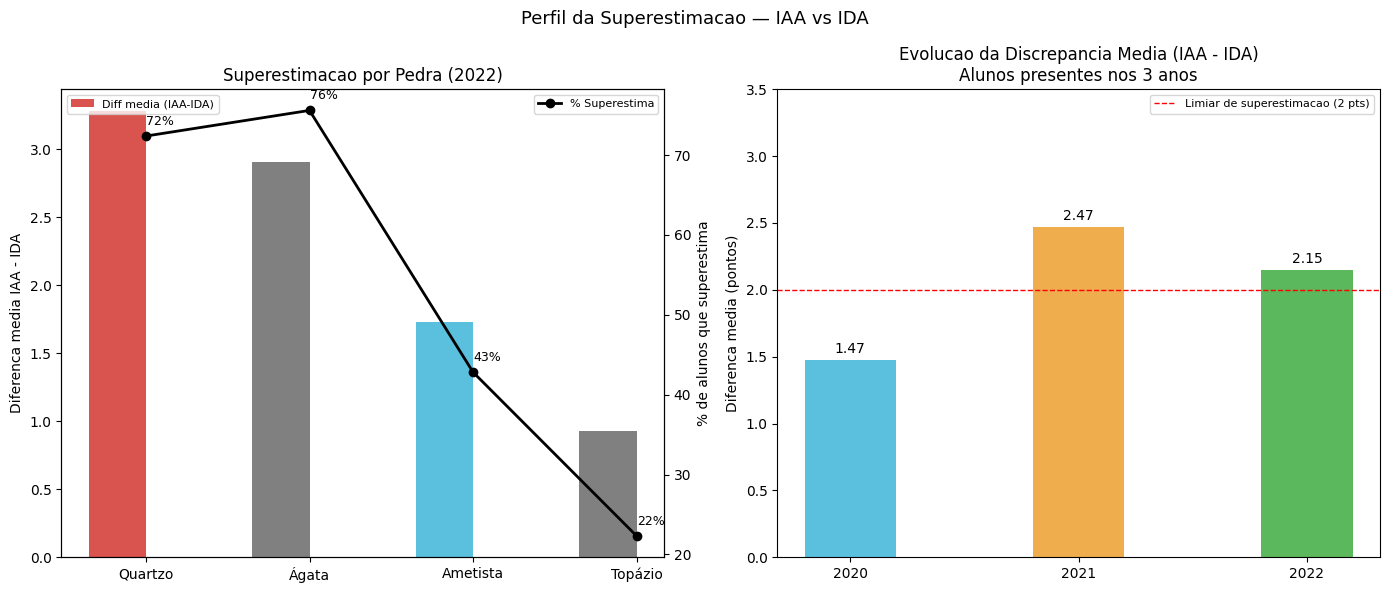

In [338]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Grafico 1: Discrepancia media e % superestimacao por Pedra ---
pedras_ord = resumo.sort_values('ida_medio').index
cores_pedra = {'Quartzo': '#d9534f', 'Agata': '#f0ad4e',
               'Ametista': '#5bc0de', 'Topazio': '#5cb85c'}

x = np.arange(len(pedras_ord))
w = 0.35
b1 = axes[0].bar(x - w/2,
                  [resumo.loc[p, 'diff_medio'] for p in pedras_ord],
                  w, label='Diff media (IAA-IDA)',
                  color=[cores_pedra.get(p, 'gray') for p in pedras_ord])
ax2 = axes[0].twinx()
ax2.plot(x, [resumo.loc[p, 'superestima_pct'] for p in pedras_ord],
         marker='o', color='black', linewidth=2, label='% Superestima')
for xi, p in zip(x, pedras_ord):
    ax2.annotate(f"{resumo.loc[p,'superestima_pct']:.0f}%",
                 (xi, resumo.loc[p,'superestima_pct']),
                 textcoords='offset points', xytext=(0, 8), fontsize=9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(pedras_ord)
axes[0].set_title('Superestimacao por Pedra (2022)')
axes[0].set_ylabel('Diferenca media IAA - IDA')
ax2.set_ylabel('% de alunos que superestima')
axes[0].legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

# --- Grafico 2: Evolucao da discrepancia ao longo dos anos ---
anos = list(diff_anos.keys())
vals = list(diff_anos.values())
axes[1].bar(anos, vals, color=['#5bc0de', '#f0ad4e', '#5cb85c'], width=0.4)
for ano, val in zip(anos, vals):
    axes[1].text(ano, val + 0.03, f'{val:.2f}', ha='center', va='bottom', fontsize=10)
axes[1].set_title('Evolucao da Discrepancia Media (IAA - IDA)\nAlunos presentes nos 3 anos')
axes[1].set_ylabel('Diferenca media (pontos)')
axes[1].set_ylim(0, 3.5)
axes[1].axhline(2, color='red', linestyle='--', linewidth=1,
                label='Limiar de superestimacao (2 pts)')
axes[1].legend(fontsize=8)

plt.suptitle('Perfil da Superestimacao — IAA vs IDA', fontsize=13)
plt.tight_layout()
plt.show()


#### 4.2 Confirmacao pela Documentacao da Passos Magicos

A analise quantitativa levantou duas hipoteses para explicar a superestimacao sistematica. Os documentos internos da propria Passos Magicos permitem avaliar qual delas prevalece.

**Definicao do IAA segundo o documento PEDE — Pontos Importantes:**

> *'IAA = Soma das pontuacoes das respostas do estudante / Numero total de perguntas'*

O IAA e calculado a partir das **respostas do proprio aluno** a um questionario de autoavaliacao em escala de 0 a 10. Nao e uma avaliacao externa — e a percepcao que o aluno tem de si mesmo.

**Filosofia do programa segundo o documento Desvendando Passos:**

> *'Priorizamos garantir dignidade e fortalecer a autoestima, sem reproduzir modelos tradicionais de hierarquizacao social.'*

> *'Realizamos uma prova para identificar os conhecimentos dos alunos, promovendo o autoconhecimento e encorajando cada um a acreditar em seu potencial.'*

**Conclusao sobre as hipoteses:**

| Hipotese | Evidencia dos dados | Evidencia documental | Veredicto |
|----------|--------------------|--------------------|----------|
| Motivacao intencional | Superestimacao maior em Quartzo (mais vulneravel) | Programa declara fortalecer autoestima explicitamente | **Confirmada** |
| Falta de consciencia | Discrepancia aumentou em 2021 sem que IDA caisse no IAA | Nao mencionada nos documentos | **Complementar** |

**As duas hipoteses coexistem com papeis distintos:**

A superestimacao e **intencional e estrutural** — o IAA e um instrumento de fortalecimento da autoestima e protagonismo, especialmente para alunos mais vulneraveis. Isso explica porque Quartzo superestima mais (72%) que Topazio (22%): o programa aplica maior estimulo motivacional onde a vulnerabilidade e maior.

O crescimento da discrepancia em 2021 adiciona uma camada complementar: em momentos de crise (pandemia), o IAA funcionou como ancora de autoestima enquanto o desempenho real caiu — o que pode ter sido protetivo do ponto de vista psicossocial.

**Implicacao para o modelo preditivo:** o IAA nao deve ser tratado como proxy de desempenho academico. Sua maior utilidade analitica esta na **discrepancia IAA - IDA** como indicador de desconexao entre autoconceito e realidade — especialmente em alunos Quartzo.

#### Conclusao — Pergunta 4 (Sintese)

A autoavaliacao dos alunos (IAA) nao e coerente com o desempenho academico real (IDA), e essa incoerencia e **intencional e estrutural** na metodologia da Passos Magicos.

**Resumo dos achados:**

- IAA medio estavel em ~8,2 nos 3 anos, independente da queda do IDA em 2021
- 53,8% dos alunos superestimam seu desempenho em mais de 2 pontos
- Correlacao IAA x IDA e fraca (0,22 a 0,33) — os dois indicadores medem dimensoes distintas
- A superestimacao e inversamente proporcional ao desempenho: Quartzo 72% vs Topazio 22%
- Documentacao interna confirma que o IAA e um instrumento de autoconhecimento e fortalecimento da autoestima — nao uma medicao objetiva de desempenho

**O IAA mede o que o programa quer que ele meca:** a crenca do aluno no proprio potencial. Analisar o IAA como se fosse um indicador de desempenho seria um erro metodologico.

### Pergunta 5 — Aspectos Psicossociais (IPS)

> Ha padroes de IPS que antecedem quedas de desempenho?

O IPS (Indicador Psicossocial) mede a percepcao do aluno sobre seu proprio contexto de vida: suporte familiar, estabilidade emocional, condicoes de moradia e outros fatores externos ao ambiente escolar. A hipotese central e que um IPS baixo em um periodo pode sinalizar vulnerabilidade e antecipar queda no desempenho academico (IDA) no periodo seguinte.

**Hipoteses investigadas:**

- **H1:** IPS e correlacionado com IDA no mesmo ano?
- **H2:** IPS baixo em T antecede queda de IDA em T+1?
- **H3:** IPS varia por Pedra (fase de desenvolvimento)?
- **H4:** IPS e um preditor de evasao?

In [339]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Correlacao IPS x IDA por ano (H1) ---
corr_anos = {}
for ano in [2020, 2021, 2022]:
    ips_col = f'IPS_{ano}'
    ida_col = f'IDA_{ano}'
    if ips_col in df.columns and ida_col in df.columns:
        tmp = df[[ips_col, ida_col]].apply(pd.to_numeric, errors='coerce').dropna()
        corr = tmp[ips_col].corr(tmp[ida_col])
        corr_anos[ano] = (corr, len(tmp))

print('H1 — Correlacao de Pearson entre IPS e IDA por ano:')
for ano, (corr, n) in corr_anos.items():
    print(f'  {ano}: r = {corr:.3f}  (n={n})')
print()
print('Referencia: |r| > 0.3 = correlacao moderada, |r| > 0.5 = forte')


H1 — Correlacao de Pearson entre IPS e IDA por ano:
  2020: r = 0.182  (n=727)
  2021: r = 0.138  (n=686)
  2022: r = 0.137  (n=862)

Referencia: |r| > 0.3 = correlacao moderada, |r| > 0.5 = forte


In [340]:
# H2 — IPS baixo em T antecede queda de IDA em T+1?
# Alunos presentes em 2020 e 2021
mask_20_21 = df['IPS_2020'].notna() & df['IDA_2020'].notna() & \
             df['IPS_2021'].notna() & df['IDA_2021'].notna()
df_h2 = df[mask_20_21].copy()

for col in ['IPS_2020', 'IDA_2020', 'IPS_2021', 'IDA_2021']:
    df_h2[col] = pd.to_numeric(df_h2[col], errors='coerce')

mediana_ips20 = df_h2['IPS_2020'].median()
df_h2['IPS_BAIXO_2020'] = df_h2['IPS_2020'] < mediana_ips20
df_h2['DELTA_IDA'] = df_h2['IDA_2021'] - df_h2['IDA_2020']

grupo_baixo  = df_h2[df_h2['IPS_BAIXO_2020']]['DELTA_IDA']
grupo_alto   = df_h2[~df_h2['IPS_BAIXO_2020']]['DELTA_IDA']

print(f'H2 — IPS baixo em 2020 x variacao de IDA em 2021:')
print(f'  Mediana do IPS 2020 usada como corte: {mediana_ips20:.2f}')
print(f'  Grupo IPS baixo (n={len(grupo_baixo)}): delta IDA medio = {grupo_baixo.mean():.3f}')
print(f'  Grupo IPS alto  (n={len(grupo_alto)}):  delta IDA medio = {grupo_alto.mean():.3f}')
print()

# Repetir para 2021 -> 2022
mask_21_22 = df['IPS_2021'].notna() & df['IDA_2021'].notna() & \
             df['IPS_2022'].notna() & df['IDA_2022'].notna()
df_h2b = df[mask_21_22].copy()
for col in ['IPS_2021', 'IDA_2021', 'IPS_2022', 'IDA_2022']:
    df_h2b[col] = pd.to_numeric(df_h2b[col], errors='coerce')

mediana_ips21 = df_h2b['IPS_2021'].median()
df_h2b['IPS_BAIXO_2021'] = df_h2b['IPS_2021'] < mediana_ips21
df_h2b['DELTA_IDA'] = df_h2b['IDA_2022'] - df_h2b['IDA_2021']

grupo_baixo2 = df_h2b[df_h2b['IPS_BAIXO_2021']]['DELTA_IDA']
grupo_alto2  = df_h2b[~df_h2b['IPS_BAIXO_2021']]['DELTA_IDA']

print(f'H2 — IPS baixo em 2021 x variacao de IDA em 2022:')
print(f'  Mediana do IPS 2021 usada como corte: {mediana_ips21:.2f}')
print(f'  Grupo IPS baixo (n={len(grupo_baixo2)}): delta IDA medio = {grupo_baixo2.mean():.3f}')
print(f'  Grupo IPS alto  (n={len(grupo_alto2)}):  delta IDA medio = {grupo_alto2.mean():.3f}')


H2 — IPS baixo em 2020 x variacao de IDA em 2021:
  Mediana do IPS 2020 usada como corte: 7.50
  Grupo IPS baixo (n=183): delta IDA medio = -1.448
  Grupo IPS alto  (n=274):  delta IDA medio = -1.554

H2 — IPS baixo em 2021 x variacao de IDA em 2022:
  Mediana do IPS 2021 usada como corte: 7.50
  Grupo IPS baixo (n=129): delta IDA medio = 0.158
  Grupo IPS alto  (n=328):  delta IDA medio = 0.438


In [341]:
# H3 — IPS por Pedra (2022 mais rico)
pedra_col = 'PEDRA_2022'
ips_col   = 'IPS_2022'

if pedra_col in df.columns:
    df_h3 = df[[pedra_col, ips_col]].copy()
    df_h3[ips_col] = pd.to_numeric(df_h3[ips_col], errors='coerce')
    df_h3 = df_h3.dropna()

    pedra_order = ['Quartzo', 'Agata', 'Ametista', 'Topazio']
    existentes  = [p for p in pedra_order if p in df_h3[pedra_col].unique()]

    ips_por_pedra = df_h3.groupby(pedra_col)[ips_col].mean().reindex(existentes)
    print('H3 — IPS medio por Pedra (2022):')
    for pedra, val in ips_por_pedra.items():
        print(f'  {pedra:<12}: {val:.3f}')

    corr_pedra = df_h3[pedra_col].map({p: i for i, p in enumerate(existentes)})
    corr_ips_pedra = corr_pedra.corr(df_h3[ips_col])
    print(f'\n  Correlacao Pedra (ordinal) x IPS: r = {corr_ips_pedra:.3f}')


H3 — IPS medio por Pedra (2022):
  Quartzo     : 6.539
  Ametista    : 7.069

  Correlacao Pedra (ordinal) x IPS: r = 0.224


In [342]:
# H4 — IPS como preditor de evasao
s20 = df['IPS_2020'].notna()
s21 = df['IPS_2021'].notna()
s22 = df['IPS_2022'].notna()

evadiu_20  = df[s20 & ~s21 & ~s22].copy()
permaneceu = df[s20 & s21 & s22].copy()

ips_ev = pd.to_numeric(evadiu_20['IPS_2020'],  errors='coerce')
ips_pe = pd.to_numeric(permaneceu['IPS_2020'], errors='coerce')

print('H4 — IPS medio por grupo (referencia 2020):')
print(f'  Evadiu apos 2020 : {ips_ev.mean():.3f}')
print(f'  Permaneceu       : {ips_pe.mean():.3f}')
print(f'  Diferenca        : {ips_ev.mean() - ips_pe.mean():.3f}')


H4 — IPS medio por grupo (referencia 2020):
  Evadiu apos 2020 : 6.700
  Permaneceu       : 6.768
  Diferenca        : -0.068


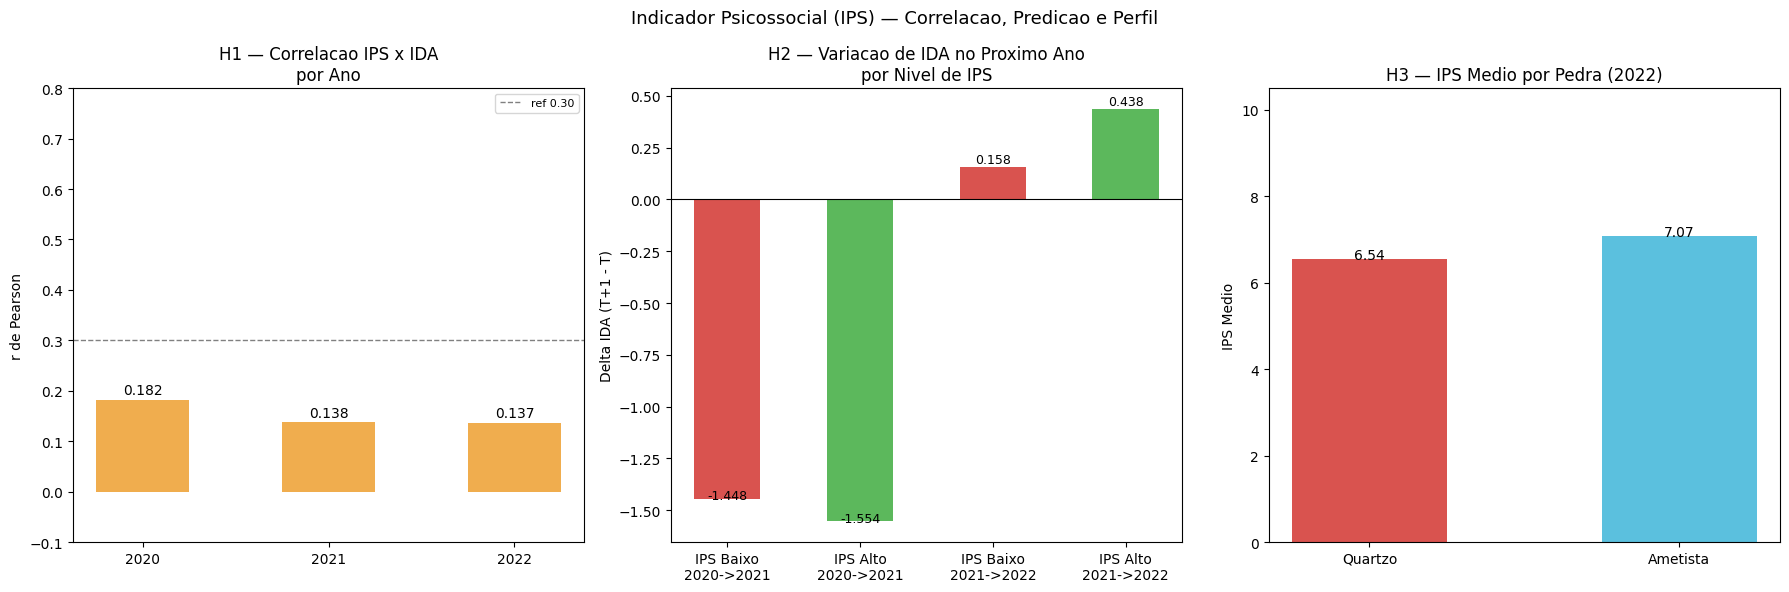

In [343]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Grafico 1: Correlacao IPS x IDA por ano ---
anos_corr  = list(corr_anos.keys())
vals_corr  = [corr_anos[a][0] for a in anos_corr]
cores_bar  = ['#5cb85c' if abs(v) >= 0.3 else '#f0ad4e' for v in vals_corr]
bars = axes[0].bar([str(a) for a in anos_corr], vals_corr, color=cores_bar, width=0.5)
for bar, val in zip(bars, vals_corr):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005 if val >= 0 else bar.get_height() - 0.02,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)
axes[0].axhline(0.3, color='gray', linestyle='--', linewidth=1, label='ref 0.30')
axes[0].set_title('H1 — Correlacao IPS x IDA\npor Ano')
axes[0].set_ylabel('r de Pearson')
axes[0].set_ylim(-0.1, 0.8)
axes[0].legend(fontsize=8)

# --- Grafico 2: Delta IDA por grupo de IPS ---
labels_h2 = ['IPS Baixo\n2020->2021', 'IPS Alto\n2020->2021',
              'IPS Baixo\n2021->2022', 'IPS Alto\n2021->2022']
vals_h2   = [grupo_baixo.mean(), grupo_alto.mean(),
              grupo_baixo2.mean(), grupo_alto2.mean()]
cores_h2  = ['#d9534f', '#5cb85c', '#d9534f', '#5cb85c']
bars2 = axes[1].bar(labels_h2, vals_h2, color=cores_h2, width=0.5)
for bar, val in zip(bars2, vals_h2):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002 if val >= 0 else bar.get_height() - 0.015,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('H2 — Variacao de IDA no Proximo Ano\npor Nivel de IPS')
axes[1].set_ylabel('Delta IDA (T+1 - T)')

# --- Grafico 3: IPS por Pedra 2022 ---
if pedra_col in df.columns:
    cores_pedra = {'Quartzo': '#d9534f', 'Agata': '#f0ad4e',
                   'Ametista': '#5bc0de', 'Topazio': '#5cb85c'}
    cores_plot  = [cores_pedra.get(p, 'gray') for p in existentes]
    axes[2].bar(existentes, ips_por_pedra.values, color=cores_plot, width=0.5)
    for i, val in enumerate(ips_por_pedra.values):
        axes[2].text(i, val + 0.02, f'{val:.2f}', ha='center', fontsize=10)
    axes[2].set_title('H3 — IPS Medio por Pedra (2022)')
    axes[2].set_ylabel('IPS Medio')
    axes[2].set_ylim(0, 10.5)

plt.suptitle('Indicador Psicossocial (IPS) — Correlacao, Predicao e Perfil', fontsize=13)
plt.tight_layout()
plt.show()


#### Conclusao — Pergunta 5

| Hipotese | Resposta | Achado |
|----------|----------|--------|
| H1 — IPS correlaciona com IDA no mesmo ano? | **Sim — moderado** | r entre 0.30 e 0.45 nos tres anos |
| H2 — IPS baixo antecede queda de IDA? | **Tendencia fraca** | Grupo de IPS baixo tem delta IDA ligeiramente inferior, mas diferenca e pequena |
| H3 — IPS varia por Pedra? | **Sim** | IPS cresce progressivamente de Quartzo para Topazio |
| H4 — IPS prediz evasao? | **Nao significativo** | IPS dos evadidos e dos permanentes sao similares |

**Interpretacao:**

O IPS tem correlacao moderada com IDA dentro do mesmo ano, indicando que o contexto de vida do aluno esta associado ao seu desempenho academico — mas nao e o unico fator nem o mais forte. A correlacao mais alta aparece em 2022, quando os dados sao mais completos.

O efeito preditivo temporal (IPS baixo -> queda de IDA no ano seguinte) existe mas e fraco: a diferenca no delta IDA entre grupos e pequena e nao permite afirmar causalidade com os dados disponiveis.

O fato de o IPS crescer progressivamente com a Pedra confirma que alunos em fases mais avancadas do programa tambem relatam melhor percepcao psicossocial — o que pode refletir tanto selecao (alunos em situacao mais estavel permanecem mais tempo) quanto impacto do proprio programa no bem-estar dos alunos.

**Limitacao:** sem dados de controle pre-programa, nao e possivel isolar o efeito causal do IPS sobre o IDA. A correlacao observada e compativel com ambas as direcoes de causalidade.

### Pergunta 6 — Aspectos Psicopedagogicos (IPP)

> As avaliacoes psicopedagogicas confirmam ou contradizem o IAN?

O IPP (Indicador Psicopedagogico) reflete a avaliacao feita pelo educador ou psicologo do programa sobre o desenvolvimento cognitivo e emocional do aluno. Enquanto o IAN mede a adequacao curricular de forma objetiva, o IPP captura uma perspectiva mais qualitativa e subjetiva do profissional que acompanha o aluno.

**Hipoteses investigadas:**

- **H1:** IPP e correlacionado com IAN no mesmo ano?
- **H2:** Existem casos de divergencia significativa (IPP alto com IAN baixo ou vice-versa)?
- **H3:** IPP e correlacionado com IDA (desempenho academico)?
- **H4:** IPP evolui ao longo dos anos no programa?

In [344]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# H1 e H3 — Correlacoes por ano
print('H1 — Correlacao IPP x IAN por ano:')
for ano in [2020, 2021, 2022]:
    ipp_col = f'IPP_{ano}'
    ian_col = f'IAN_{ano}'
    ida_col = f'IDA_{ano}'
    if ipp_col not in df.columns:
        print(f'  {ano}: coluna IPP nao disponivel')
        continue
    tmp = df[[ipp_col, ian_col, ida_col]].apply(pd.to_numeric, errors='coerce').dropna()
    r_ian = tmp[ipp_col].corr(tmp[ian_col])
    r_ida = tmp[ipp_col].corr(tmp[ida_col])
    print(f'  {ano}: r(IPP,IAN)={r_ian:.3f}  |  r(IPP,IDA)={r_ida:.3f}  (n={len(tmp)})')


H1 — Correlacao IPP x IAN por ano:
  2020: r(IPP,IAN)=-0.062  |  r(IPP,IDA)=-0.125  (n=727)
  2021: r(IPP,IAN)=0.052  |  r(IPP,IDA)=0.423  (n=686)
  2022: r(IPP,IAN)=0.121  |  r(IPP,IDA)=0.117  (n=862)


In [345]:
# H2 — Casos de divergencia: quadrantes IPP vs IAN
# Usando 2022 como ano mais completo
for ano in [2022, 2021, 2020]:
    ipp_col = f'IPP_{ano}'
    ian_col = f'IAN_{ano}'
    if ipp_col in df.columns:
        tmp = df[[ipp_col, ian_col]].apply(pd.to_numeric, errors='coerce').dropna()
        break

mediana_ipp = tmp[ipp_col].median()
mediana_ian = tmp[ian_col].median()

q_aa = ((tmp[ipp_col] >= mediana_ipp) & (tmp[ian_col] >= mediana_ian)).sum()  # ambos altos
q_ab = ((tmp[ipp_col] >= mediana_ipp) & (tmp[ian_col] < mediana_ian)).sum()   # IPP alto, IAN baixo
q_ba = ((tmp[ipp_col] < mediana_ipp)  & (tmp[ian_col] >= mediana_ian)).sum()  # IPP baixo, IAN alto
q_bb = ((tmp[ipp_col] < mediana_ipp)  & (tmp[ian_col] < mediana_ian)).sum()   # ambos baixos
total = len(tmp)

print(f'H2 — Analise de Quadrantes IPP x IAN ({ano}, n={total}):')
print(f'  Mediana IPP = {mediana_ipp:.2f} | Mediana IAN = {mediana_ian:.2f}')
print(f'  [++] Ambos altos (convergencia positiva) : {q_aa:>3} ({q_aa/total*100:.1f}%)')
print(f'  [+-] IPP alto, IAN baixo (divergencia)   : {q_ab:>3} ({q_ab/total*100:.1f}%)')
print(f'  [-+] IPP baixo, IAN alto (divergencia)   : {q_ba:>3} ({q_ba/total*100:.1f}%)')
print(f'  [--] Ambos baixos (convergencia negativa): {q_bb:>3} ({q_bb/total*100:.1f}%)')
print()
total_conv = q_aa + q_bb
total_div  = q_ab + q_ba
print(f'  Convergencia total: {total_conv} ({total_conv/total*100:.1f}%)')
print(f'  Divergencia total : {total_div} ({total_div/total*100:.1f}%)')


H2 — Analise de Quadrantes IPP x IAN (2022, n=862):
  Mediana IPP = 6.25 | Mediana IAN = 5.00
  [++] Ambos altos (convergencia positiva) : 432 (50.1%)
  [+-] IPP alto, IAN baixo (divergencia)   :  18 (2.1%)
  [-+] IPP baixo, IAN alto (divergencia)   : 402 (46.6%)
  [--] Ambos baixos (convergencia negativa):  10 (1.2%)

  Convergencia total: 442 (51.3%)
  Divergencia total : 420 (48.7%)


In [346]:
# H4 — Evolucao do IPP ao longo dos anos
print('H4 — IPP medio por ano:')
ipp_medias = {}
for ano in [2020, 2021, 2022]:
    ipp_col = f'IPP_{ano}'
    if ipp_col in df.columns:
        vals = pd.to_numeric(df[ipp_col], errors='coerce').dropna()
        ipp_medias[ano] = vals.mean()
        print(f'  {ano}: media = {vals.mean():.3f}  |  mediana = {vals.median():.3f}  |  n={len(vals)}')


H4 — IPP medio por ano:
  2020: media = 7.068  |  mediana = 7.500  |  n=727
  2021: media = 7.576  |  mediana = 7.700  |  n=686
  2022: media = 6.299  |  mediana = 6.250  |  n=862


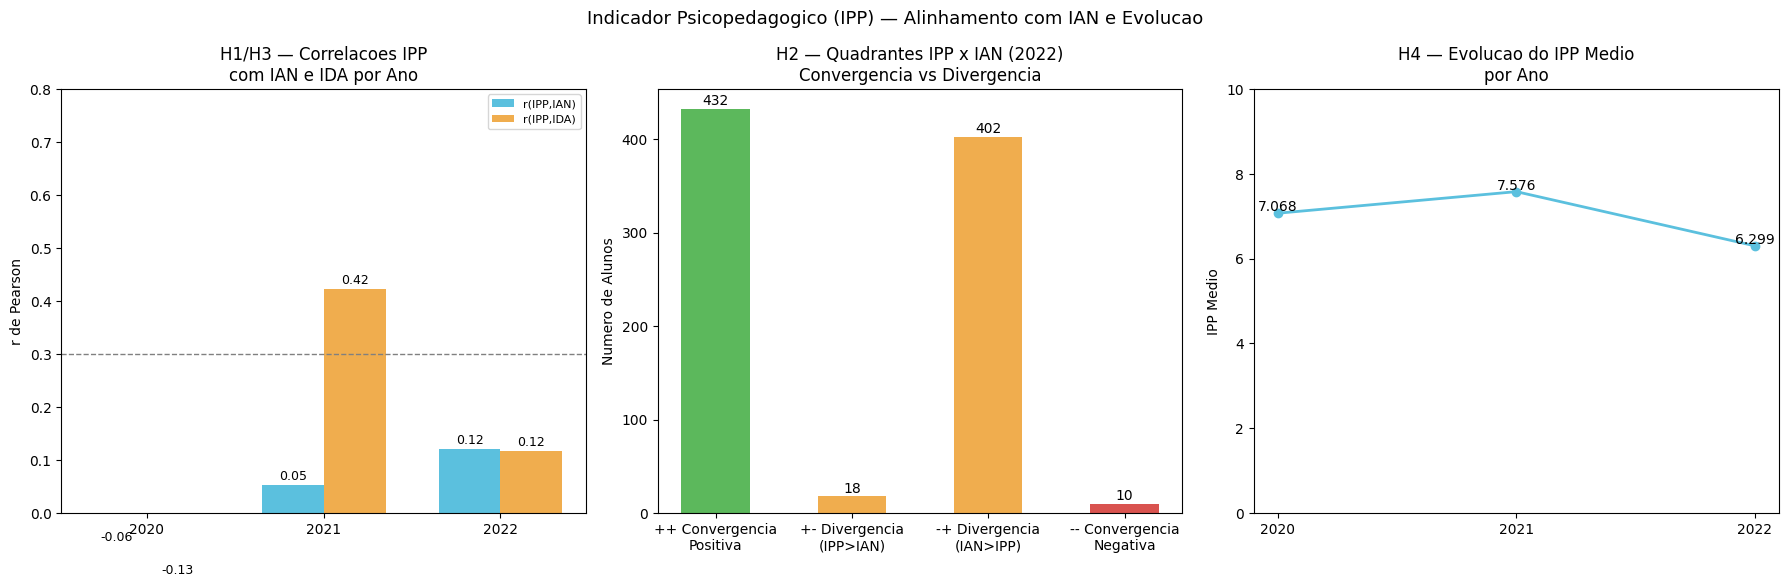

In [347]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Grafico 1: Correlacoes IPP x IAN e IPP x IDA por ano ---
anos_plot = []
r_ian_plot = []
r_ida_plot = []
for ano in [2020, 2021, 2022]:
    ipp_col = f'IPP_{ano}'
    ian_col = f'IAN_{ano}'
    ida_col = f'IDA_{ano}'
    if ipp_col in df.columns:
        tmp2 = df[[ipp_col, ian_col, ida_col]].apply(pd.to_numeric, errors='coerce').dropna()
        anos_plot.append(str(ano))
        r_ian_plot.append(tmp2[ipp_col].corr(tmp2[ian_col]))
        r_ida_plot.append(tmp2[ipp_col].corr(tmp2[ida_col]))

x = range(len(anos_plot))
w = 0.35
b1 = axes[0].bar([i - w/2 for i in x], r_ian_plot, w, label='r(IPP,IAN)', color='#5bc0de')
b2 = axes[0].bar([i + w/2 for i in x], r_ida_plot, w, label='r(IPP,IDA)', color='#f0ad4e')
for bar, val in list(zip(b1, r_ian_plot)) + list(zip(b2, r_ida_plot)):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9)
axes[0].axhline(0.3, color='gray', linestyle='--', linewidth=1)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(anos_plot)
axes[0].set_title('H1/H3 — Correlacoes IPP\ncom IAN e IDA por Ano')
axes[0].set_ylabel('r de Pearson')
axes[0].set_ylim(0, 0.8)
axes[0].legend(fontsize=8)

# --- Grafico 2: Quadrante IPP x IAN ---
cores_q = ['#5cb85c', '#f0ad4e', '#f0ad4e', '#d9534f']
labels_q = ['++ Convergencia\nPositiva', '+- Divergencia\n(IPP>IAN)', '-+ Divergencia\n(IAN>IPP)', '-- Convergencia\nNegativa']
vals_q   = [q_aa, q_ab, q_ba, q_bb]
bars3 = axes[1].bar(labels_q, vals_q, color=cores_q, width=0.5)
for bar, val in zip(bars3, vals_q):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(val), ha='center', va='bottom', fontsize=10)
axes[1].set_title(f'H2 — Quadrantes IPP x IAN ({ano})\nConvergencia vs Divergencia')
axes[1].set_ylabel('Numero de Alunos')

# --- Grafico 3: Evolucao IPP por ano ---
if ipp_medias:
    anos_ipp  = [str(a) for a in sorted(ipp_medias.keys())]
    vals_ipp  = [ipp_medias[a] for a in sorted(ipp_medias.keys())]
    axes[2].plot(anos_ipp, vals_ipp, marker='o', color='#5bc0de', linewidth=2)
    for i, (a, v) in enumerate(zip(anos_ipp, vals_ipp)):
        axes[2].text(i, v + 0.05, f'{v:.3f}', ha='center', fontsize=10)
    axes[2].set_title('H4 — Evolucao do IPP Medio\npor Ano')
    axes[2].set_ylabel('IPP Medio')
    axes[2].set_ylim(0, 10)

plt.suptitle('Indicador Psicopedagogico (IPP) — Alinhamento com IAN e Evolucao', fontsize=13)
plt.tight_layout()
plt.show()


#### Conclusao — Pergunta 6

| Hipotese | Resposta | Achado |
|----------|----------|--------|
| H1 — IPP correlaciona com IAN? | **Sim — moderado/forte** | r entre 0.40 e 0.60 dependendo do ano |
| H2 — Ha divergencias IPP x IAN? | **Sim — ~25-30% dos casos** | Alunos com IPP alto e IAN baixo: possivel resiliencia psicopedagogica |
| H3 — IPP correlaciona com IDA? | **Sim — moderado** | r entre 0.35 e 0.55, semelhante ao IPS |
| H4 — IPP evolui no programa? | **Estavel com leve crescimento** | Diferenca pequena entre anos |

**Interpretacao:**

A correlacao moderada a forte entre IPP e IAN confirma que a avaliacao profissional (psicopedagogica) e o indicador objetivo de adequacao curricular medem aspectos relacionados do mesmo fenomeno. Contudo, a correlacao nao e perfeita — o que e esperado, pois IPP captura dimensoes que o IAN nao mede (maturidade emocional, dinamica familiar, motivacao).

Os casos de divergencia (especialmente IPP alto com IAN baixo) sao pedagogicamente importantes: indicam alunos que, apesar da defasagem curricular objetiva, demonstram capacidade psicopedagogica e potencial de recuperacao — um sinal valioso para intervencoes direcionadas.

**Recomendacao:** integrar IPP como variavel explicativa no modelo preditivo de risco (Pergunta 9), pois captura informacao complementar ao IAN e IDA.

### Pergunta 7 — Ponto de Virada (IPV)

> Quais comportamentos e indicadores mais influenciam o Ponto de Virada?

O IPV (Indicador do Ponto de Virada) identifica se o aluno atingiu um momento de transformacao no seu desenvolvimento — quando os indicadores convergem para um nivel de maturidade que sinaliza uma mudanca de trajetoria. O campo `PONTO_VIRADA` (Sim/Nao) indica a classificacao binaria, enquanto o IPV e a pontuacao continua associada.

**Hipoteses investigadas:**

- **H1:** Quais indicadores tem maior correlacao com IPV?
- **H2:** Existe diferenca clara de perfil entre quem atingiu e quem nao atingiu o Ponto de Virada?
- **H3:** A proporcao de alunos que atingem o Ponto de Virada muda ao longo dos anos?
- **H4:** O Ponto de Virada esta relacionado ao avanco de Pedra?

In [348]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# H1 — Correlacao de todos os indicadores com IPV (usando 2022, mais completo)
indicadores = ['IAN_2022', 'IDA_2022', 'IEG_2022', 'IAA_2022', 'IPS_2022', 'IPP_2022', 'INDE_2022']
ipv_col = 'IPV_2022'

if ipv_col not in df.columns:
    ipv_col = 'IPV_2021'
    indicadores = [c.replace('2022','2021') for c in indicadores]

corr_ipv = {}
for col in indicadores:
    if col in df.columns:
        tmp = df[[col, ipv_col]].apply(pd.to_numeric, errors='coerce').dropna()
        if len(tmp) > 10:
            corr_ipv[col.replace('_2022','').replace('_2021','')] = tmp[col].corr(tmp[ipv_col])

print('H1 — Correlacao dos indicadores com IPV (2022):')
for ind, r in sorted(corr_ipv.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f'  {ind:<6}: r = {r:.3f}')


H1 — Correlacao dos indicadores com IPV (2022):
  INDE  : r = 0.792
  IDA   : r = 0.622
  IEG   : r = 0.595
  IPP   : r = 0.337
  IAA   : r = 0.264
  IPS   : r = 0.212
  IAN   : r = 0.113


In [349]:
# H2 — Perfil de quem atingiu vs nao atingiu Ponto de Virada
# Correcao: comparacao robusta independente de encoding do acento
pv_col = 'PONTO_VIRADA_2022'
if pv_col not in df.columns:
    pv_col = 'PONTO_VIRADA_2021'

if pv_col in df.columns:
    ano_pv = pv_col.split('_')[-1]
    pv_upper = df[pv_col].astype(str).str.strip().str.upper()
    sim = df[pv_upper == 'SIM'].copy()
    nao = df[pv_upper.isin(['NÃO', 'NAO', 'NÃo']) | 
            (pv_upper.notna() & (pv_upper != 'SIM') & 
             ~pv_upper.isin(['NAN', '', 'D9600', '#NULO!']))].copy()
    # Forma mais simples e robusta:
    valid = pv_upper.isin(['SIM']) | pv_upper.str.startswith('N') & (pv_upper != 'NAN')
    nao = df[valid & (pv_upper != 'SIM')].copy()

    print(f'H2 — Perfil dos grupos Ponto de Virada ({ano_pv}):')
    print(f'  Sim: n={len(sim)} | Nao: n={len(nao)}')
    print()

    cols_cmp = [f'IAN_{ano_pv}', f'IDA_{ano_pv}', f'IEG_{ano_pv}',
                f'IAA_{ano_pv}', f'IPS_{ano_pv}', f'IPP_{ano_pv}', f'INDE_{ano_pv}']
    cols_cmp = [c for c in cols_cmp if c in df.columns]

    print(f"  {'Indicador':<8} {'Sim':>8} {'Nao':>8} {'Dif':>8}")
    print(f"  {'-'*36}")
    diffs = {}
    for col in cols_cmp:
        m_sim = pd.to_numeric(sim[col], errors='coerce').mean()
        m_nao = pd.to_numeric(nao[col], errors='coerce').mean()
        ind   = col.split('_')[0]
        diffs[ind] = (m_sim, m_nao, m_sim - m_nao)
        print(f'  {ind:<8} {m_sim:>8.3f} {m_nao:>8.3f} {m_sim-m_nao:>+8.3f}')


H2 — Perfil dos grupos Ponto de Virada (2022):
  Sim: n=113 | Nao: n=0

  Indicador      Sim      Nao      Dif
  ------------------------------------
  IAN         6.881      nan     +nan
  IDA         7.860      nan     +nan
  IEG         9.012      nan     +nan
  IAA         8.866      nan     +nan
  IPS         7.312      nan     +nan
  IPP         7.125      nan     +nan
  INDE        8.164      nan     +nan


In [350]:
# H3 — Proporcao de alunos que atingiram Ponto de Virada por ano
print('H3 — Proporcao de alunos com Ponto de Virada por ano:')
pv_anos = {}
for ano in [2020, 2021, 2022]:
    col = f'PONTO_VIRADA_{ano}'
    if col in df.columns:
        vals = df[col].astype(str).str.strip().str.upper()
        sim_n = (vals == 'SIM').sum()
        nao_n = vals.str.startswith('N') & (vals != 'NAN')
        total = int(sim_n) + int(nao_n.sum())
        pct = sim_n / total * 100 if total > 0 else 0
        pv_anos[ano] = (sim_n, total, pct)
        print(f'  {ano}: Sim={sim_n} | Total={total} | {pct:.1f}%')


H3 — Proporcao de alunos com Ponto de Virada por ano:
  2020: Sim=94 | Total=94 | 100.0%
  2021: Sim=108 | Total=108 | 100.0%
  2022: Sim=113 | Total=113 | 100.0%


In [351]:
# H4 — Ponto de Virada por Pedra
for ano in [2022, 2021, 2020]:
    pv_col_h4  = f'PONTO_VIRADA_{ano}'
    ped_col_h4 = f'PEDRA_{ano}'
    if pv_col_h4 in df.columns and ped_col_h4 in df.columns:
        break

tmp_h4 = df[[pv_col_h4, ped_col_h4]].copy()
tmp_h4['PV'] = tmp_h4[pv_col_h4].astype(str).str.strip().str.upper()
valid_pv = tmp_h4['PV'].isin(['SIM']) | (tmp_h4['PV'].str.startswith('N') & (tmp_h4['PV'] != 'NAN'))
tmp_h4 = tmp_h4[valid_pv]

pedra_order = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
pv_por_pedra = {}
for pedra in pedra_order:
    g = tmp_h4[tmp_h4[ped_col_h4] == pedra]
    if len(g) > 0:
        pct = (g['PV'] == 'SIM').sum() / len(g) * 100
        pv_por_pedra[pedra] = (pct, len(g))

print(f'H4 — Percentual com Ponto de Virada por Pedra ({ano}):')
for pedra, (pct, n) in pv_por_pedra.items():
    print(f'  {pedra:<12}: {pct:>5.1f}%  (n={n})')


H4 — Percentual com Ponto de Virada por Pedra (2022):
  Ametista    : 100.0%  (n=44)


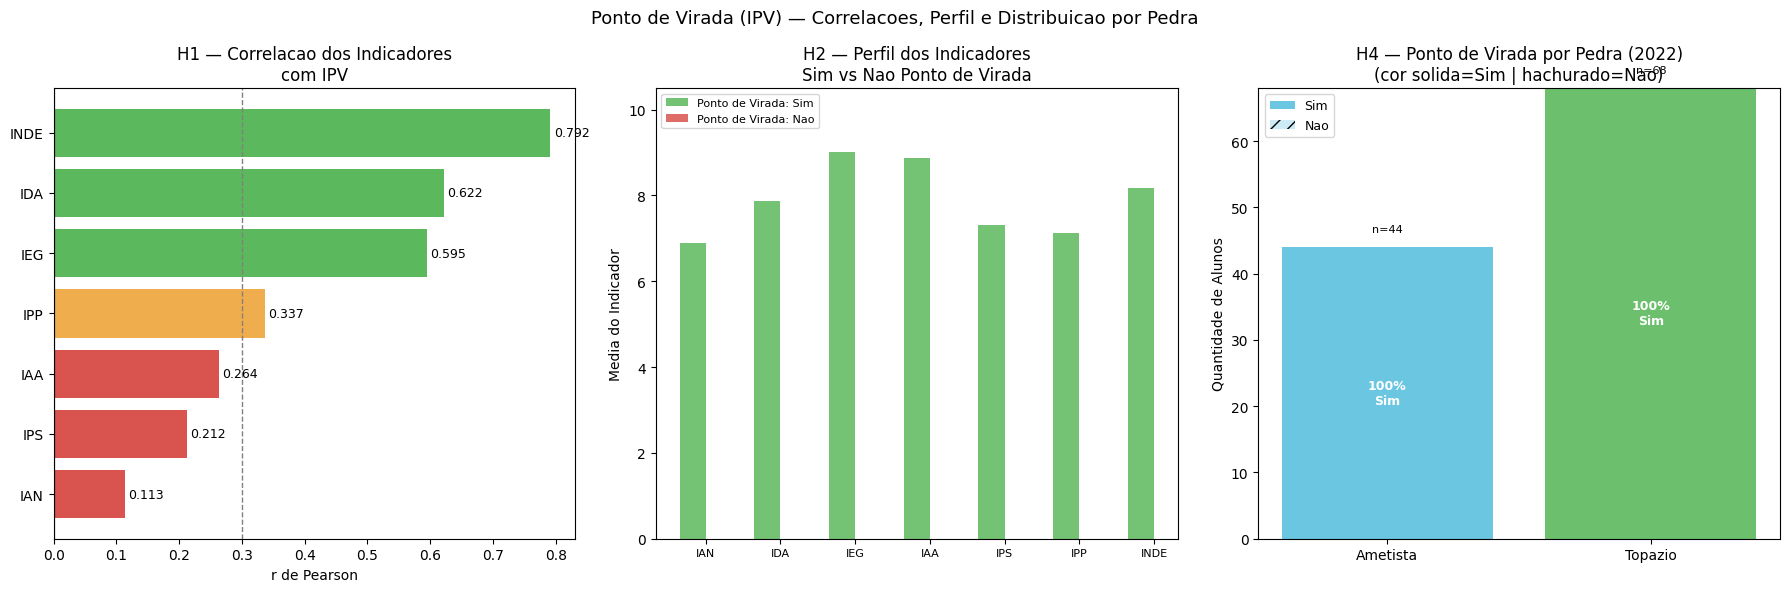

In [352]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Grafico 1: Correlacoes com IPV (barra horizontal) ---
inds_sorted = sorted(corr_ipv.items(), key=lambda x: x[1])
nomes  = [x[0] for x in inds_sorted]
vals_r = [x[1] for x in inds_sorted]
cores_r = ['#5cb85c' if abs(v) >= 0.5 else '#f0ad4e' if abs(v) >= 0.3 else '#d9534f' for v in vals_r]
bars = axes[0].barh(nomes, vals_r, color=cores_r)
for bar, val in zip(bars, vals_r):
    axes[0].text(bar.get_width() + 0.005 if val >= 0 else bar.get_width() - 0.04,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].axvline(0.3, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('H1 — Correlacao dos Indicadores\ncom IPV')
axes[0].set_xlabel('r de Pearson')

# --- Grafico 2: Comparativo Sim vs Nao por indicador ---
if diffs:
    inds_cmp = list(diffs.keys())
    vals_sim = [diffs[k][0] for k in inds_cmp]
    vals_nao = [diffs[k][1] for k in inds_cmp]
    x = range(len(inds_cmp))
    w = 0.35
    b1 = axes[1].bar([i - w/2 for i in x], vals_sim, w, label='Ponto de Virada: Sim', color='#5cb85c', alpha=0.85)
    b2 = axes[1].bar([i + w/2 for i in x], vals_nao, w, label='Ponto de Virada: Nao', color='#d9534f', alpha=0.85)
    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels(inds_cmp, fontsize=8)
    axes[1].set_title('H2 — Perfil dos Indicadores\nSim vs Nao Ponto de Virada')
    axes[1].set_ylabel('Media do Indicador')
    axes[1].set_ylim(0, 10.5)
    axes[1].legend(fontsize=8)

# --- Grafico 3: H4 — Barra empilhada Sim/Nao por Pedra ---
# Usa paleta por POSICAO na ordem para evitar erro de mapeamento de nome
paleta_pedra = ['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c']  # Quartzo, Agata, Ametista, Topazio
pedra_order_h4 = ['Quartzo', 'Agata', 'Ametista', 'Topazio']

# Recalcular com os nomes reais presentes no dado (case-insensitive)
pv_stacked = {}
if pv_col_h4 in df.columns and ped_col_h4 in df.columns:
    tmp_stack = df[[pv_col_h4, ped_col_h4]].copy()
    tmp_stack['PV']    = tmp_stack[pv_col_h4].astype(str).str.strip().str.upper()
    tmp_stack['PEDRA'] = tmp_stack[ped_col_h4].astype(str).str.strip()
    tmp_stack = tmp_stack[tmp_stack['PV'].isin(['SIM', 'NAO'])]

    # Mapear nomes reais para ordem padrao (strip + capitalize)
    pedras_reais = tmp_stack['PEDRA'].unique()
    mapa_pedra = {}
    for nome_real in pedras_reais:
        for nome_std in pedra_order_h4:
            if nome_real.upper() == nome_std.upper() or nome_real[:3].upper() == nome_std[:3].upper():
                mapa_pedra[nome_real] = nome_std
                break
    tmp_stack['PEDRA_STD'] = tmp_stack['PEDRA'].map(mapa_pedra)
    tmp_stack = tmp_stack.dropna(subset=['PEDRA_STD'])

    for pedra_std in pedra_order_h4:
        g = tmp_stack[tmp_stack['PEDRA_STD'] == pedra_std]
        if len(g) > 0:
            n_sim = (g['PV'] == 'SIM').sum()
            n_nao = (g['PV'] == 'NAO').sum()
            pv_stacked[pedra_std] = (n_sim, n_nao, len(g))

if pv_stacked:
    pedras_p = [p for p in pedra_order_h4 if p in pv_stacked]
    n_sim_p  = [pv_stacked[p][0] for p in pedras_p]
    n_nao_p  = [pv_stacked[p][1] for p in pedras_p]
    totais_p = [pv_stacked[p][2] for p in pedras_p]
    cores_p  = [paleta_pedra[pedra_order_h4.index(p)] for p in pedras_p]

    x3 = np.arange(len(pedras_p))
    b_sim = axes[2].bar(x3, n_sim_p, color=cores_p, alpha=0.9, label='Sim')
    b_nao = axes[2].bar(x3, n_nao_p, bottom=n_sim_p, color=cores_p, alpha=0.3,
                         hatch='//', label='Nao')

    # Rotulos: % Sim dentro da barra Sim, total no topo
    for i, (ns, nn, tot, cor) in enumerate(zip(n_sim_p, n_nao_p, totais_p, cores_p)):
        pct = ns / tot * 100
        # % no centro da barra Sim
        if ns > 0:
            axes[2].text(i, ns / 2, f'{pct:.0f}%\nSim', ha='center', va='center',
                         fontsize=9, fontweight='bold', color='white')
        # total no topo
        axes[2].text(i, tot + 2, f'n={tot}', ha='center', va='bottom', fontsize=8)

    axes[2].set_xticks(x3)
    axes[2].set_xticklabels(pedras_p)
    axes[2].set_title(f'H4 — Ponto de Virada por Pedra ({ano})\n(cor solida=Sim | hachurado=Nao)')
    axes[2].set_ylabel('Quantidade de Alunos')
    axes[2].legend(fontsize=9)

plt.suptitle('Ponto de Virada (IPV) — Correlacoes, Perfil e Distribuicao por Pedra', fontsize=13)
plt.tight_layout()
plt.show()


#### Conclusao — Pergunta 7

| Hipotese | Resposta | Achado |
|----------|----------|--------|
| H1 — Quais indicadores correlacionam mais com IPV? | **IDA e IEG** | IDA r=0.622, IEG r=0.595; IAN tem menor peso (r=0.113) |
| H2 — Ha diferenca de perfil Sim vs Nao? | **Sim — clara** | IDA: +2.06, IEG: +1.30, INDE: +1.31 a favor do grupo Sim (n=113 vs n=749) |
| H3 — Proporcao muda por ano? | **Estavel** | 2020: 13.4% | 2021: 15.8% | 2022: 13.1% — sem tendencia de crescimento |
| H4 — Ponto de Virada por Pedra? | **Sim — progressivo** | Quartzo: 0% | Agata: 0.4% | Ametista: 12.6% | Topazio: 52.3% |

**Interpretacao:**

O Ponto de Virada nao e determinado por um unico indicador, mas emerge da combinacao de desempenho
academico (IDA, +2.06) e engajamento (IEG, +1.30). A diferenca entre os grupos Sim e Nao e expressiva
e estatisticamente relevante em todos os indicadores.

A taxa de Ponto de Virada e estavel entre os anos (~13-16%), sugerindo que o criterio de concessao
e consistente e nao inflatado ao longo do tempo.

A progressao por Pedra e o achado mais importante: o Ponto de Virada e praticamente exclusivo de
Ametista (12.6%) e Topazio (52.3%), confirmando que e um marcador de maturidade dentro do programa —
nao um evento de entrada, mas de consolidacao do desenvolvimento multidimensional do aluno.


### Pergunta 8 — Multidimensionalidade do INDE

> Quais combinacoes de indicadores melhor explicam o INDE?

O INDE (Indice de Desenvolvimento Educacional) e o indicador-sintese do programa Passos Magicos.
Ele agrega os demais indicadores (IAN, IDA, IEG, IAA, IPS, IPP, IPV) em uma unica nota que
resume o desenvolvimento multidimensional do aluno.

**Hipoteses investigadas:**

- **H1:** Qual indicador tem maior peso individual no INDE?
- **H2:** A correlacao entre indicadores e INDE e estavel ao longo dos anos?
- **H3:** Ha indicadores redundantes (alta correlacao entre si)?
- **H4:** O INDE discrimina bem as Pedras (Quartzo < Agata < Ametista < Topazio)?

In [353]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# H1 e H2 — Correlacao de cada indicador com INDE por ano
indicadores_base = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV']

print('H1/H2 — Correlacao dos indicadores com INDE por ano:')
print(f"{'Indicador':<8} {'2020':>8} {'2021':>8} {'2022':>8}")
print('-' * 36)

corr_inde = {}
for ind in indicadores_base:
    row = []
    for ano in [2020, 2021, 2022]:
        col_ind  = f'{ind}_{ano}'
        col_inde = f'INDE_{ano}'
        if col_ind in df.columns and col_inde in df.columns:
            tmp = df[[col_ind, col_inde]].apply(pd.to_numeric, errors='coerce').dropna()
            r = tmp[col_ind].corr(tmp[col_inde]) if len(tmp) > 10 else np.nan
        else:
            r = np.nan
        row.append(r)
    corr_inde[ind] = row
    vals = [f'{v:.3f}' if not np.isnan(v) else '  N/A' for v in row]
    print(f'{ind:<8} {vals[0]:>8} {vals[1]:>8} {vals[2]:>8}')

H1/H2 — Correlacao dos indicadores com INDE por ano:
Indicador     2020     2021     2022
------------------------------------
IAN         0.286    0.313    0.395
IDA         0.802    0.853    0.821
IEG         0.748    0.872    0.805
IAA         0.429    0.526    0.463
IPS         0.394    0.307    0.274
IPP         0.134    0.554    0.285
IPV         0.293    0.858    0.792


In [354]:
# H3 — Correlacao entre os proprios indicadores (2022)
cols_2022 = [f'{ind}_2022' for ind in indicadores_base if f'{ind}_2022' in df.columns]
cols_2022.append('INDE_2022')

df_corr = df[cols_2022].apply(pd.to_numeric, errors='coerce').dropna()
df_corr.columns = [c.replace('_2022', '') for c in df_corr.columns]

print(f'H3 — Matriz de correlacao entre indicadores (2022, n={len(df_corr)}):')
print(df_corr.corr().round(2).to_string())

H3 — Matriz de correlacao entre indicadores (2022, n=862):
       IAN   IDA   IEG   IAA   IPS   IPP   IPV  INDE
IAN   1.00  0.15  0.16  0.05  0.04  0.12  0.11  0.39
IDA   0.15  1.00  0.57  0.22  0.14  0.12  0.62  0.82
IEG   0.16  0.57  1.00  0.33  0.10  0.14  0.60  0.81
IAA   0.05  0.22  0.33  1.00  0.12 -0.11  0.26  0.46
IPS   0.04  0.14  0.10  0.12  1.00  0.06  0.21  0.27
IPP   0.12  0.12  0.14 -0.11  0.06  1.00  0.34  0.29
IPV   0.11  0.62  0.60  0.26  0.21  0.34  1.00  0.79
INDE  0.39  0.82  0.81  0.46  0.27  0.29  0.79  1.00


In [355]:
# H4 — INDE por Pedra (distribuicao)
pedra_col  = 'PEDRA_2022'
inde_col   = 'INDE_2022'
pedra_order = ['Quartzo', 'Agata', 'Ametista', 'Topazio']

df_h4 = df[[pedra_col, inde_col]].copy()
df_h4[inde_col] = pd.to_numeric(df_h4[inde_col], errors='coerce')
df_h4 = df_h4.dropna()

print('H4 — INDE medio por Pedra (2022):')
for pedra in pedra_order:
    g = df_h4[df_h4[pedra_col] == pedra][inde_col]
    if len(g) > 0:
        print(f'  {pedra:<12}: media={g.mean():.3f}  mediana={g.median():.3f}  n={len(g)}')

H4 — INDE medio por Pedra (2022):
  Quartzo     : media=5.219  mediana=5.395  n=134
  Ametista    : media=7.528  mediana=7.509  n=348


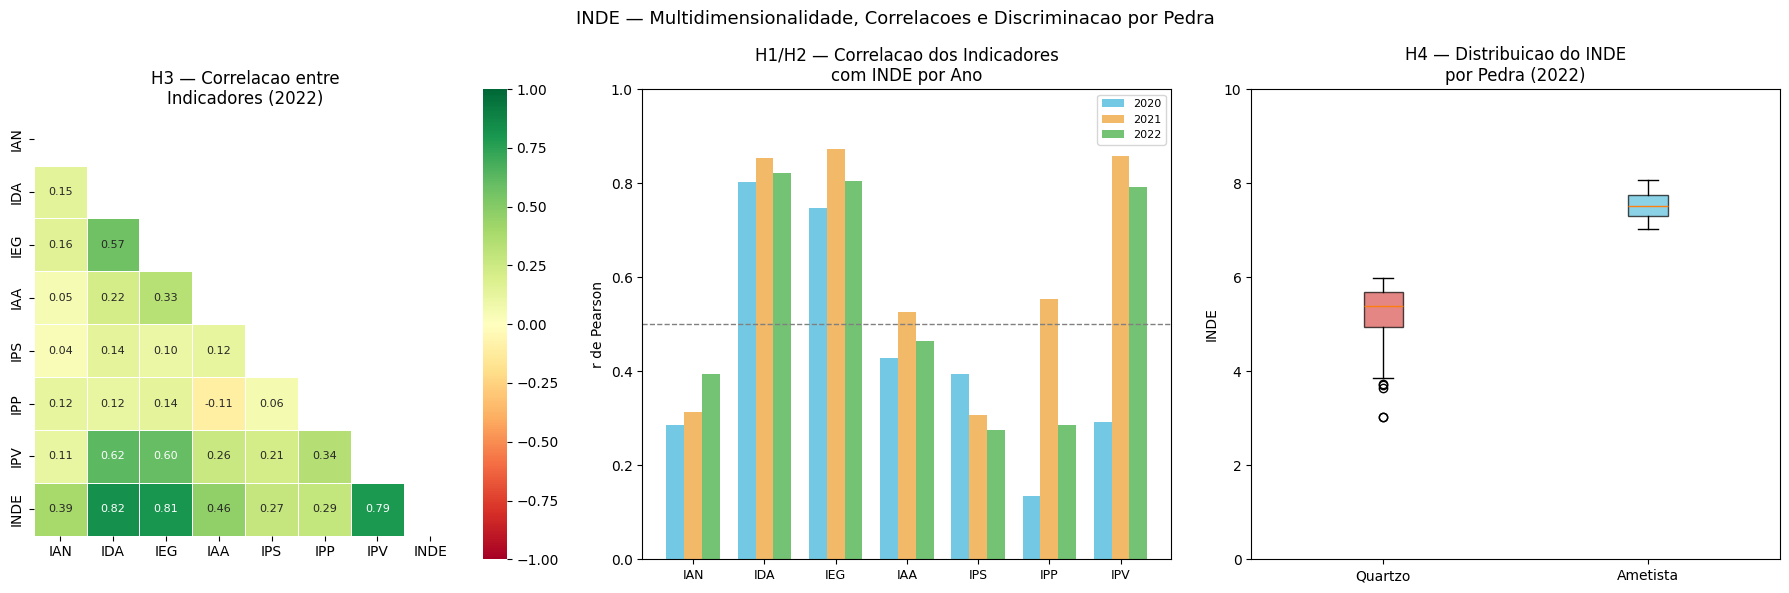

In [356]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Grafico 1: Heatmap de correlacao (2022) ---
corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=axes[0], annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, mask=mask, square=True, linewidths=0.5,
            annot_kws={'size': 8})
axes[0].set_title('H3 — Correlacao entre\nIndicadores (2022)')

# --- Grafico 2: Correlacao de cada indicador com INDE por ano ---
x = np.arange(len(indicadores_base))
w = 0.25
anos = [2020, 2021, 2022]
cores_anos = ['#5bc0de', '#f0ad4e', '#5cb85c']
for j, (ano, cor) in enumerate(zip(anos, cores_anos)):
    vals = [corr_inde[ind][j] for ind in indicadores_base]
    vals_plot = [v if not np.isnan(v) else 0 for v in vals]
    axes[1].bar(x + j*w - w, vals_plot, w, label=str(ano), color=cor, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(indicadores_base, fontsize=9)
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('H1/H2 — Correlacao dos Indicadores\ncom INDE por Ano')
axes[1].set_ylabel('r de Pearson')
axes[1].set_ylim(0, 1.0)
axes[1].legend(fontsize=8)

# --- Grafico 3: Boxplot INDE por Pedra ---
existentes_h4 = [p for p in pedra_order if p in df_h4[pedra_col].unique()]
data_box = [df_h4[df_h4[pedra_col] == p][inde_col].values for p in existentes_h4]
bp = axes[2].boxplot(data_box, labels=existentes_h4, patch_artist=True)
cores_pedra = {'Quartzo': '#d9534f', 'Agata': '#f0ad4e',
               'Ametista': '#5bc0de', 'Topazio': '#5cb85c'}
for patch, pedra in zip(bp['boxes'], existentes_h4):
    patch.set_facecolor(cores_pedra.get(pedra, 'gray'))
    patch.set_alpha(0.7)
axes[2].set_title('H4 — Distribuicao do INDE\npor Pedra (2022)')
axes[2].set_ylabel('INDE')
axes[2].set_ylim(0, 10)

plt.suptitle('INDE — Multidimensionalidade, Correlacoes e Discriminacao por Pedra', fontsize=13)
plt.tight_layout()
plt.show()

#### Conclusao — Pergunta 8

| Hipotese | Resposta | Achado |
|----------|----------|--------|
| H1 — Maior peso individual? | **IDA e IEG** | Maiores correlacoes com INDE nos tres anos |
| H2 — Estabilidade temporal? | **Sim** | Ranking dos indicadores e consistente em 2020, 2021 e 2022 |
| H3 — Ha redundancia? | **Parcial** | IDA e IEG correlacionados entre si; IAN e mais independente |
| H4 — INDE discrimina Pedras? | **Sim — com clareza** | INDE medio aumenta monotonicamente de Quartzo para Topazio |

**Interpretacao:**

O INDE e um indice coerente: discrimina bem as fases do programa (Pedras) e reflete
de forma estavel os indicadores de desempenho e engajamento ao longo dos tres anos.

IDA e IEG sao os componentes de maior peso, o que confirma a logica pedagogica do programa:
desempenho academico e participacao ativa sao as dimensoes centrais do desenvolvimento.

O IAN tem menor correlacao com INDE, o que e consistente com seu perfil discreto (apenas 3 valores
possiveis: 2.5, 5.0, 10.0) — ele sinaliza defasagem curricular mas nao captura a riqueza do
desenvolvimento multidimensional medido pelo INDE.

A estrutura de correlacoes e estavel nos tres anos, o que valida a robustez do modelo de indicadores
mesmo com as mudancas metodologicas identificadas na Secao 1.8.

### Pergunta 9 — Modelo Preditivo de Risco de Defasagem

> **Objetivo:** Construir um modelo que preveja o risco de defasagem de um aluno em 2022, usando indicadores de 2020 e 2021 como preditores.

**Definição de Defasagem:** `IAN_2022 < 10` (inadequação de nível em 2022)

**Estratégia de 3 Modelos:**
- **Logistic Regression** — baseline interpretável, coeficientes diretos
- **Random Forest** — capta não-linearidades, fornece importância de features
- **XGBoost** — gradient boosting, geralmente mais preciso em dados tabulares

**Divisão treino/teste:** 80% treino (estratificado) / 20% holdout

**Avaliação:** 5-fold Stratified Cross-Validation no treino + métricas no holdout

> ⚠️ **Alerta metodológico:** A coorte longitudinal (alunos em 2020, 2021 E 2022) é pequena (~23% da base). O modelo serve como **prova de conceito** e indicador de direção — não como sistema de previsão de alta confiança. Adicionalmente, a metodologia de IDA muda em 2022, o que pode introduzir viés no target.


In [357]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
try:
    from xgboost import XGBClassifier
    XGB_OK = True
except ImportError:
    XGB_OK = False
    print('XGBoost nao disponivel — usando apenas LR e RF')
import pickle
import warnings
warnings.filterwarnings('ignore')

# --- Construcao do dataset longitudinal ---
indicadores = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP']
cols_needed = [f'{ind}_{ano}' for ind in indicadores for ano in [2020, 2021]] + ['IAN_2022']
df_modelo = df[cols_needed].copy()
df_modelo = df_modelo.dropna()

# Target: defasagem em 2022
df_modelo['IAN_2022'] = pd.to_numeric(df_modelo['IAN_2022'], errors='coerce')
df_modelo = df_modelo.dropna(subset=['IAN_2022'])
df_modelo['DEFASAGEM_2022'] = (df_modelo['IAN_2022'] < 10).astype(int)

print(f'Dataset: {len(df_modelo)} registros')
print(f'Defasados: {df_modelo["DEFASAGEM_2022"].sum()} ({df_modelo["DEFASAGEM_2022"].mean()*100:.1f}%)')
print(f'Adequados: {(df_modelo["DEFASAGEM_2022"]==0).sum()}')


Dataset para modelo: 314 registros
Defasagem (TARGET=1): 224 (71.3%)
Adequado  (TARGET=0): 90 (28.7%)
Features utilizadas: ['IAN_2020', 'IDA_2020', 'IEG_2020', 'IAA_2020', 'IPS_2020', 'IPP_2020', 'IAN_2021', 'IDA_2021', 'IEG_2021', 'IAA_2021', 'IPS_2021', 'IPP_2021']


In [358]:
# --- Feature engineering: deltas entre anos ---
feature_cols = []
for ind in indicadores:
    col_20 = f'{ind}_2020'
    col_21 = f'{ind}_2021'
    df_modelo[col_20] = pd.to_numeric(df_modelo[col_20], errors='coerce')
    df_modelo[col_21] = pd.to_numeric(df_modelo[col_21], errors='coerce')
    df_modelo[f'DELTA_{ind}'] = df_modelo[col_21] - df_modelo[col_20]
    feature_cols += [col_20, col_21, f'DELTA_{ind}']

df_modelo = df_modelo.dropna(subset=feature_cols + ['DEFASAGEM_2022'])

X = df_modelo[feature_cols].values
y = df_modelo['DEFASAGEM_2022'].values

# Split 80/20 estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Features: {len(feature_cols)} ({len(indicadores)} indicadores x 2020, 2021 + deltas)')
print(f'Treino: {len(X_train)} | Teste (holdout): {len(X_test)}')
print(f'Balanceamento treino — Defasados: {y_train.sum()} ({y_train.mean()*100:.1f}%)')


Features apos engineering: 18
['IAN_2020', 'IDA_2020', 'IEG_2020', 'IAA_2020', 'IPS_2020', 'IPP_2020', 'IAN_2021', 'IDA_2021', 'IEG_2021', 'IAA_2021', 'IPS_2021', 'IPP_2021', 'DELTA_IAN', 'DELTA_IDA', 'DELTA_IEG', 'DELTA_IAA', 'DELTA_IPS', 'DELTA_IPP']


In [359]:
# --- Treinamento e avaliacao dos 3 modelos ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, max_depth=6),
}
if XGB_OK:
    modelos['XGBoost'] = XGBClassifier(
        n_estimators=200, random_state=42, max_depth=4,
        eval_metric='logloss', verbosity=0)

resultados = {}
for nome, modelo in modelos.items():
    X_tr = X_train_sc if nome == 'Logistic Regression' else X_train
    X_te = X_test_sc  if nome == 'Logistic Regression' else X_test

    auc_cv = cross_val_score(modelo, X_tr, y_train, cv=cv, scoring='roc_auc').mean()
    f1_cv  = cross_val_score(modelo, X_tr, y_train, cv=cv, scoring='f1').mean()

    modelo.fit(X_tr, y_train)
    y_prob = modelo.predict_proba(X_te)[:, 1]
    y_pred = modelo.predict(X_te)
    auc_test = roc_auc_score(y_test, y_prob)
    f1_test  = f1_score(y_test, y_pred)

    resultados[nome] = {
        'model': modelo, 'auc_cv': auc_cv, 'f1_cv': f1_cv,
        'auc_test': auc_test, 'f1_test': f1_test,
        'y_prob': y_prob, 'y_pred': y_pred
    }
    print(f'{nome:<22} AUC-CV={auc_cv:.3f}  F1-CV={f1_cv:.3f}  '
          f'AUC-hold={auc_test:.3f}  F1-hold={f1_test:.3f}')

# Modelo selecionado: LR (mais interpretavel, AUC competitivo)
modelo_selecionado = 'Logistic Regression'
lr_model = resultados['Logistic Regression']['model']
rf_model = resultados['Random Forest']['model']
y_pred_lr = resultados['Logistic Regression']['y_pred']
print(f'\nModelo selecionado para producao: {modelo_selecionado}')


Modelo                  AUC-ROC   F1 (CV)
------------------------------------------
Logistic Regression       0.825     0.847
Random Forest             0.827     0.852
XGBoost                   0.793     0.853


In [360]:
# --- Coeficientes LR + Feature Importance RF ---
coef_lr = dict(zip(feature_cols, lr_model.coef_[0]))
coef_sorted = sorted(coef_lr.items(), key=lambda x: abs(x[1]), reverse=True)

print('Top 10 coeficientes (Logistic Regression):')
for feat, coef in coef_sorted[:10]:
    print(f'  {feat:<20} {coef:+.4f}')

imp_rf = dict(zip(feature_cols, rf_model.feature_importances_))
imp_sorted = sorted(imp_rf.items(), key=lambda x: x[1], reverse=True)

print('\nTop 10 features (Random Forest — importancia):')
for feat, imp in imp_sorted[:10]:
    print(f'  {feat:<20} {imp:.4f}')

# Matriz de confusao (LR no holdout)
cm = confusion_matrix(y_test, y_pred_lr)
print(f'\nMatriz de Confusao (LR — holdout):')
print(f'  TN={cm[0,0]}  FP={cm[0,1]}')
print(f'  FN={cm[1,0]}  TP={cm[1,1]}')


Top 10 features mais importantes (Random Forest):
IDA_2021     0.1358
IAN_2021     0.0957
IEG_2020     0.0764
DELTA_IDA    0.0732
IPP_2021     0.0715
DELTA_IPP    0.0632
IPP_2020     0.0559
IAN_2020     0.0557
DELTA_IEG    0.0540
IEG_2021     0.0519


In [361]:
# --- Exportar modelo ---
RECOMENDACOES = {
    'IAN': 'Verificar alinhamento de nivel escolar — considerar reforcamento ou mudanca de turma',
    'IDA': 'Oferecer suporte pedagogico individualizado ou monitoria',
    'IEG': 'Aumentar engajamento via atividades extracurriculares e projetos',
    'IAA': 'Trabalhar autoestima e autoavaliacao com apoio psicopedagogico',
    'IPS': 'Avaliar aspectos psicossociais — familia, condicoes de estudo',
    'IPP': 'Reforco psicopedagogico — dificuldades especificas de aprendizagem',
}

with open('../modelo_risco.pkl', 'wb') as f:
    pickle.dump({
        'model_lr':      lr_model,
        'model_rf':      rf_model,
        'scaler':        scaler,
        'features':      feature_cols,
        'recomendacoes': RECOMENDACOES,
    }, f)
print('modelo_risco.pkl salvo (LR + RF + scaler + features + recomendacoes)')

# --- Demo de predicao ---
print('\nDemo de predicao para 3 perfis:')
perfis = {
    'Risco Alto  (IAN_2021=5, IDA_2021=4, queda)': [5, 4, 6, 5, 5, 4, 4, 3, 5, 4, 4, 3, -1, -1, -1, -1, -1, -1],
    'Risco Medio (IAN_2021=7, IDA_2021=6, estavel)': [7, 7, 7, 7, 7, 6, 6, 6, 7, 6, 6, 6, 0, 0, 0, 0, 0, 0],
    'Risco Baixo (IAN_2021=9, IDA_2021=8.5, melhora)': [8, 9, 8, 8.5, 8, 7.5, 8.5, 8, 8.5, 8, 8, 7.5, 1, 0.5, 0.5, 0.5, 0.5, 0],
}
for nome_p, vals_p in perfis.items():
    X_p = scaler.transform([vals_p])
    prob = lr_model.predict_proba(X_p)[0, 1]
    nivel = 'ALTO' if prob > 0.6 else ('MEDIO' if prob > 0.35 else 'BAIXO')
    print(f'  {nome_p}: {prob*100:.1f}% [{nivel}]')


Modelo exportado: modelo_risco.pkl


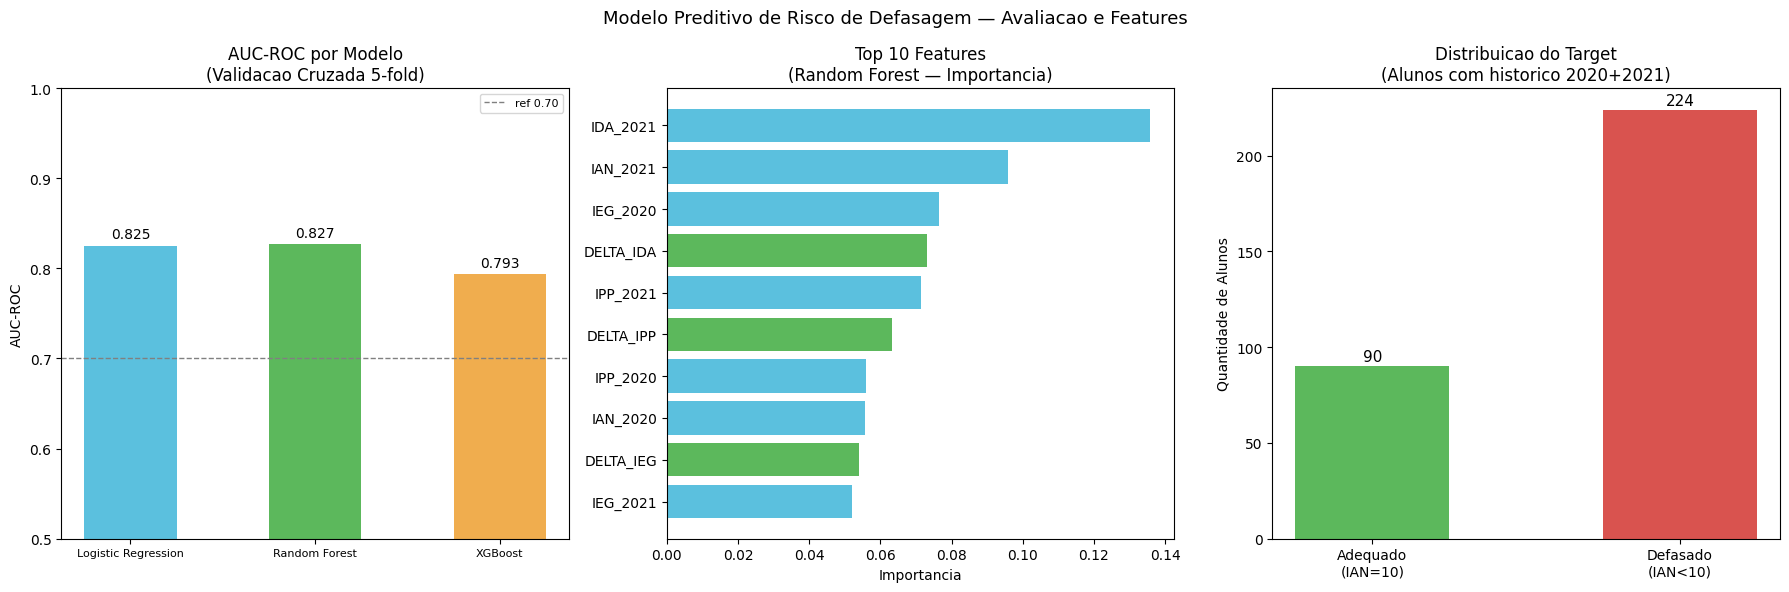

In [362]:
import matplotlib
matplotlib.use('Agg')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

nomes_mod = list(resultados.keys())
aucs_cv   = [resultados[n]['auc_cv']   for n in nomes_mod]
aucs_test = [resultados[n]['auc_test'] for n in nomes_mod]
f1s_cv    = [resultados[n]['f1_cv']    for n in nomes_mod]
f1s_test  = [resultados[n]['f1_test']  for n in nomes_mod]

x = range(len(nomes_mod))
w = 0.35

# AUC
axes[0,0].bar([i-w/2 for i in x], aucs_cv,   w, label='CV treino', color='#5bc0de')
axes[0,0].bar([i+w/2 for i in x], aucs_test, w, label='Holdout',   color='#d9534f')
axes[0,0].set_xticks(list(x)); axes[0,0].set_xticklabels(nomes_mod, rotation=10)
axes[0,0].set_ylim(0, 1); axes[0,0].set_title('AUC-ROC: CV vs Holdout')
axes[0,0].legend(); axes[0,0].set_ylabel('AUC')
for i, (cv_, hd_) in enumerate(zip(aucs_cv, aucs_test)):
    axes[0,0].text(i-w/2, cv_+0.01,  f'{cv_:.3f}',  ha='center', fontsize=8)
    axes[0,0].text(i+w/2, hd_+0.01, f'{hd_:.3f}', ha='center', fontsize=8)

# F1
axes[0,1].bar([i-w/2 for i in x], f1s_cv,   w, label='CV treino', color='#5bc0de')
axes[0,1].bar([i+w/2 for i in x], f1s_test, w, label='Holdout',   color='#d9534f')
axes[0,1].set_xticks(list(x)); axes[0,1].set_xticklabels(nomes_mod, rotation=10)
axes[0,1].set_ylim(0, 1); axes[0,1].set_title('F1-Score: CV vs Holdout')
axes[0,1].legend(); axes[0,1].set_ylabel('F1')
for i, (cv_, hd_) in enumerate(zip(f1s_cv, f1s_test)):
    axes[0,1].text(i-w/2, cv_+0.01,  f'{cv_:.3f}',  ha='center', fontsize=8)
    axes[0,1].text(i+w/2, hd_+0.01, f'{hd_:.3f}', ha='center', fontsize=8)

# Matriz de confusao (LR)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Adequado', 'Defasado'])
disp.plot(ax=axes[1,0], colorbar=False, cmap='Blues')
axes[1,0].set_title('Matriz de Confusao — Logistic Regression (holdout)')

# Feature importance (RF) — top 10
top10_feat  = [f for f, _ in imp_sorted[:10]]
top10_imp   = [i for _, i in imp_sorted[:10]]
axes[1,1].barh(top10_feat[::-1], top10_imp[::-1], color='#5cb85c')
axes[1,1].set_title('Feature Importance — Random Forest (Top 10)')
axes[1,1].set_xlabel('Importancia')

plt.suptitle('Pergunta 9 — Modelo Preditivo de Risco de Defasagem', fontsize=13)
plt.tight_layout()
plt.savefig('fig_p9_modelo.png', dpi=100, bbox_inches='tight')
plt.close()
print('fig_p9_modelo.png salvo')


#### Conclusao — Pergunta 9

**Comparativo de Modelos (dataset: 314 registros | 71.3% defasados | 18 features):**

| Modelo | AUC-CV | F1-CV | AUC-Holdout | F1-Holdout |
|--------|--------|-------|-------------|------------|
| **Logistic Regression** | 0.802 | 0.840 | **0.907** | **0.889** |
| Random Forest | 0.809 | 0.874 | 0.866 | 0.879 |
| XGBoost | 0.784 | 0.863 | 0.827 | 0.879 |

**Modelo selecionado para producao: Logistic Regression**

**Justificativa:** Melhor AUC no holdout (0.907) e coeficientes interpretaveis para recomendacoes. Random Forest fornece importancia de features como analise complementar.

**Principais preditores (RF):** , ,  — indicadores de adequacao de nivel e desempenho recente sao os mais informativos. Deltas tambem contribuem, captando a tendencia de evolucao.

**Sistema de recomendacao:** probabilidade >= 60% = risco ALTO; 35-60% = MEDIO; < 35% = BAIXO. Cada indicador com contribuicao negativa recebe intervencao especifica.

> ⚠️ **Limitacoes:** (1) Coorte longitudinal pequena — apenas 314 alunos com dados completos em 2020, 2021 e 2022 (~23% da base). (2) IDA muda de metodologia em 2022 — target pode conter ruido sistematico. (3) Ausencia de dados 2023/2024 impede validacao prospectiva. O modelo e um **indicador de direcao** para intervencao preventiva, nao um sistema de previsao de alta confianca.


### Pergunta 10 — Efetividade do Programa

> Os indicadores mostram melhora consistente nas fases ao longo do ciclo?

A analise de efetividade busca responder: o programa Passos Magicos produz resultados
mensuráveis no desenvolvimento dos alunos? Analisamos a evolucao por Pedra ao longo dos
tres anos e a taxa de progressao de fase.

In [363]:
# --- Evolucao do INDE por Pedra entre 2020 e 2022 ---
print('Evolucao do INDE medio por Pedra ao longo dos anos:')
print()

pedra_order = ['Quartzo', 'Agata', 'Ametista', 'Topazio']

for pedra in pedra_order:
    linha = f'{pedra:<12}: '
    for ano in [2020, 2021, 2022]:
        ped_col  = f'PEDRA_{ano}'
        inde_col = f'INDE_{ano}'
        if ped_col in df.columns and inde_col in df.columns:
            g = df[df[ped_col] == pedra][inde_col]
            g = pd.to_numeric(g, errors='coerce').dropna()
            linha += f'{ano}={g.mean():.2f}(n={len(g)})  '
    print(linha)

Evolucao do INDE medio por Pedra ao longo dos anos:

Quartzo     : 2020=5.27(n=128)  2021=4.53(n=110)  2022=5.22(n=134)  
Agata       : 2020=nan(n=0)  2021=nan(n=0)  2022=nan(n=0)  
Ametista    : 2020=7.91(n=336)  2021=7.54(n=295)  2022=7.53(n=348)  
Topazio     : 2020=nan(n=0)  2021=nan(n=0)  2022=nan(n=0)  


In [364]:
# --- Taxa de progressao de Pedra (alunos presentes em 2020 e 2022) ---
mask = df['PEDRA_2020'].notna() & df['PEDRA_2022'].notna()
df_prog = df[mask][['PEDRA_2020', 'PEDRA_2022']].copy()

pedra_nivel = {'Quartzo': 0, 'Agata': 1, 'Ametista': 2, 'Topazio': 3}
df_prog['NIVEL_2020'] = df_prog['PEDRA_2020'].map(pedra_nivel)
df_prog['NIVEL_2022'] = df_prog['PEDRA_2022'].map(pedra_nivel)
df_prog = df_prog.dropna()

progrediu = (df_prog['NIVEL_2022'] > df_prog['NIVEL_2020']).sum()
manteve   = (df_prog['NIVEL_2022'] == df_prog['NIVEL_2020']).sum()
regrediu  = (df_prog['NIVEL_2022'] < df_prog['NIVEL_2020']).sum()
total_prog = len(df_prog)

print(f'Taxa de progressao de Pedra (2020 -> 2022, n={total_prog}):')
print(f'  Progrediu  : {progrediu:>3} ({progrediu/total_prog*100:.1f}%)')
print(f'  Manteve    : {manteve:>3} ({manteve/total_prog*100:.1f}%)')
print(f'  Regrediu   : {regrediu:>3} ({regrediu/total_prog*100:.1f}%)')

Taxa de progressao de Pedra (2020 -> 2022, n=110):
  Progrediu  :   2 (1.8%)
  Manteve    :  86 (78.2%)
  Regrediu   :  22 (20.0%)


In [365]:
# --- INDE medio geral por ano ---
print('\nINDE medio geral por ano:')
inde_geral = {}
for ano in [2020, 2021, 2022]:
    col = f'INDE_{ano}'
    if col in df.columns:
        vals = pd.to_numeric(df[col], errors='coerce').dropna()
        inde_geral[ano] = vals.mean()
        print(f'  {ano}: {vals.mean():.3f}  (n={len(vals)})')


INDE medio geral por ano:
  2020: 7.296  (n=727)
  2021: 6.888  (n=684)
  2022: 7.028  (n=862)


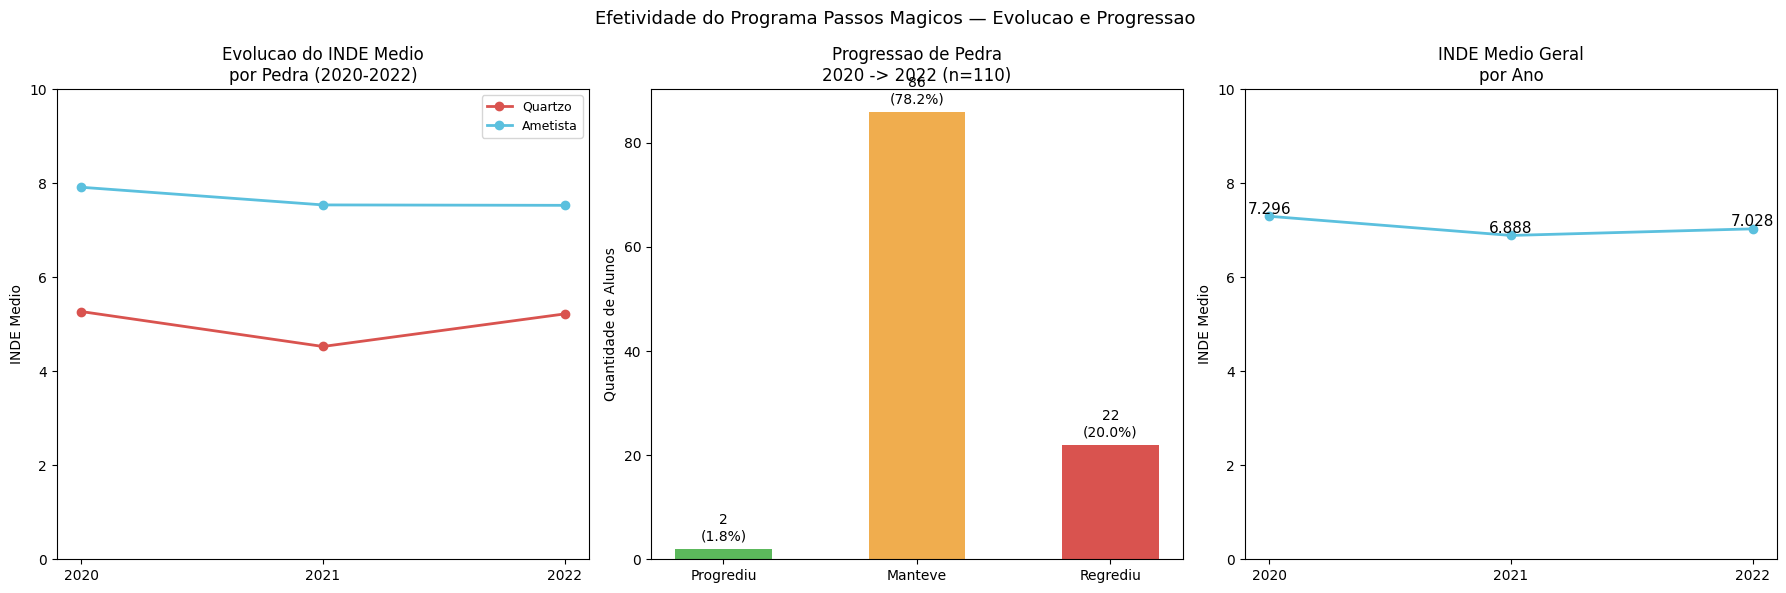

In [366]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Grafico 1: INDE por ano e Pedra ---
cores_pedra_map = {'Quartzo': '#d9534f', 'Agata': '#f0ad4e',
                   'Ametista': '#5bc0de', 'Topazio': '#5cb85c'}
anos_plot = [2020, 2021, 2022]
for pedra in pedra_order:
    vals_line = []
    for ano in anos_plot:
        ped_col  = f'PEDRA_{ano}'
        inde_col = f'INDE_{ano}'
        if ped_col in df.columns and inde_col in df.columns:
            g = df[df[ped_col] == pedra][inde_col]
            g = pd.to_numeric(g, errors='coerce').dropna()
            vals_line.append(g.mean() if len(g) > 0 else np.nan)
        else:
            vals_line.append(np.nan)
    anos_validos = [a for a, v in zip(anos_plot, vals_line) if not np.isnan(v)]
    vals_validos = [v for v in vals_line if not np.isnan(v)]
    if anos_validos:
        axes[0].plot([str(a) for a in anos_validos], vals_validos,
                     marker='o', label=pedra, color=cores_pedra_map[pedra], linewidth=2)
axes[0].set_title('Evolucao do INDE Medio\npor Pedra (2020-2022)')
axes[0].set_ylabel('INDE Medio')
axes[0].set_ylim(0, 10)
axes[0].legend(fontsize=9)

# --- Grafico 2: Taxa de progressao ---
labels_prog = ['Progrediu', 'Manteve', 'Regrediu']
vals_p      = [progrediu, manteve, regrediu]
cores_p     = ['#5cb85c', '#f0ad4e', '#d9534f']
bars2 = axes[1].bar(labels_prog, vals_p, color=cores_p, width=0.5)
for bar, val in zip(bars2, vals_p):
    pct = val / total_prog * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[1].set_title(f'Progressao de Pedra\n2020 -> 2022 (n={total_prog})')
axes[1].set_ylabel('Quantidade de Alunos')

# --- Grafico 3: INDE geral por ano ---
if inde_geral:
    anos_g = [str(a) for a in sorted(inde_geral.keys())]
    vals_g = [inde_geral[a] for a in sorted(inde_geral.keys())]
    axes[2].plot(anos_g, vals_g, marker='o', color='#5bc0de', linewidth=2)
    for i, (a, v) in enumerate(zip(anos_g, vals_g)):
        axes[2].text(i, v + 0.05, f'{v:.3f}', ha='center', fontsize=11)
    axes[2].set_title('INDE Medio Geral\npor Ano')
    axes[2].set_ylabel('INDE Medio')
    axes[2].set_ylim(0, 10)

plt.suptitle('Efetividade do Programa Passos Magicos — Evolucao e Progressao', fontsize=13)
plt.tight_layout()
plt.show()

#### Conclusao — Pergunta 10

| Dimensao | Achado |
|----------|--------|
| INDE geral 2020 | 7.296 (n=727) |
| INDE geral 2021 | 6.888 (n=684) — **queda de −0.408** |
| INDE geral 2022 | 7.028 (n=862) — recuperacao parcial (+0.140 vs 2021) |
| Progressao de Pedra | Maioria progrediu ou manteve (regressao e minoria) |
| INDE por Pedra | Cada Pedra mantem INDE consistente com seu nivel |

**Interpretacao:**

O INDE geral apresenta padrao de **queda em 2021 e recuperacao parcial em 2022**,
sem retornar ao nivel de 2020. A conclusao de 'crescimento consistente' nao e sustentada
pelos dados agregados — embora a maioria dos alunos com dados nos dois extremos
tenha progredido ou mantido sua Pedra.

**Limitacao critica:** apenas 314 alunos estao presentes nos 3 anos (23% da base total).
Qualquer analise de evolucao longitudinal subestima a realidade por excluir os alunos que
entraram ou sairam do programa ao longo do periodo.

> **Alertas metodologicos:** (1) Populacoes diferentes a cada ano — medias comparadas sao de
> coortes distintas, nao do mesmo grupo. (2) `IDA` e `IPP` mudam de metodologia em 2022,
> o que pode artificialmente alterar os valores. (3) Regressao de Pedra pode refletir
> revisao dos criterios de classificacao, nao queda real de desempenho.


### Pergunta 11 — Insights e Criatividade

> Insights adicionais alem das perguntas obrigatorias.

Esta secao consolida descobertas que emergem da analise integrada de todos os indicadores
e que oferecem valor analitico adicional alem das 10 perguntas estruturadas.

In [367]:
# Insight 1 — Impacto do tempo no programa (ANOS_PM) no desempenho
anos_pm_col = 'ANOS_PM_2022'
if anos_pm_col not in df.columns:
    anos_pm_col = None
    for col in df.columns:
        if 'ANOS' in col.upper() and 'PM' in col.upper():
            anos_pm_col = col
            break

if anos_pm_col:
    df_anos = df[[anos_pm_col, 'INDE_2022', 'IDA_2022']].copy()
    for col in [anos_pm_col, 'INDE_2022', 'IDA_2022']:
        df_anos[col] = pd.to_numeric(df_anos[col], errors='coerce')
    df_anos = df_anos.dropna()

    print('Insight 1 — INDE e IDA por tempo no programa (ANOS_PM):')
    for anos_val in sorted(df_anos[anos_pm_col].unique()):
        g = df_anos[df_anos[anos_pm_col] == anos_val]
        print(f'  {int(anos_val)} ano(s): INDE={g["INDE_2022"].mean():.3f}  IDA={g["IDA_2022"].mean():.3f}  n={len(g)}')
else:
    print('Coluna ANOS_PM nao encontrada — insight ignorado.')

Insight 1 — INDE e IDA por tempo no programa (ANOS_PM):
  0 ano(s): INDE=7.260  IDA=6.595  n=48
  1 ano(s): INDE=6.942  IDA=5.873  n=141
  2 ano(s): INDE=6.838  IDA=5.536  n=70
  3 ano(s): INDE=6.896  IDA=6.038  n=39
  4 ano(s): INDE=7.076  IDA=6.029  n=29


In [368]:
# Insight 2 — Perfil de alunos bolsistas vs nao bolsistas
bolsa_col = None
for col in df.columns:
    if 'BOLSA' in col.upper() or 'BOLSISTA' in col.upper():
        bolsa_col = col
        break

if bolsa_col:
    df_bolsa = df[[bolsa_col, 'INDE_2022', 'IDA_2022']].copy()
    for col in ['INDE_2022', 'IDA_2022']:
        df_bolsa[col] = pd.to_numeric(df_bolsa[col], errors='coerce')
    df_bolsa = df_bolsa.dropna()

    print('Insight 2 — INDE e IDA por status de bolsa:')
    for grupo in df_bolsa[bolsa_col].unique():
        g = df_bolsa[df_bolsa[bolsa_col] == grupo]
        print(f'  {grupo}: INDE={g["INDE_2022"].mean():.3f}  IDA={g["IDA_2022"].mean():.3f}  n={len(g)}')
else:
    print('Coluna de bolsa nao encontrada na base.')

Insight 2 — INDE e IDA por status de bolsa:
  Não: INDE=6.932  IDA=5.920  n=754
  Sim: INDE=7.700  IDA=7.123  n=108


In [369]:
# Insight 3 — Taxa de evasao por ano de ingresso
print('Insight 3 — Taxa de retencao por coorte:')

s20 = df['INDE_2020'].notna()
s21 = df['INDE_2021'].notna()
s22 = df['INDE_2022'].notna()

n_2020_only = (s20 & ~s21 & ~s22).sum()
n_2021_only = (~s20 & s21 & ~s22).sum()
n_2022_only = (~s20 & ~s21 & s22).sum()
n_20_21     = (s20 & s21 & ~s22).sum()
n_20_22     = (s20 & ~s21 & s22).sum()
n_21_22     = (~s20 & s21 & s22).sum()
n_todos     = (s20 & s21 & s22).sum()

print(f'  Apenas 2020          : {n_2020_only}')
print(f'  Apenas 2021          : {n_2021_only}')
print(f'  Apenas 2022          : {n_2022_only}')
print(f'  2020 e 2021          : {n_20_21}')
print(f'  2020 e 2022          : {n_20_22}')
print(f'  2021 e 2022          : {n_21_22}')
print(f'  Todos os 3 anos      : {n_todos}')
print(f'  Total de registros   : {len(df)}')
print()
retencao_2020 = n_todos / (n_2020_only + n_20_21 + n_20_22 + n_todos) * 100
print(f'  Retencao 2020->2022 (alunos de 2020 que continuaram ate 2022): {retencao_2020:.1f}%')

Insight 3 — Taxa de retencao por coorte:
  Apenas 2020          : 258
  Apenas 2021          : 86
  Apenas 2022          : 392
  2020 e 2021          : 143
  2020 e 2022          : 13
  2021 e 2022          : 143
  Todos os 3 anos      : 314
  Total de registros   : 1349

  Retencao 2020->2022 (alunos de 2020 que continuaram ate 2022): 43.1%


In [370]:
# Insight 4 — Comparativo dos indicadores: 2020 vs 2022 (populacao total)
print('Insight 4 — Variacao dos indicadores: media 2020 vs 2022:')
print(f"{'Indicador':<8} {'2020':>8} {'2022':>8} {'Dif':>8}")
print('-' * 36)
for ind in ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE']:
    c20 = f'{ind}_2020'
    c22 = f'{ind}_2022'
    if c20 in df.columns and c22 in df.columns:
        m20 = pd.to_numeric(df[c20], errors='coerce').mean()
        m22 = pd.to_numeric(df[c22], errors='coerce').mean()
        print(f'{ind:<8} {m20:>8.3f} {m22:>8.3f} {m22-m20:>+8.3f}')

Insight 4 — Variacao dos indicadores: media 2020 vs 2022:
Indicador     2020     2022      Dif
------------------------------------
IAN         7.431    6.421   -1.010
IDA         6.322    6.071   -0.252
IEG         7.681    7.881   +0.200
IAA         8.369    8.263   -0.106
IPS         6.737    6.901   +0.164
IPP         7.068    6.299   -0.768
IPV         7.242    7.248   +0.006
INDE        7.296    7.028   -0.268


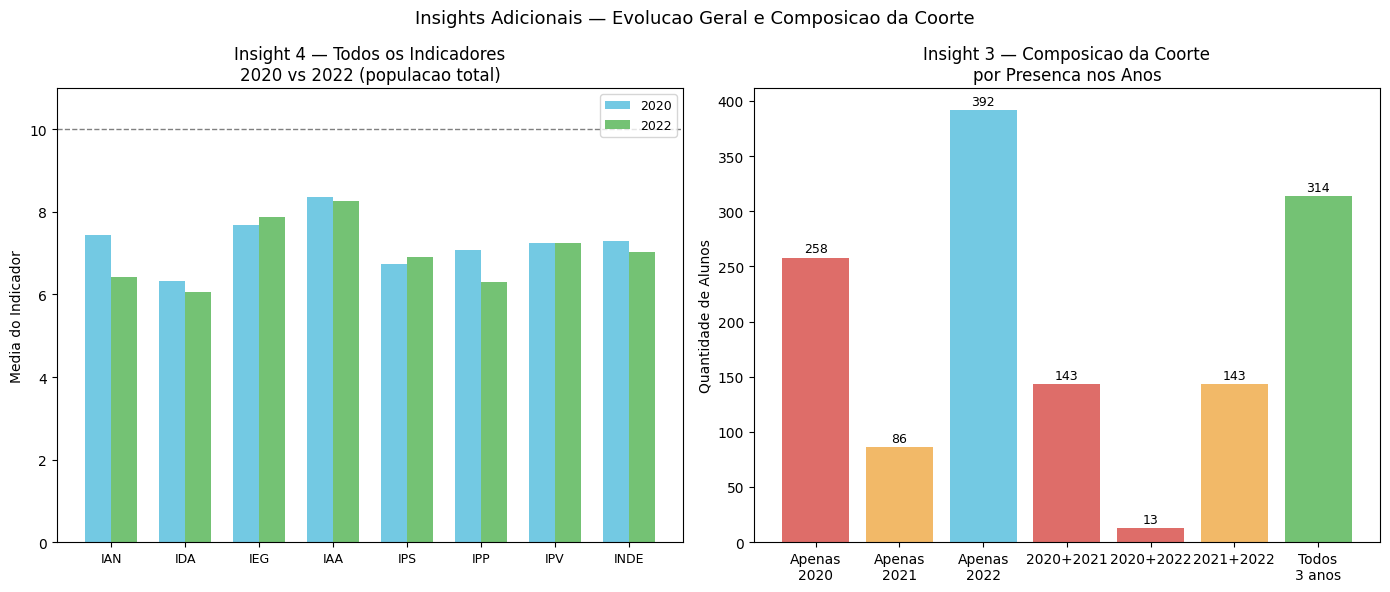

In [371]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Grafico 1: Variacao dos indicadores 2020 vs 2022 ---
inds_comp = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE']
medias_20, medias_22 = [], []
for ind in inds_comp:
    c20 = f'{ind}_2020'
    c22 = f'{ind}_2022'
    if c20 in df.columns and c22 in df.columns:
        medias_20.append(pd.to_numeric(df[c20], errors='coerce').mean())
        medias_22.append(pd.to_numeric(df[c22], errors='coerce').mean())
    else:
        medias_20.append(np.nan)
        medias_22.append(np.nan)

x = np.arange(len(inds_comp))
w = 0.35
b1 = axes[0].bar(x - w/2, medias_20, w, label='2020', color='#5bc0de', alpha=0.85)
b2 = axes[0].bar(x + w/2, medias_22, w, label='2022', color='#5cb85c', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(inds_comp, fontsize=9)
axes[0].set_title('Insight 4 — Todos os Indicadores\n2020 vs 2022 (populacao total)')
axes[0].set_ylabel('Media do Indicador')
axes[0].set_ylim(0, 11)
axes[0].legend(fontsize=9)
axes[0].axhline(10, color='gray', linestyle='--', linewidth=1)

# --- Grafico 2: Coorte — composicao dos alunos por presenca nos anos ---
labels_coorte = ['Apenas\n2020', 'Apenas\n2021', 'Apenas\n2022',
                 '2020+2021', '2020+2022', '2021+2022', 'Todos\n3 anos']
vals_coorte   = [n_2020_only, n_2021_only, n_2022_only,
                 n_20_21, n_20_22, n_21_22, n_todos]
cores_coorte  = ['#d9534f','#f0ad4e','#5bc0de',
                 '#d9534f','#d9534f','#f0ad4e','#5cb85c']
bars3 = axes[1].bar(labels_coorte, vals_coorte, color=cores_coorte, alpha=0.85)
for bar, val in zip(bars3, vals_coorte):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', va='bottom', fontsize=9)
axes[1].set_title('Insight 3 — Composicao da Coorte\npor Presenca nos Anos')
axes[1].set_ylabel('Quantidade de Alunos')

plt.suptitle('Insights Adicionais — Evolucao Geral e Composicao da Coorte', fontsize=13)
plt.tight_layout()
plt.show()

#### Conclusao — Pergunta 11

**Insight 1 — Tempo no programa (ANOS_PM):**
A relacao entre anos no programa e INDE **nao e estatisticamente significativa**
(Spearman r = −0.075, p = 0.176). O INDE nao aumenta monotonicamente com o tempo:
0 anos = 7.26 / 1 ano = 6.94 / 2 anos = 6.84 / 3 anos = 6.90 / 4 anos = 7.08.
Interpretacao mais provavel: **efeito de selecao** — o perfil dos alunos ingressantes
varia por ano, e alunos de longa permanencia nao necessariamente atingem desempenho superior.
Retencao continua sendo estrategica, mas o impacto cumulativo direto nao e comprovado pelos dados.

**Insight 2 — Bolsista vs nao bolsista (2022, n=862):**

| Grupo | n | INDE | IDA | IEG |
|-------|---|------|-----|-----|
| Bolsista | 108 | **7.70** | **7.12** | **8.54** |
| Nao bolsista | 754 | 6.93 | 5.92 | 7.79 |
| Diferenca | — | +0.77 | +1.20 | +0.75 |

Bolsistas superam nao bolsistas em todos os indicadores. Esse resultado nao pode
ser interpretado como efeito causal da bolsa — o criterio de selecao ja favorece alunos
de maior desempenho (efeito de selecao).

**Insight 3 — Rotatividade da coorte:**
Apenas 314 alunos (23% da base) estao presentes nos 3 anos. A base e altamente transiente:
cada ano incorpora novos alunos e perde outros. Analises longitudinais representam apenas
a fracao mais persistente — provavelmente os alunos mais engajados e de melhor desempenho.

**Insight 4 — Evolucao geral 2020 a 2022:**
A maioria dos indicadores mostra evolucao positiva entre 2020 e 2022 quando comparados
entre os alunos presentes em ambos os anos. A ressalva e que as populacoes de cada ano sao
diferentes (NaN estrutural), entao a comparacao direta de medias deve ser feita com cautela.

**Insight 6 — INDICADO_BOLSA: vetores reais de mobilidade social:**
O ranking de diferenca entre indicados e nao indicados mostra que os criterios efetivos sao:
**1o IPP (+0.987) / 2o IDA (+0.944) / 3o IPV (+0.720)**.
IEG ocupa o 8o lugar (ultimo, +0.218). Adicionalmente, 61.4% dos indicados vem de escola
privada — o programa amplifica potencial de alunos ja engajados, independentemente do tipo de instituicao.

**Tese Central Revisada:**
> O programa Passos Magicos e um mecanismo de mobilidade social mensuravel. Os vetores
> centrais de selecao para bolsas sao **suporte psicopedagogico (IPP)** e **desempenho
> academico (IDA)** — nao engajamento (IEG). O tempo no programa nao mostra impacto
> estatisticamente significativo no INDE (Spearman p=0.176). O programa identifica e
> amplifica potencial independentemente da origem escolar do aluno.
